# A2 – Feature Selection & Dimensionality Reduction Methods

This notebook continues from **A1_Leonardo_LS_vf (2).ipynb** and uses the clean A1 output only: `df_train_preprocessed.csv`.

**Reference paper (required):** Zouhri, Idri, and Ratnani (2023), *Evaluating the impact of filter-based feature selection in intrusion detection systems*, International Journal of Information Security. DOI: [10.1007/s10207-023-00767-y](https://doi.org/10.1007/s10207-023-00767-y)

**Task from A1:** binary fraud classification (`isFraud`) on the IEEE-CIS dataset (~3.5% fraud, 540 predictors after preprocessing).

**Anti-leakage workflow:** feature scores on `X_train`; fit on `X_fit`; thresholds on `X_val`; internal `X_test` once in held-out evaluation; **external 80k** evaluated once at the end with frozen thresholds (no re-tuning on external).

**Data split (590,540 rows):** stratified **80k modeling** pool (selection, EDA, train/val/test) + **80k external** holdout (disjoint indices, final evaluation only) + ~430k unused reserve. `RANDOM_STATE = 42` throughout.

| Pool | Use |
|---|---|
| `df_modeling` (80k) | Scores, CFS, merged, fit, val, internal test, EDA plots |
| `df_external` (80k) | Final evaluation only — frozen val thresholds |
| Unused reserve | Documented; not used in this notebook |

### Univariate filters (10 marks) — five methods from the paper

| Method | What it tests | Why univariate |
|---|---|---|
| Pearson \|r\| | Linear association with `isFraud` | One feature vs target |
| ANOVA F | Mean separation fraud vs legitimate | One feature vs target |
| Chi-square | Categorical dependence on `isFraud` | One feature vs target |
| ReliefF-style | Nearest-neighbor class contrast | One feature weight |
| Mutual Information | Non-linear dependence on `isFraud` | One feature vs target |

**Multivariate filters (15 marks):** CFS, CON, DISR — run after univariate ranking.

**Dimensionality reduction (15 marks):** PCA on mixed encoded matrix (Parkinson's-style scree, 2D, component sweep).

**Evaluation:** recall-first policy (`TARGET_RECALL = 0.90`, `MIN_POLICY_ACCURACY = 0.70`), top-k sweep `K_GRID = [10, 20, 30, 50]`.


In [105]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn scipy xgboost


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [106]:
# requirements
import io
import sys
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn

from IPython.display import display, Markdown
from matplotlib import image as mpimg
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from scipy.stats import chi2_contingency
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    mutual_info_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    import missingno as msno
except ImportError:
    msno = None

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

_NB_FIGURE_BANK = []
def _figure_title(fig):
    titles = [ax.get_title() for ax in fig.axes if ax.get_title()]
    if fig._suptitle and fig._suptitle.get_text():
        st = fig._suptitle.get_text().strip()
        return st if not titles else f"{st} - {titles[0]}"
    return titles[0] if titles else f'Plot {len(_NB_FIGURE_BANK) + 1}'


def _register_open_figure(fig=None):
    fig = fig or plt.gcf()
    if not fig.axes:
        return
    n_axes = len(fig.axes)
    title = _figure_title(fig)
    w_in, h_in = fig.get_size_inches()
    # Composite matrices (A1 summary, corr grid, pairplot) get full gallery row
    full_row = (
        n_axes >= 4
        or w_in >= 14
        or any(k in title.lower() for k in ('matrix', 'gallery', 'correlation', 'pairplot', 'membership'))
    )
    dpi = 140 if full_row else 100
    buf = io.BytesIO()
    title = _figure_title(fig)
    skip_keys = (
        'A1 Summary Matrix',
        'Correlation matrices of final selections',
        'Merged pruned - full correlation',
        'Feature membership in final selections',
    )
    if any(k in title for k in skip_keys):
        return
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight', facecolor='white')
    png = buf.getvalue()
    arr = plt.imread(io.BytesIO(png))
    aspect = arr.shape[1] / max(arr.shape[0], 1)
    _NB_FIGURE_BANK.append({
        'title': title,
        'png': png,
        'n_axes': n_axes,
        'aspect': aspect,
        'full_row': full_row,
    })


if not getattr(plt.show, '_nb_capture', False):
    _plt_show_orig = plt.show

    def plt_show_nb_capture(*args, **kwargs):
        _register_open_figure()
        return _plt_show_orig(*args, **kwargs)

    plt_show_nb_capture._nb_capture = True
    plt.show = plt_show_nb_capture


RANDOM_STATE = 42
MODELING_SAMPLE_SIZE = 80_000
EXTERNAL_SAMPLE_SIZE = 80_000
SAMPLE_SIZE = MODELING_SAMPLE_SIZE  # backward-compatible alias
TARGET_RECALL = 0.90
MIN_POLICY_ACCURACY = 0.70
VAL_SIZE = 0.2
TOP_N = 20
UNIVARIATE_RANK_TOP = 100  # full rank table: 5 methods x 100 rows
TOP_MODEL_FEATURES = 10
QUICK_COMPARE_K = 25  # quick comparison (Parkinson-style)
K_GRID = [10, 20, 30, 50]
N_COMPONENTS_GRID = [10, 20, 30, 50]
MERGED_TOP_PER_METHOD = 50
MERGED_MAX_FEATURES = 160
AMT_BAND_COL = 'TransactionAmt_band'
AMT_N_BINS = 4
CORR_PRUNE_THRESHOLD = 0.82
CFS_POOL_SIZE = 80
CFS_MAX_FEATURES = 20
PRIMARY_CLASSIFIER = RandomForestClassifier(
    n_estimators=200,
    max_depth=14,
    min_samples_leaf=30,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

print('Python:', sys.version.split()[0])
print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('matplotlib:', matplotlib.__version__)
print('seaborn:', sns.__version__)
print('scipy:', scipy.__version__)
print('sklearn:', sklearn.__version__)
print('missingno:', msno.__version__ if msno else 'not installed')
try:
    import xgboost as xgb
    xgb_ver = xgb.__version__
except ImportError:
    xgb_ver = 'not installed'
print('xgboost:', xgb_ver)


Python: 3.10.8
pandas: 2.3.0
numpy: 2.2.6
matplotlib: 3.10.3
seaborn: 0.13.2
scipy: 1.14.0
sklearn: 1.4.2
missingno: 0.5.2
xgboost: 3.2.0


## Load A1 Clean Dataset

A2 starts from A1's exported clean/preprocessed dataset. The path check supports both the current folder and a `data/` subfolder.

In [107]:
candidate_paths = [Path('df_train_preprocessed.csv'), Path('data/df_train_preprocessed.csv')]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('df_train_preprocessed.csv was not found in this folder or data/. Run A1 first.')

df = pd.read_csv(DATA_PATH)
print(f'Loaded {DATA_PATH}: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
display(df.head())


Loaded df_train_preprocessed.csv: 590,540 rows x 542 columns


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V37_isna,V44_isna,V43_isna,V42_isna,V41_isna,V40_isna,V39_isna,V45_isna,card3_isna,id_33_class
0,2987000,0,86400,68.5,W,13926,361.0,150.0,discover,142.0,...,1,1,1,1,1,1,1,1,0,Missing
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,0,0,0,0,0,0,0,0,0,Missing
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,0,0,0,0,0,0,0,0,0,Missing
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,0,0,0,0,0,0,0,0,0,Missing
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,1,1,1,1,1,1,1,1,0,PC


## Clean Data Audit From A1

This is a short validation of the A1 output before modeling. A1 already performed missing-value handling, categorical cleaning, and outlier diagnostics.

,item,value
0,rows,590540
1,features,540
2,numeric_features,508
3,categorical_features,32
4,missing_cells,0


,isFraud,count,pct
0,0,569877,96.500999
1,1,20663,3.499001


Target balance conclusion: imbalanced dataset; minority class is 3.50% of rows.
540 predictors after A1 preprocessing; missing_cells = 0.


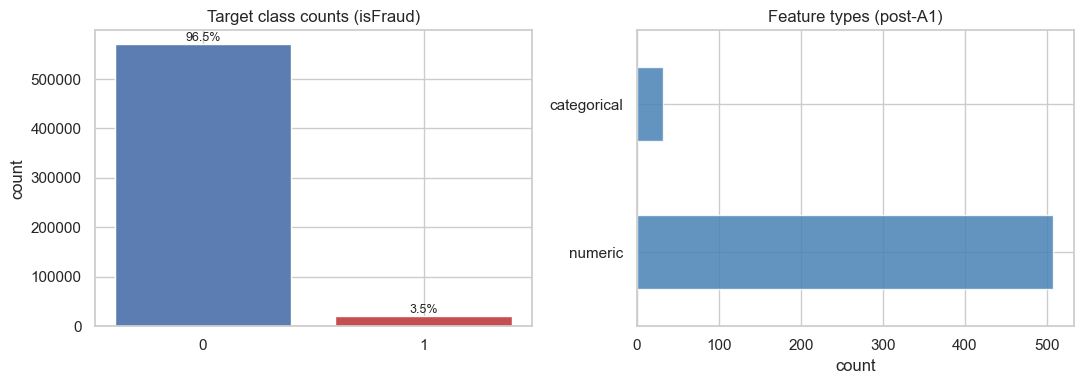

In [108]:
target_col = 'isFraud'
id_cols = [c for c in ['TransactionID'] if c in df.columns]
feature_cols = [c for c in df.columns if c not in id_cols + [target_col]]
categorical_cols = [c for c in feature_cols if df[c].dtype == 'object' or str(df[c].dtype).startswith('category')]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

audit_table = pd.DataFrame({
    'item': ['rows', 'features', 'numeric_features', 'categorical_features', 'missing_cells'],
    'value': [len(df), len(feature_cols), len(numeric_cols), len(categorical_cols), int(df.isna().sum().sum())],
})
display(audit_table)

target_table = df[target_col].value_counts().sort_index().rename_axis(target_col).reset_index(name='count')
target_table['pct'] = 100 * target_table['count'] / len(df)
display(target_table)

minority_pct = target_table['pct'].min()
print(f'Target balance conclusion: imbalanced dataset; minority class is {minority_pct:.2f}% of rows.')
print('540 predictors after A1 preprocessing; missing_cells = 0.')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(target_table[target_col].astype(str), target_table['count'], color=['#5b7db1', '#c44e52'])
axes[0].set_title('Target class counts (isFraud)')
axes[0].set_ylabel('count')
for i, row in target_table.iterrows():
    axes[0].text(i, row['count'], f"{row['pct']:.1f}%", ha='center', va='bottom', fontsize=9)

feature_type_counts = pd.Series({
    'numeric': len(numeric_cols),
    'categorical': len(categorical_cols),
})
feature_type_counts.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.85)
axes[1].set_title('Feature types (post-A1)')
axes[1].set_xlabel('count')
plt.tight_layout()
plt.show()


In [109]:
# Modeling vs external holdout — disjoint by original CSV index.
FULL_ROWS = len(df)
df_modeling, df_reserve = train_test_split(
    df,
    train_size=MODELING_SAMPLE_SIZE,
    stratify=df[target_col],
    random_state=RANDOM_STATE,
)
df_external, df_unused_reserve = train_test_split(
    df_reserve,
    train_size=EXTERNAL_SAMPLE_SIZE,
    stratify=df_reserve[target_col],
    random_state=RANDOM_STATE + 1,
)
modeling_indices = set(df_modeling.index)
external_indices = set(df_external.index)
assert modeling_indices.isdisjoint(external_indices)

df_modeling = df_modeling.reset_index(drop=True)
df_external = df_external.reset_index(drop=True)

print(
    f'Full CSV: {len(df):,} | Modeling: {len(df_modeling):,} | '
    f'External holdout: {len(df_external):,} | Unused reserve: {len(df_unused_reserve):,}'
)
print(
    f'Modeling fraud rate: {df_modeling[target_col].mean():.4f} | '
    f'External fraud rate: {df_external[target_col].mean():.4f}'
)

split_audit = pd.DataFrame(
    [
        {'pool': 'full_csv', 'n_rows': FULL_ROWS, 'fraud_rate': df[target_col].mean()},
        {'pool': 'modeling', 'n_rows': len(df_modeling), 'fraud_rate': df_modeling[target_col].mean()},
        {
            'pool': 'external_holdout',
            'n_rows': len(df_external),
            'fraud_rate': df_external[target_col].mean(),
        },
        {
            'pool': 'unused_reserve',
            'n_rows': len(df_unused_reserve),
            'fraud_rate': df_unused_reserve[target_col].mean(),
        },
    ]
)
display(split_audit.round(4))
split_audit.to_csv('a2_split_audit.csv', index=False)
print('Saved a2_split_audit.csv')


Full CSV: 590,540 | Modeling: 80,000 | External holdout: 80,000 | Unused reserve: 430,540
Modeling fraud rate: 0.0350 | External fraud rate: 0.0350


,pool,n_rows,fraud_rate
0,full_csv,590540,0.035
1,modeling,80000,0.035
2,external_holdout,80000,0.035
3,unused_reserve,430540,0.035


Saved a2_split_audit.csv


## A1 Findings Summary Matrix

This section converts the strongest A1 findings into an explicit summary table and a matrix of plots. The purpose is to show what A1 already discovered before running new A2 selectors.

A1 highlighted strong fraud signals in the Vesta `V` blocks, missingness indicators, selected transaction fields, and categorical transaction/device fields. The table below recomputes simple evidence from the clean A1 output so the summary is data-backed.
**Note:** Summary plots below use the **modeling pool** (`df_modeling`, 80k) only. The external 80k holdout is not used in EDA.


In [110]:
# Resumen explicito de los mejores hallazgos de A1 con evidencia recalculada.
a1_candidate_features = [
    'V45', 'V86', 'V87', 'V257', 'V244', 'V242',
    'TransactionAmt', 'dist1', 'C1', 'C2',
    'addr1_isna', 'addr2_isna', 'card3_isna',
    'ProductCD', 'card4', 'card6', 'DeviceType', 'P_emaildomain', 'R_emaildomain',
]
a1_candidate_features = [c for c in a1_candidate_features if c in df.columns]

rows = []
for col in a1_candidate_features:
    if col in numeric_cols:
        fraud_mean = df.loc[df[target_col] == 1, col].mean()
        legit_mean = df.loc[df[target_col] == 0, col].mean()
        corr_value = abs(df[col].corr(df[target_col]))
        rows.append({
            'A1 group': 'numeric / indicator',
            'feature': col,
            'A1 evidence type': 'target correlation and class means',
            'evidence score': corr_value,
            'fraud mean': fraud_mean,
            'legitimate mean': legit_mean,
            'interpretation': 'Higher separation suggests stronger fraud signal.',
        })
    else:
        ct = pd.crosstab(df[col].astype(str), df[target_col])
        if ct.shape[0] > 1 and ct.shape[1] == 2:
            chi2_stat, p_value, _, _ = chi2_contingency(ct)
        else:
            chi2_stat, p_value = np.nan, np.nan
        rows.append({
            'A1 group': 'categorical',
            'feature': col,
            'A1 evidence type': 'category fraud-rate difference / chi-square',
            'evidence score': chi2_stat,
            'fraud mean': np.nan,
            'legitimate mean': np.nan,
            'interpretation': 'Different category fraud rates suggest categorical risk signal.',
        })

a1_summary_table = pd.DataFrame(rows).sort_values('evidence score', ascending=False)
display(a1_summary_table.head(20).round(4))


,A1 group,feature,A1 evidence type,evidence score,fraud mean,legitimate mean,interpretation
18,categorical,R_emaildomain,category fraud-rate difference / chi-square,17995.7943,NaN,NaN,Different category fraud rates suggest categor...
13,categorical,ProductCD,category fraud-rate difference / chi-square,16742.1715,NaN,NaN,Different category fraud rates suggest categor...
16,categorical,DeviceType,category fraud-rate difference / chi-square,12230.1655,NaN,NaN,Different category fraud rates suggest categor...
15,categorical,card6,category fraud-rate difference / chi-square,5960.3589,NaN,NaN,Different category fraud rates suggest categor...
17,categorical,P_emaildomain,category fraud-rate difference / chi-square,2734.2151,NaN,NaN,Different category fraud rates suggest categor...
14,categorical,card4,category fraud-rate difference / chi-square,365.3347,NaN,NaN,Different category fraud rates suggest categor...
0,numeric / indicator,V45,target correlation and class means,0.2354,1.8516,1.0585,Higher separation suggests stronger fraud signal.
1,numeric / indicator,V86,target correlation and class means,0.2223,1.5076,1.0387,Higher separation suggests stronger fraud signal.
2,numeric / indicator,V87,target correlation and class means,0.2216,1.6342,1.0645,Higher separation suggests stronger fraud signal.
10,numeric / indicator,addr1_isna,target correlation and class means,0.1595,0.3746,0.1017,Higher separation suggests stronger fraud signal.


Top 30 A1-style Pearson correlations with isFraud:


,feature,pearson_corr_with_isFraud,abs_corr
0,V45,0.2321,0.2321
1,V86,0.2230,0.2230
2,V87,0.2183,0.2183
3,V44,0.2175,0.2175
4,V52,0.1966,0.1966
5,V51,0.1827,0.1827
6,V40,0.1729,0.1729
7,V79,0.1685,0.1685
8,V39,0.1646,0.1646
9,V43,0.1628,0.1628


Saved a2_a1_summary_matrix.png (standalone — not in gallery)


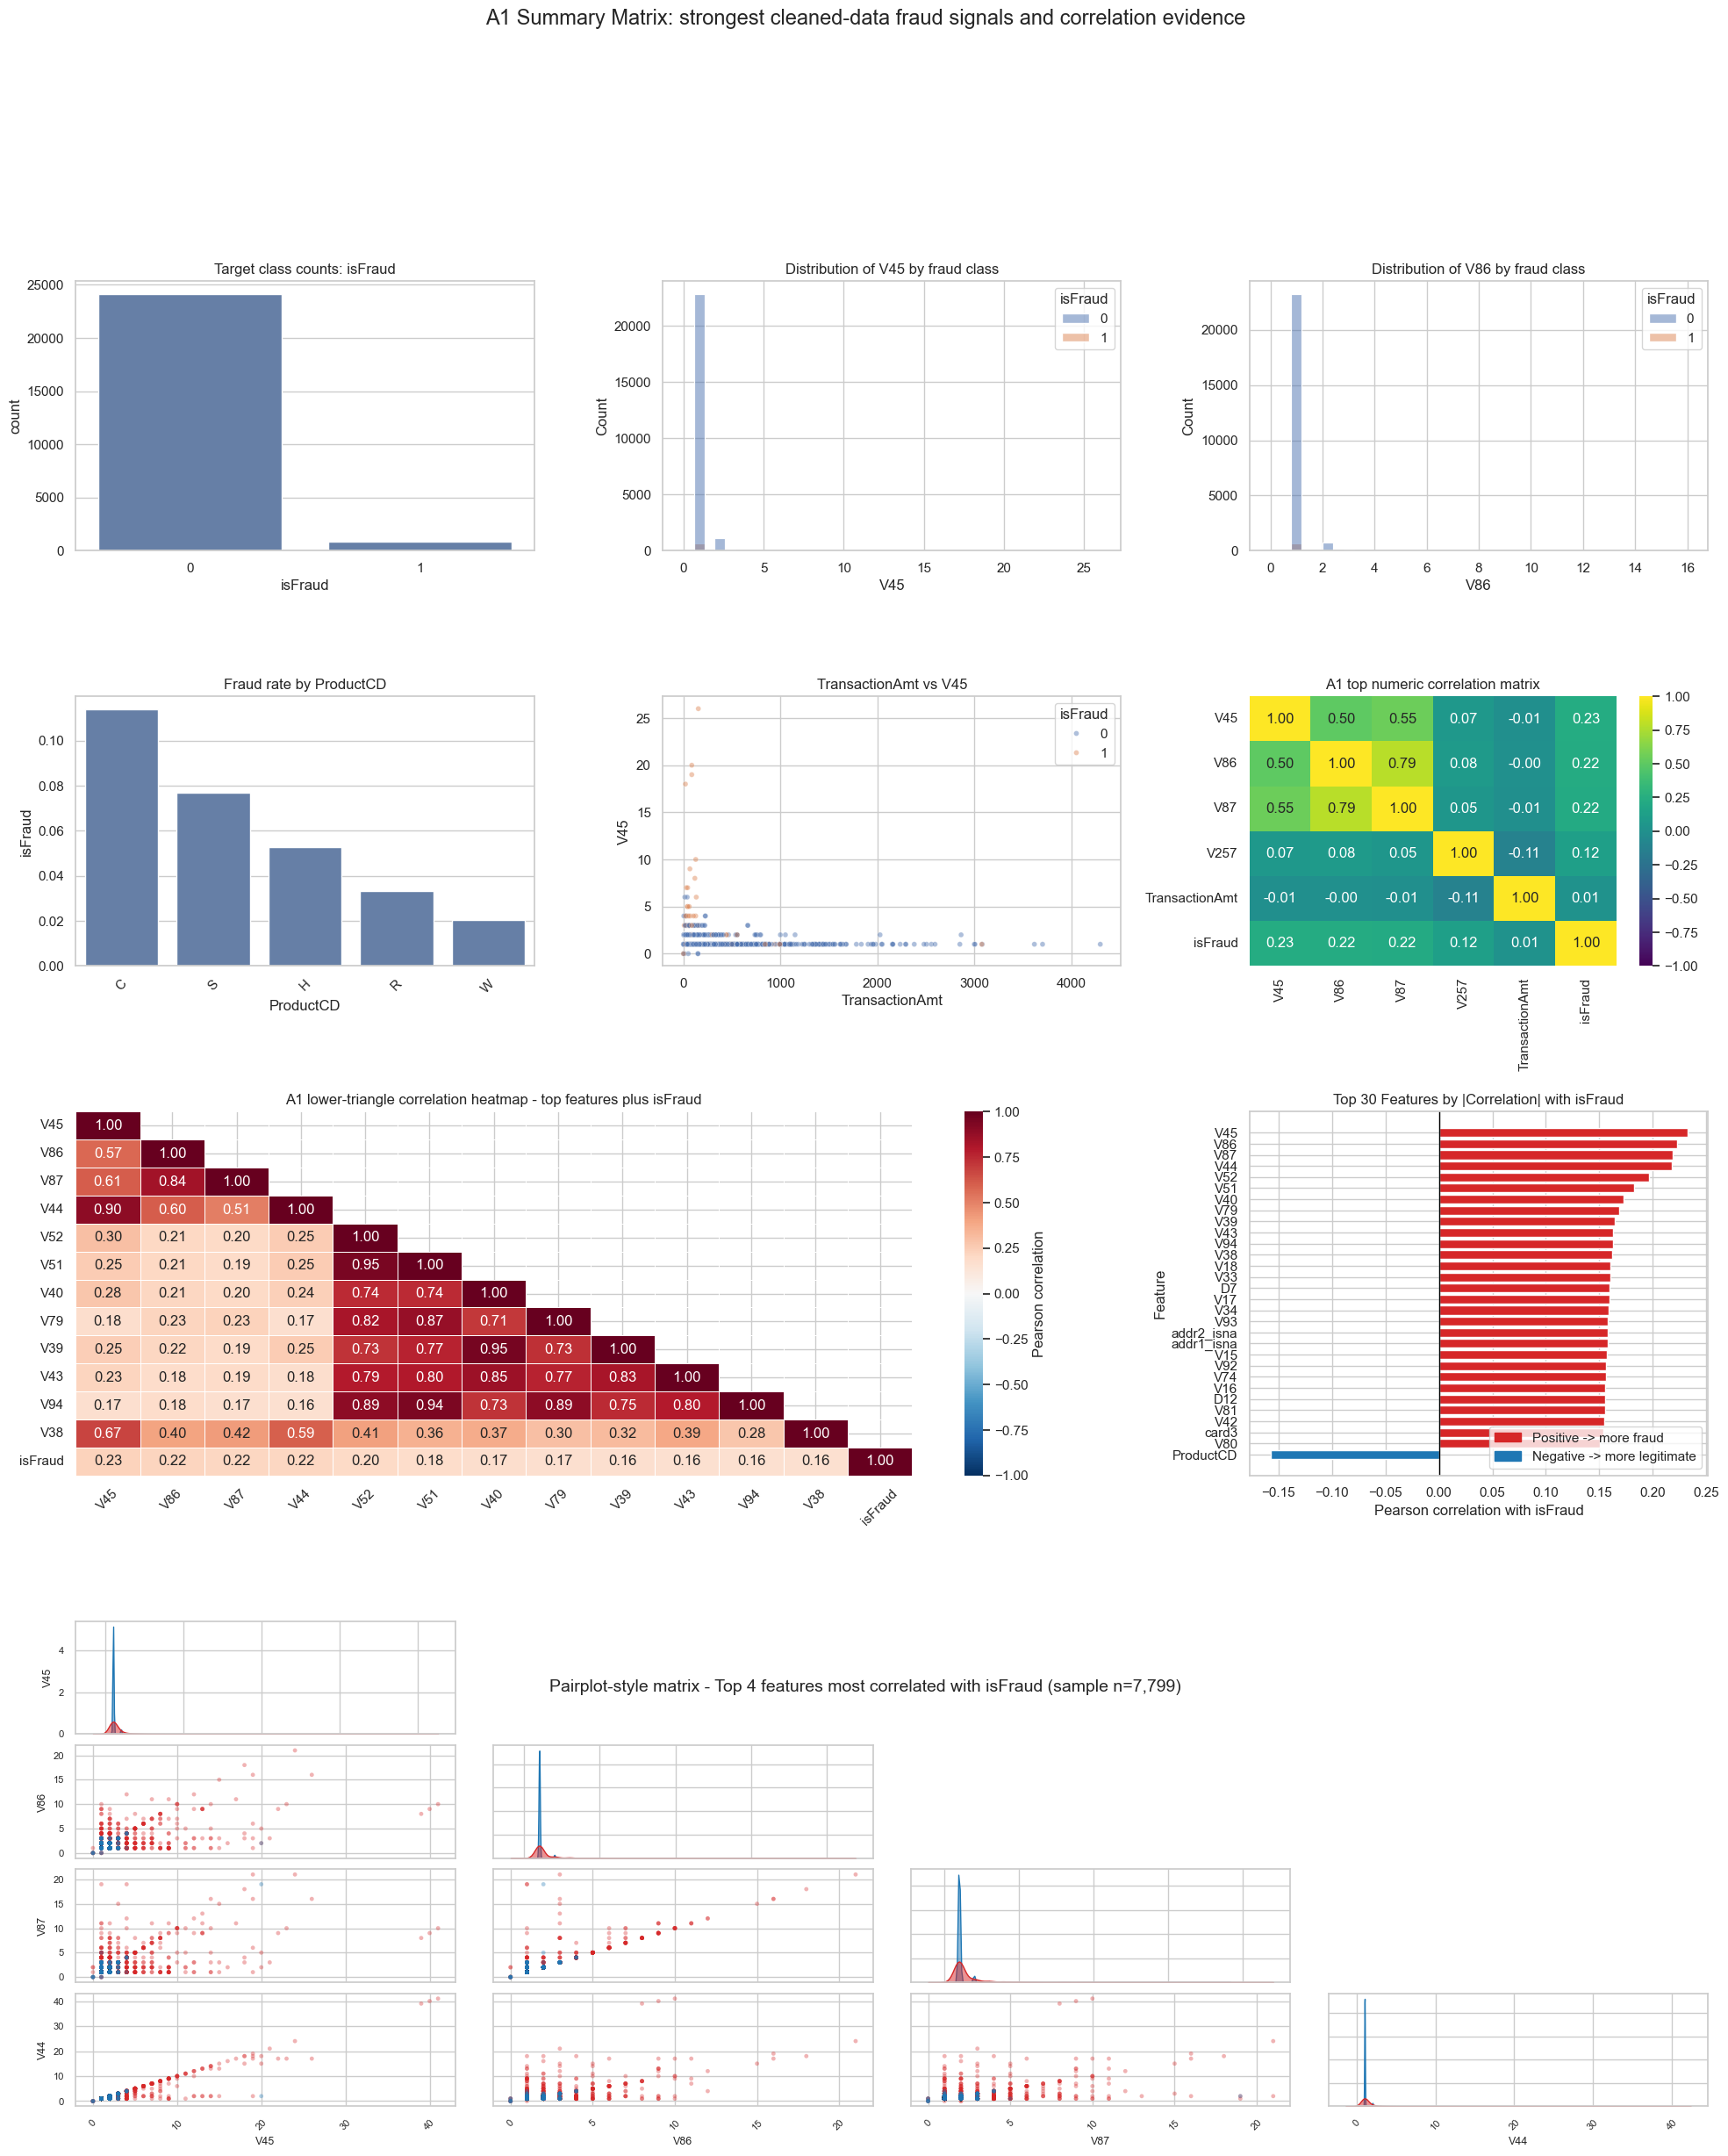

In [111]:
# Matriz de graficos estilo resumen: distribuciones, conteos, correlaciones y relaciones principales de A1.
# EDA plots use modeling pool only (external holdout locked until final section).
plot_df = df_modeling.copy()
if len(plot_df) > 25_000:
    plot_df, _ = train_test_split(
        plot_df,
        train_size=25_000,
        stratify=plot_df[target_col],
        random_state=RANDOM_STATE,
    )
plot_df = plot_df.reset_index(drop=True)

top_a1_numeric = [c for c in ['V45', 'V86', 'V87', 'V257', 'TransactionAmt'] if c in plot_df.columns]
first_num = top_a1_numeric[0] if top_a1_numeric else numeric_cols[0]
second_num = top_a1_numeric[1] if len(top_a1_numeric) > 1 else numeric_cols[1]
cat_feature = 'ProductCD' if 'ProductCD' in plot_df.columns else (categorical_cols[0] if categorical_cols else None)

# Correlaciones A1-style: codificacion temporal de categoricas solo para EDA.
corr_source = df_modeling[feature_cols + [target_col]].copy()

corr_encoded = pd.DataFrame(index=corr_source.index)
for col in feature_cols:
    if col in numeric_cols:
        corr_encoded[col] = pd.to_numeric(corr_source[col], errors='coerce')
    else:
        corr_encoded[col] = pd.factorize(corr_source[col].astype(str), sort=True)[0]
corr_encoded[target_col] = corr_source[target_col].astype(int)
corr_encoded = corr_encoded.replace([np.inf, -np.inf], np.nan).fillna(0)

corr_with_fraud = corr_encoded.drop(columns=[target_col]).corrwith(corr_encoded[target_col])
corr_abs = corr_with_fraud.abs().sort_values(ascending=False)
top30_corr = corr_with_fraud.loc[corr_abs.head(30).index].sort_values()
top_heat_features = corr_abs.head(12).index.tolist()
heat_features = top_heat_features + [target_col]
heat_corr = corr_encoded[heat_features].corr()
heat_mask = np.triu(np.ones_like(heat_corr, dtype=bool), k=1)

print('Top 30 A1-style Pearson correlations with isFraud:')
display(
    pd.DataFrame({
        'feature': corr_abs.head(30).index,
        'pearson_corr_with_isFraud': corr_with_fraud.loc[corr_abs.head(30).index].values,
        'abs_corr': corr_abs.head(30).values,
    }).round(4)
)

fig = plt.figure(figsize=(24, 27))
gs = fig.add_gridspec(4, 3, height_ratios=[1, 1, 1.35, 1.8], hspace=0.42, wspace=0.28)
ax_target = fig.add_subplot(gs[0, 0])
ax_hist_1 = fig.add_subplot(gs[0, 1])
ax_hist_2 = fig.add_subplot(gs[0, 2])
ax_cat = fig.add_subplot(gs[1, 0])
ax_scatter = fig.add_subplot(gs[1, 1])
ax_small_heat = fig.add_subplot(gs[1, 2])
ax_big_heat = fig.add_subplot(gs[2, 0:2])
ax_bar = fig.add_subplot(gs[2, 2])

sns.countplot(data=plot_df, x=target_col, ax=ax_target, color='#5b7db1')
ax_target.set_title('Target class counts: isFraud')

sns.histplot(data=plot_df, x=first_num, hue=target_col, bins=40, stat='count', common_norm=False, ax=ax_hist_1)
ax_hist_1.set_title(f'Distribution of {first_num} by fraud class')

sns.histplot(data=plot_df, x=second_num, hue=target_col, bins=40, stat='count', common_norm=False, ax=ax_hist_2)
ax_hist_2.set_title(f'Distribution of {second_num} by fraud class')

if cat_feature:
    cat_rate = plot_df.groupby(cat_feature)[target_col].mean().sort_values(ascending=False).head(10).reset_index()
    sns.barplot(data=cat_rate, x=cat_feature, y=target_col, ax=ax_cat, color='#5b7db1')
    ax_cat.set_title(f'Fraud rate by {cat_feature}')
    ax_cat.tick_params(axis='x', rotation=45)
else:
    ax_cat.axis('off')

scatter_x = 'TransactionAmt' if 'TransactionAmt' in plot_df.columns else first_num
scatter_y = first_num if first_num != scatter_x else second_num
sns.scatterplot(data=plot_df.sample(min(6000, len(plot_df)), random_state=RANDOM_STATE), x=scatter_x, y=scatter_y, hue=target_col, alpha=0.45, s=18, ax=ax_scatter)
ax_scatter.set_title(f'{scatter_x} vs {scatter_y}')

heat_features = [c for c in top_a1_numeric[:5] if c in plot_df.columns]
if len(heat_features) >= 2:
    heat_data = plot_df[heat_features + [target_col]].corr()
    sns.heatmap(heat_data, cmap='viridis', vmin=-1, vmax=1, annot=True, fmt='.2f', ax=ax_small_heat)
    ax_small_heat.set_title('A1 top numeric correlation matrix')
else:
    ax_small_heat.axis('off')

sns.heatmap(
    heat_corr,
    mask=heat_mask,
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    ax=ax_big_heat,
    cbar_kws={'label': 'Pearson correlation'},
)
ax_big_heat.set_title('A1 lower-triangle correlation heatmap - top features plus isFraud')
ax_big_heat.tick_params(axis='x', rotation=45)
ax_big_heat.tick_params(axis='y', rotation=0)

bar_vals = top30_corr.copy()
bar_colors = ['#d62728' if value > 0 else '#1f77b4' for value in bar_vals]
ax_bar.barh(bar_vals.index, bar_vals.values, color=bar_colors)
ax_bar.axvline(0, color='black', linewidth=1)
ax_bar.set_title('Top 30 Features by |Correlation| with isFraud')
ax_bar.set_xlabel('Pearson correlation with isFraud')
ax_bar.set_ylabel('Feature')
ax_bar.legend(
    handles=[
        Patch(color='#d62728', label='Positive -> more fraud'),
        Patch(color='#1f77b4', label='Negative -> more legitimate'),
    ],
    loc='lower right',
)

# 3) Pairplot-style lower-triangle matrix integrated into the same figure.
# Fewer dimensions than A1 so it stays readable inside this grid.
TOP_PAIR_GRID = 4
pair_features = corr_abs.head(TOP_PAIR_GRID).index.tolist()
pair_df = corr_encoded[pair_features + [target_col]].copy()
pair_df[target_col] = pair_df[target_col].map({0: 'Legitimate', 1: 'Fraud'})
if len(pair_df) > 6000:
    # Mantiene todos los fraudes posibles y una muestra de legitimos para que el pairplot sea legible.
    fraud_pair = pair_df[pair_df[target_col] == 'Fraud']
    legit_pair = pair_df[pair_df[target_col] == 'Legitimate'].sample(
        min(5000, (pair_df[target_col] == 'Legitimate').sum()),
        random_state=RANDOM_STATE,
    )
    pair_df = pd.concat([fraud_pair, legit_pair], ignore_index=True)

pair_gs = gs[3, :].subgridspec(len(pair_features), len(pair_features), hspace=0.10, wspace=0.10)
pair_palette = {'Legitimate': '#1f77b4', 'Fraud': '#d62728'}
for row, y_feature in enumerate(pair_features):
    for col, x_feature in enumerate(pair_features):
        ax_pair = fig.add_subplot(pair_gs[row, col])
        if col > row:
            ax_pair.axis('off')
            continue
        if row == col:
            try:
                sns.kdeplot(
                    data=pair_df,
                    x=x_feature,
                    hue=target_col,
                    fill=True,
                    alpha=0.5,
                    common_norm=False,
                    warn_singular=False,
                    palette=pair_palette,
                    legend=False,
                    ax=ax_pair,
                )
            except Exception:
                sns.histplot(
                    data=pair_df,
                    x=x_feature,
                    hue=target_col,
                    bins=30,
                    alpha=0.5,
                    palette=pair_palette,
                    legend=False,
                    ax=ax_pair,
                )
        else:
            sns.scatterplot(
                data=pair_df,
                x=x_feature,
                y=y_feature,
                hue=target_col,
                alpha=0.35,
                s=12,
                edgecolor='none',
                palette=pair_palette,
                legend=False,
                ax=ax_pair,
            )
        if row < len(pair_features) - 1:
            ax_pair.set_xlabel('')
            ax_pair.set_xticklabels([])
        else:
            ax_pair.set_xlabel(x_feature, fontsize=9)
            ax_pair.tick_params(axis='x', labelrotation=45)
        if col > 0:
            ax_pair.set_ylabel('')
            ax_pair.set_yticklabels([])
        else:
            ax_pair.set_ylabel(y_feature, fontsize=9)
        ax_pair.tick_params(labelsize=8)

fig.text(0.5, 0.285, f'Pairplot-style matrix - Top {TOP_PAIR_GRID} features most correlated with isFraud (sample n={len(pair_df):,})', ha='center', fontsize=14)

fig.suptitle('A1 Summary Matrix: strongest cleaned-data fraud signals and correlation evidence', fontsize=17, y=0.995)
fig.savefig('a2_a1_summary_matrix.png', dpi=150, bbox_inches='tight', facecolor='white')
print('Saved a2_a1_summary_matrix.png (standalone — not in gallery)')
plt.show()


## Feature Selection

Feature selection is the main A2 task, but it must be evaluated after the data split. The notebook will first define the target distribution and create `X_train`, `y_train`, `X_test`, and `y_test`; then every selector will be fitted only on `X_train`.

This ordering prevents data leakage while keeping the report organized around feature selection.

## Distribution and Train/Test Split

All modeling below uses `df_modeling` (80k, stratified). The target variable is binary: `isFraud = 0` means legitimate transaction and `isFraud = 1` means fraud transaction.

Example: if a dataset has 100 rows and the target has 90 rows of class 0 and 10 rows of class 1, the dataset is imbalanced. In that case, model evaluation should not depend only on accuracy. Depending on the model objective, oversampling, undersampling, or class weights may be considered.

For this notebook, the split is stratified and baseline models use class weights where the model supports them.


In [112]:
# Modeling pool fixed at load; external holdout is disjoint by index.
work_df = df_modeling.copy()

X = work_df[feature_cols]
y = work_df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SIZE, stratify=y_train, random_state=RANDOM_STATE
)

print(f'Modeling pool (work_df): {len(work_df):,} rows')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'X_fit: {X_fit.shape} | X_val: {X_val.shape}')
print(f'Train fraud rate: {y_train.mean():.4f} | Val: {y_val.mean():.4f} | Test: {y_test.mean():.4f}')

split_distribution = pd.DataFrame({
    'split': ['train', 'train', 'val', 'val', 'test', 'test'],
    'target_class': [0, 1, 0, 1, 0, 1],
    'count': [
        int((y_train == 0).sum()), int((y_train == 1).sum()),
        int((y_val == 0).sum()), int((y_val == 1).sum()),
        int((y_test == 0).sum()), int((y_test == 1).sum()),
    ],
})
split_distribution['pct_within_split'] = split_distribution.groupby('split')['count'].transform(lambda s: 100 * s / s.sum())
display(split_distribution)


Modeling pool (work_df): 80,000 rows
X_train: (60000, 540) | X_test: (20000, 540)
X_fit: (48000, 540) | X_val: (12000, 540)
Train fraud rate: 0.0350 | Val: 0.0350 | Test: 0.0350


,split,target_class,count,pct_within_split
0,train,0,57901,96.501667
1,train,1,2099,3.498333
2,val,0,11580,96.500000
3,val,1,420,3.500000
4,test,0,19300,96.500000
5,test,1,700,3.500000


## Feature engineering (A2 only): TransactionAmt bands

A1 EDA showed **low linear correlation** between `TransactionAmt` and `isFraud` (~0.01). Following Brownlee, we add a **categorical band** (bins fit on `X_fit` only) so chi²/MI can score it like `ProductCD`. The original numeric column is kept.


In [113]:
if 'TransactionAmt' not in X_fit.columns:
    raise KeyError('TransactionAmt required for banding')

amt_fit = X_fit['TransactionAmt'].dropna()
_, bin_edges = pd.qcut(amt_fit, q=AMT_N_BINS, retbins=True, duplicates='drop')
_band_labels = ['Low', 'Med-Low', 'Med-High', 'High'][: len(bin_edges) - 1]

def assign_amt_band(series):
    return pd.cut(series, bins=bin_edges, labels=_band_labels, include_lowest=True).astype(str)

df_external[AMT_BAND_COL] = assign_amt_band(df_external['TransactionAmt'])
for _frame in (work_df, X_train, X_test, X_fit, X_val):
    _frame[AMT_BAND_COL] = assign_amt_band(_frame['TransactionAmt'])

if AMT_BAND_COL not in feature_cols:
    feature_cols.append(AMT_BAND_COL)
if AMT_BAND_COL not in categorical_cols:
    categorical_cols.append(AMT_BAND_COL)

print(f'Added {AMT_BAND_COL} with {len(_band_labels)} bins (edges fit on X_fit only)')
band_rates = pd.concat([X_val[[AMT_BAND_COL]], y_val], axis=1).groupby(AMT_BAND_COL)['isFraud'].agg(['mean', 'count'])
band_rates.columns = ['fraud_rate', 'count']
display(band_rates)


Added TransactionAmt_band with 4 bins (edges fit on X_fit only)


,fraud_rate,count
TransactionAmt_band,,
High,0.045518,2878
Low,0.043151,3059
Med-High,0.029190,3049
Med-Low,0.022561,3014


## Modeling Utilities (fit / validation / test protocol)


In [114]:
# Shared evaluation and modeling utilities (fit on X_fit, tune threshold on X_val).

def evaluate_predictions(y_true, y_pred, y_score, label, n_features):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Model': label,
        'N Feats': n_features,
        'Accuracy': (tp + tn) / (tp + tn + fp + fn),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'F2': fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        'AUC': roc_auc_score(y_true, y_score),
        'AUC_PR': average_precision_score(y_true, y_score),
        'Specificity': tn / (tn + fp) if (tn + fp) else np.nan,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
    }


def build_feature_pipeline(features, classifier=None):
    selected_numeric = [c for c in features if c in numeric_cols]
    selected_categorical = [c for c in features if c in categorical_cols]
    transformers = []
    if selected_numeric:
        transformers.append((
            'num',
            Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]),
            selected_numeric,
        ))
    if selected_categorical:
        try:
            enc = OneHotEncoder(handle_unknown='ignore', sparse_output=True, min_frequency=20)
        except TypeError:
            enc = OneHotEncoder(handle_unknown='ignore', sparse=True)
        transformers.append((
            'cat',
            Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', enc)]),
            selected_categorical,
        ))
    clf = classifier if classifier is not None else PRIMARY_CLASSIFIER
    return Pipeline([('prep', ColumnTransformer(transformers, remainder='drop')), ('clf', clf)])


def select_threshold_policy(y_true, y_score, label, n_features,
                            target_recall=TARGET_RECALL, min_accuracy=MIN_POLICY_ACCURACY):
    rows = []
    for threshold in np.arange(0.01, 1.00, 0.01):
        y_pred = (y_score >= threshold).astype(int)
        metrics = evaluate_predictions(y_true, y_pred, y_score, label, n_features)
        metrics['Threshold'] = threshold
        rows.append(metrics)
    table = pd.DataFrame(rows)
    feasible = table[(table['Recall'] >= target_recall) & (table['Accuracy'] >= min_accuracy)]
    if len(feasible):
        best = feasible.sort_values(['F2', 'Precision', 'AUC_PR'], ascending=False).head(1).copy()
        best['policy_status'] = f'Recall >= {target_recall:.2f}, accuracy >= {min_accuracy:.2f}'
    else:
        fallback = table[table['Accuracy'] >= min_accuracy]
        if len(fallback):
            best = fallback.sort_values(['Recall', 'F2', 'AUC_PR'], ascending=False).head(1).copy()
            best['policy_status'] = f'Best recall with accuracy >= {min_accuracy:.2f}'
        else:
            best = table.sort_values(['F2', 'Recall', 'AUC_PR'], ascending=False).head(1).copy()
            best['policy_status'] = f'Best F2; accuracy < {min_accuracy:.2f}'
    return table, best.iloc[0]


def to_metrics_row(best, source, n_feats=None):
    """Convert Series or dict from fit_rf_tune_val to flat dict for pd.DataFrame."""
    row = best.to_dict() if isinstance(best, pd.Series) else dict(best)
    row['source'] = source
    if n_feats is not None:
        row['N Feats'] = n_feats
    return row




def prune_correlated_features(features, X_ref, y_ref, threshold=0.82,
                              score_lookup=None, isna_suffix='_isna'):
    """Drop one of each highly correlated pair; keep higher fraud association or score_lookup."""
    feats = [f for f in features if f in X_ref.columns]
    num_feats = [f for f in feats if f in numeric_cols and not str(f).endswith(isna_suffix)]
    if len(num_feats) < 2:
        return feats
    Xn = X_ref[num_feats].apply(pd.to_numeric, errors='coerce')
    corr = Xn.corr().abs()
    drop = set()
    fraud_corr = Xn.corrwith(y_ref).abs().fillna(0)
    for i, a in enumerate(num_feats):
        if a in drop:
            continue
        for b in num_feats[i + 1:]:
            if b in drop:
                continue
            if corr.loc[a, b] < threshold:
                continue
            sa = score_lookup.get(a, fraud_corr[a]) if score_lookup else fraud_corr[a]
            sb = score_lookup.get(b, fraud_corr[b]) if score_lookup else fraud_corr[b]
            drop.add(b if sa >= sb else a)
    return [f for f in feats if f not in drop]


def fit_rf_tune_val(features, label):
    features = [f for f in features if f in feature_cols]
    model = build_feature_pipeline(features, PRIMARY_CLASSIFIER)
    model.fit(X_fit[features], y_fit)
    y_score_val = model.predict_proba(X_val[features])[:, 1]
    _, best = select_threshold_policy(y_val, y_score_val, label, len(features))
    return model, best


def evaluate_on_test(model, threshold, features, label):
    features = [f for f in features if f in feature_cols]
    y_score = model.predict_proba(X_test[features])[:, 1]
    y_pred = (y_score >= threshold).astype(int)
    metrics = evaluate_predictions(y_test, y_pred, y_score, label, len(features))
    metrics['Threshold'] = threshold
    return metrics


# A1 anchor features for overlap tie-break (top Pearson on full preprocessed sample used in A1 summary)
_a1_numeric = X_train[numeric_cols].select_dtypes(include=[np.number])
if len(_a1_numeric.columns):
    _a1_corr = _a1_numeric.corrwith(y_train).abs().sort_values(ascending=False)
    A1_TOP_FEATURES = set(_a1_corr.head(30).index)
else:
    A1_TOP_FEATURES = set()


def pick_univariate_winner(sweep_df):
    df = sweep_df.copy()
    feasible = df[(df['Recall'] >= TARGET_RECALL) & (df['Accuracy'] >= MIN_POLICY_ACCURACY)]
    pool = feasible if len(feasible) else df
    pool = pool.sort_values(['Recall', 'F2', 'AUC_PR', 'k'], ascending=[False, False, False, True])
    best_row = pool.iloc[0]
    feats = score_tables[best_row['method']].head(int(best_row['k'])).index.tolist()
    overlap = len(set(feats) & A1_TOP_FEATURES)
    tied = pool[pool['Recall'] == best_row['Recall']]
    if len(tied) > 1:
        for _, row in tied.iterrows():
            f = score_tables[row['method']].head(int(row['k'])).index.tolist()
            o = len(set(f) & A1_TOP_FEATURES)
            if o > overlap or (o == overlap and row['k'] < best_row['k']):
                best_row, feats, overlap = row, f, o
    return best_row, feats


def run_univariate_k_sweep():
    rows = []
    for method, scores in score_tables.items():
        for k in K_GRID:
            feats = scores.head(k).index.tolist()
            _, best = fit_rf_tune_val(feats, f'{method} top-{k}')
            rows.append({
                'method': method,
                'k': k,
                'n_features': len(feats),
                **{c: best[c] for c in ['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'F2', 'AUC', 'AUC_PR', 'Specificity', 'policy_status']},
            })
    return pd.DataFrame(rows)


## Step 3 - Baseline Models (All Predictors)

The baseline uses **all 540 predictors** from the clean A1 dataset. The same `X_train`, `y_train`, `X_test`, and `y_test` split is passed to multiple classification models. This is used as the baseline for comparison before univariate feature selection or CFS.

Performance metrics reported:

- **AUC / ROC graph:** overall ranking ability across thresholds.
- **F1:** balance between precision and recall.
- **Recall:** TP / (TP + FN), fraud cases correctly detected.
- **Precision:** TP / (TP + FP), predicted fraud cases that are truly fraud.
- **Specificity:** TN / (TN + FP), legitimate cases correctly rejected as non-fraud.
- **TN, TP, FN, FP:** confusion-matrix counts.

The target labels are `legitimate (0)` and `fraud (1)`.

Training baseline on X_fit: Logistic Regression
Training baseline on X_fit: Decision Tree
Training baseline on X_fit: Random Forest
Training baseline on X_fit: Extra Trees


,Model,N Feats,Accuracy,Precision,Recall,F1,F2,AUC,AUC_PR,Specificity,TN,FP,FN,TP
0,Random Forest (All 541) @0.5,541,0.9148,0.2344,0.6333,0.3421,0.4725,0.8810,0.4574,0.9250,10711,869,154,266
1,Extra Trees (All 541) @0.5,541,0.8425,0.1449,0.7143,0.2410,0.4000,0.8606,0.3731,0.8472,9810,1770,120,300
2,Logistic Regression (All 541) @0.5,541,0.8290,0.1360,0.7262,0.2292,0.3888,0.8591,0.3900,0.8327,9643,1937,115,305
3,Decision Tree (All 541) @0.5,541,0.8378,0.1356,0.6762,0.2259,0.3763,0.8022,0.3915,0.8437,9770,1810,136,284


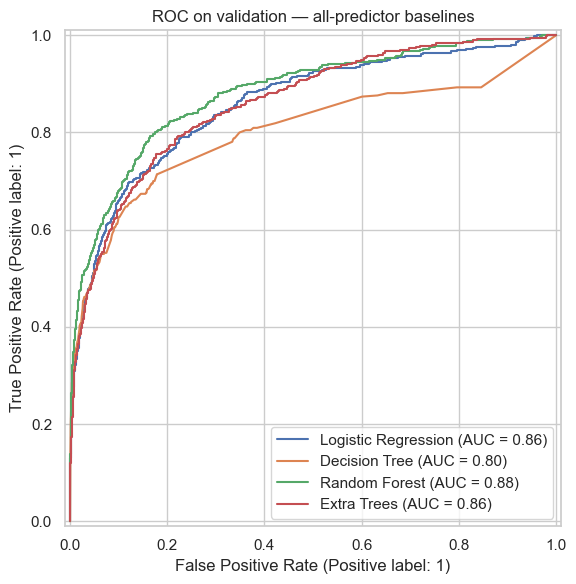

,Model,N Feats,Accuracy,Precision,Recall,F1,F2,AUC,AUC_PR,Specificity,TN,FP,FN,TP,Threshold,policy_status
28,"Baseline RF (540, val-tuned)",541,0.711083,0.095567,0.857143,0.171961,0.330457,0.882463,0.460723,0.705786,8173,3407,60,360,0.29,Best recall with accuracy >= 0.70


In [115]:
try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True, min_frequency=20)
except TypeError:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=True)

baseline_preprocess = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', encoder)]), categorical_cols),
])

baseline_classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=12, min_samples_leaf=40, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=14, min_samples_leaf=30, class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, max_depth=14, min_samples_leaf=30, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),
}

baseline_models = {}
baseline_rows = []
baseline_val_scores = {}

for model_name, classifier in baseline_classifiers.items():
    print(f'Training baseline on X_fit: {model_name}')
    model = Pipeline([('prep', baseline_preprocess), ('clf', classifier)])
    model.fit(X_fit, y_fit)
    y_score_val = model.predict_proba(X_val)[:, 1]
    y_pred_val = (y_score_val >= 0.5).astype(int)
    metrics = evaluate_predictions(y_val, y_pred_val, y_score_val, f'{model_name} (All {len(feature_cols)}) @0.5', len(feature_cols))
    baseline_rows.append(metrics)
    baseline_models[model_name] = model
    baseline_val_scores[model_name] = y_score_val

baseline_results = pd.DataFrame(baseline_rows).sort_values('AUC', ascending=False).reset_index(drop=True)
baseline_metrics = baseline_results.iloc[0].to_dict()
display(baseline_results.round(4))

fig, ax = plt.subplots(figsize=(8, 6))
for model_name, model in baseline_models.items():
    RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax, name=model_name)
ax.set_title('ROC on validation — all-predictor baselines')
plt.tight_layout()
plt.show()

# RF on all 540 features with recall-first threshold tuned on validation (comparison baseline)
_, baseline_rf_tuned = fit_rf_tune_val(feature_cols, 'Baseline RF (540, val-tuned)')
display(baseline_rf_tuned.to_frame().T)


### Recall-First Baseline Decision Policy

For fraud detection, the business preference is: **capture more false positives if that reduces false negatives**. In plain terms, it is better to flag extra legitimate transactions for review than to let fraud pass.

This means the default probability threshold of `0.50` is not necessarily the best operating point. The code below sweeps thresholds for every baseline classifier and finds the best threshold under a recall-first rule:

- primary goal: reach at least `0.90` fraud recall;
- guardrail: keep accuracy at or above `0.70`;
- secondary goal: maximize F2 score, which gives recall more weight than precision;
- third goal: keep precision and specificity as high as possible after recall is prioritized.

A model with lower accuracy can be better for this problem if it catches substantially more fraud.

,Model,policy_status,Threshold,N Feats,Accuracy,Precision,Recall,F1,F2,AUC,AUC_PR,Specificity
0,Random Forest (All 541),Best recall with accuracy >= 0.70,0.29,541,0.7093,0.0959,0.8667,0.1727,0.3324,0.8810,0.4574,0.7036
1,Logistic Regression (All 541),Best recall with accuracy >= 0.70,0.35,541,0.7054,0.0920,0.8357,0.1657,0.3193,0.8591,0.3900,0.7007
2,Extra Trees (All 541),Best recall with accuracy >= 0.70,0.39,541,0.7108,0.0929,0.8286,0.1671,0.3207,0.8606,0.3731,0.7066
3,Decision Tree (All 541),Best recall with accuracy >= 0.70,0.29,541,0.8164,0.1259,0.7143,0.2141,0.3692,0.8022,0.3915,0.8201


Recommended recall-first baseline (val): Random Forest (All 541) at threshold 0.29


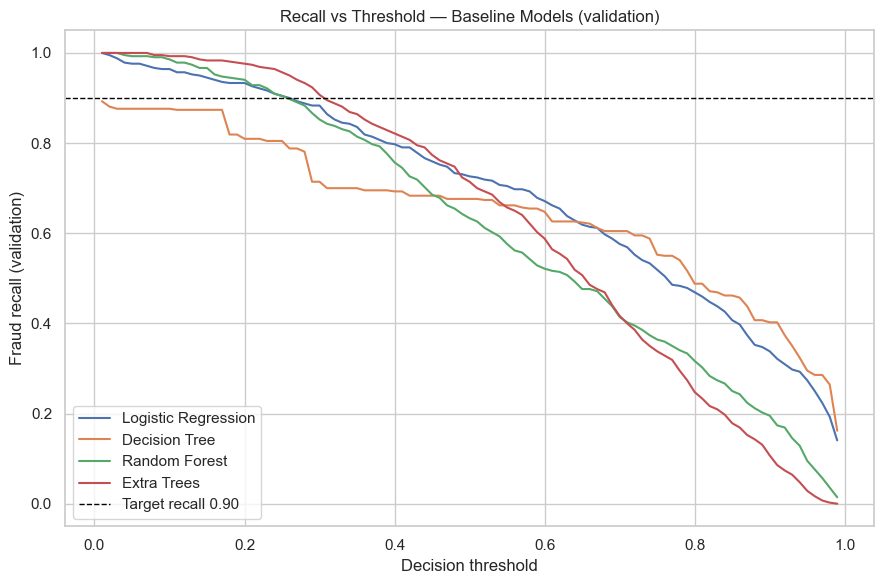

In [116]:
policy_tables = {}
best_policy_rows = []
for model_name, y_score_val in baseline_val_scores.items():
    table, best = select_threshold_policy(y_val, y_score_val, model_name, len(feature_cols))
    best['Model'] = f'{model_name} (All {len(feature_cols)})'
    policy_tables[model_name] = table
    best_policy_rows.append(best)

baseline_recall_policy = pd.DataFrame(best_policy_rows).sort_values(
    ['Recall', 'F2', 'Precision', 'AUC_PR'], ascending=False
).reset_index(drop=True)
display(baseline_recall_policy[[
    'Model', 'policy_status', 'Threshold', 'N Feats', 'Accuracy', 'Precision', 'Recall',
    'F1', 'F2', 'AUC', 'AUC_PR', 'Specificity'
]].round(4))

recommended_baseline_model = baseline_recall_policy.iloc[0]['Model']
recommended_threshold = baseline_recall_policy.iloc[0]['Threshold']
print(f'Recommended recall-first baseline (val): {recommended_baseline_model} at threshold {recommended_threshold:.2f}')

fig, ax = plt.subplots(figsize=(9, 6))
for model_name, table in policy_tables.items():
    ax.plot(table['Threshold'], table['Recall'], label=model_name)
ax.axhline(TARGET_RECALL, color='black', linestyle='--', linewidth=1, label=f'Target recall {TARGET_RECALL:.2f}')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Fraud recall (validation)')
ax.set_title('Recall vs Threshold — Baseline Models (validation)')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()


## Classifier choice for IEEE-CIS fraud (~3.5% fraud)

We compared four baselines on **all 540+ predictors** with the same preprocessing and recall-first threshold search on validation.
**Random Forest** is the primary classifier (`PRIMARY_CLASSIFIER`) for feature-selection comparisons because it handles mixed types (via one-hot), class imbalance (`balanced_subsample`), and non-linear fraud patterns without heavy tuning.
Logistic Regression is a linear benchmark; trees are stronger on V-features and interactions but less interpretable at full dimension.
All filter winners (univariate, CFS, merged, PCA+RF) are ranked with the **same RF + threshold policy** so differences reflect features, not a different learner.


In [117]:
classifier_comparison = baseline_recall_policy[[
    'Model', 'Recall', 'F2', 'AUC_PR', 'Precision', 'Specificity', 'Threshold', 'policy_status'
]].copy()
classifier_comparison['recommended'] = classifier_comparison['Model'] == recommended_baseline_model
display(classifier_comparison.round(4))
classifier_comparison.to_csv('a2_classifier_comparison.csv', index=False)
print('Saved a2_classifier_comparison.csv')
print(f'PRIMARY_CLASSIFIER in this notebook: {PRIMARY_CLASSIFIER.__class__.__name__}')
print(f'Used for all filter/PCA evaluations after baseline selection.')

,Model,Recall,F2,AUC_PR,Precision,Specificity,Threshold,policy_status,recommended
0,Random Forest (All 541),0.8667,0.3324,0.4574,0.0959,0.7036,0.29,Best recall with accuracy >= 0.70,True
1,Logistic Regression (All 541),0.8357,0.3193,0.3900,0.0920,0.7007,0.35,Best recall with accuracy >= 0.70,False
2,Extra Trees (All 541),0.8286,0.3207,0.3731,0.0929,0.7066,0.39,Best recall with accuracy >= 0.70,False
3,Decision Tree (All 541),0.7143,0.3692,0.3915,0.1259,0.8201,0.29,Best recall with accuracy >= 0.70,False


Saved a2_classifier_comparison.csv
PRIMARY_CLASSIFIER in this notebook: RandomForestClassifier
Used for all filter/PCA evaluations after baseline selection.


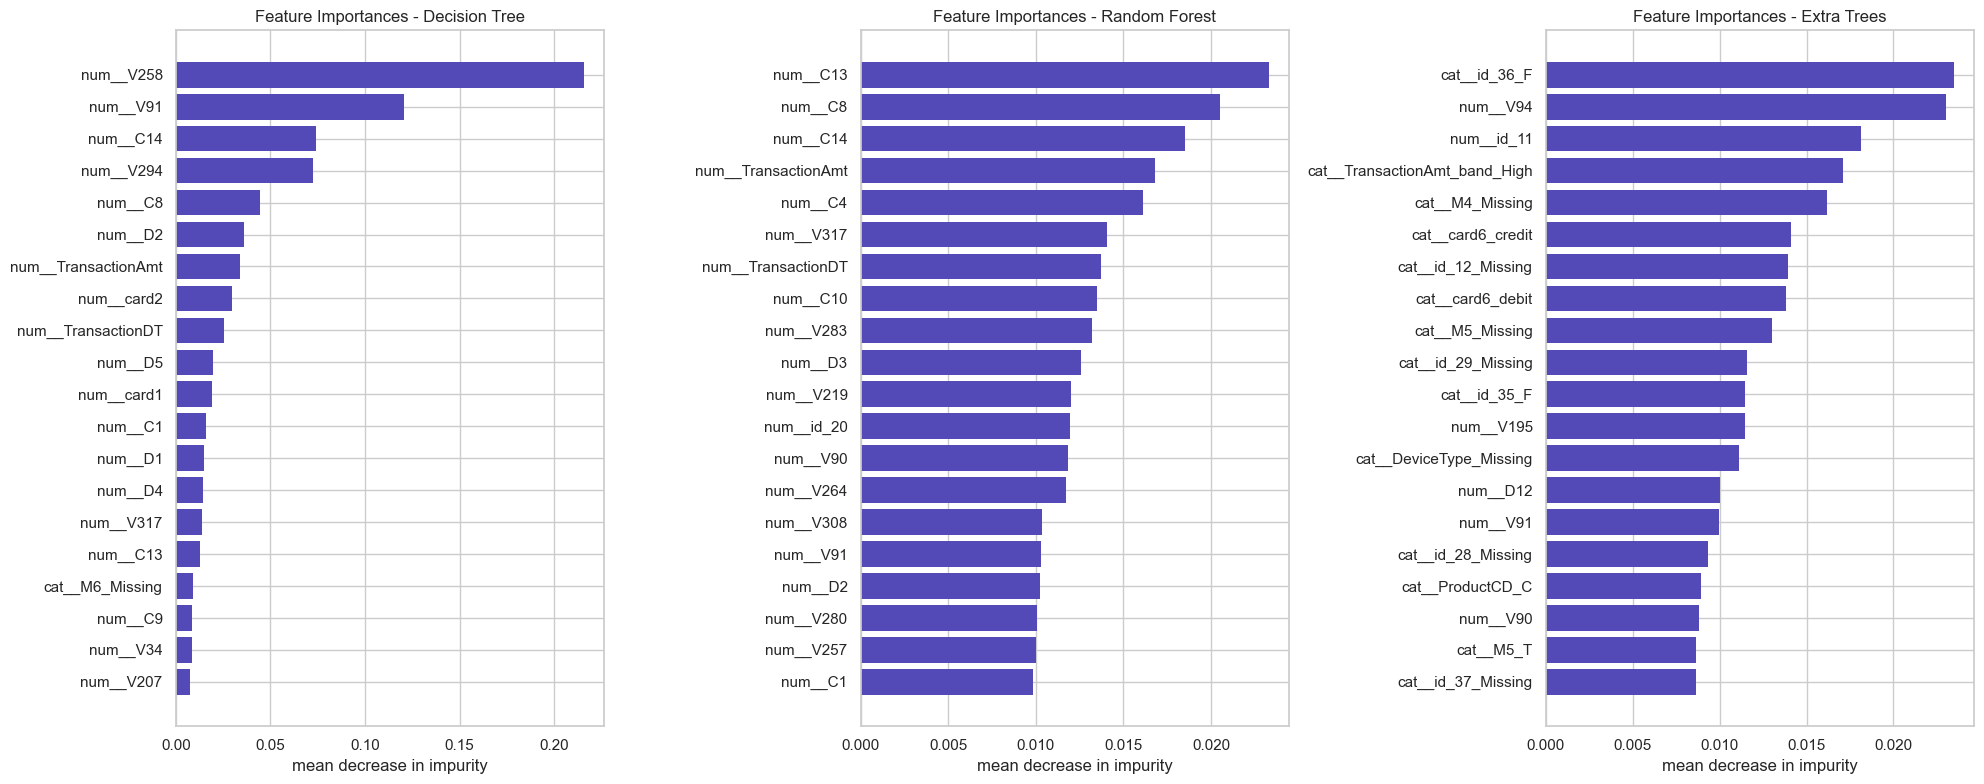

In [118]:
# Feature importance for tree-based all-predictor baselines.
try:
    transformed_feature_names = baseline_models['Random Forest'].named_steps['prep'].get_feature_names_out()
except Exception:
    transformed_feature_names = np.array([f'feature_{i}' for i in range(len(baseline_models['Random Forest'].named_steps['clf'].feature_importances_))])

tree_importance_models = ['Decision Tree', 'Random Forest', 'Extra Trees']
fig, axes = plt.subplots(1, len(tree_importance_models), figsize=(20, 8))
for ax, model_name in zip(axes, tree_importance_models):
    clf = baseline_models[model_name].named_steps['clf']
    importance_df = (
        pd.DataFrame({'feature': transformed_feature_names, 'importance': clf.feature_importances_})
        .sort_values('importance', ascending=False)
        .head(20)
        .sort_values('importance', ascending=True)
    )
    ax.barh(importance_df['feature'], importance_df['importance'], color='#534AB7', edgecolor='none')
    ax.set_xlabel('mean decrease in impurity')
    ax.set_title(f'Feature Importances - {model_name}')
plt.tight_layout()
plt.show()


## Feature Selection Scores (Train Only)

This section runs the five univariate validation methods on the training set (Zouhri et al., 2023):

1. Pearson absolute correlation against target.
2. ANOVA F-statistic against target.
3. Chi-square score against target.
4. ReliefF-style nearest-neighbor weight.
5. Mutual Information with target.

The output is a normalized top-feature chart and a table of the best features by method.


In [119]:
# Univariate scores — train only (full X_train for feature ranking).
X_train_num = X_train[numeric_cols].copy()
num_median = X_train_num.median(numeric_only=True)
X_train_num = X_train_num.fillna(num_median)

pearson_scores = X_train_num.corrwith(y_train).abs().replace([np.inf, -np.inf], np.nan).fillna(0)
pearson_source = pd.Series('numeric', index=pearson_scores.index)

if categorical_cols:
    try:
        pearson_ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, min_frequency=20)
    except TypeError:
        pearson_ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
    X_train_cat = X_train[categorical_cols].astype(str).fillna('Missing')
    X_cat_ohe = pearson_ohe.fit_transform(X_train_cat)
    cat_ohe_names = pearson_ohe.get_feature_names_out(categorical_cols)
    cat_corr = pd.DataFrame(X_cat_ohe, columns=cat_ohe_names, index=X_train.index).corrwith(y_train).abs().fillna(0)
    cat_pearson_scores = {}
    for col in categorical_cols:
        matching = [name for name in cat_corr.index if name.startswith(col + '_')]
        if matching:
            cat_pearson_scores[col] = cat_corr.loc[matching].max()
    cat_pearson_scores = pd.Series(cat_pearson_scores, dtype=float)
    pearson_scores = pd.concat([pearson_scores, cat_pearson_scores]).sort_values(ascending=False)
    pearson_source = pd.concat([pearson_source, pd.Series('categorical_one_hot_max', index=cat_pearson_scores.index)])

anova_f, anova_p = f_classif(X_train_num, y_train)
anova_scores = pd.Series(anova_f, index=numeric_cols).replace([np.inf, -np.inf], np.nan).fillna(0)
anova_pvalues = pd.Series(anova_p, index=numeric_cols).replace([np.inf, -np.inf], np.nan).fillna(1)

if categorical_cols:
    try:
        chi_ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, min_frequency=20)
    except TypeError:
        chi_ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
    X_train_cat = X_train[categorical_cols].astype(str).fillna('Missing')
    X_chi_cat = chi_ohe.fit_transform(X_train_cat)
    chi_names = chi_ohe.get_feature_names_out(categorical_cols)
    chi_scores_arr, chi_p_arr = chi2(X_chi_cat, y_train)
    chi_dummy_scores = pd.Series(chi_scores_arr, index=chi_names).replace([np.inf, -np.inf], np.nan).fillna(0)
    chi_dummy_pvalues = pd.Series(chi_p_arr, index=chi_names).replace([np.inf, -np.inf], np.nan).fillna(1)
    chi_scores, chi_pvalues = {}, {}
    for col in categorical_cols:
        matching = [name for name in chi_dummy_scores.index if name.startswith(col + '_')]
        if matching:
            chi_scores[col] = chi_dummy_scores.loc[matching].max()
            chi_pvalues[col] = chi_dummy_pvalues.loc[matching].min()
    chi_scores = pd.Series(chi_scores, dtype=float)
    chi_pvalues = pd.Series(chi_pvalues, dtype=float)
else:
    chi_scores = pd.Series(dtype=float)
    chi_pvalues = pd.Series(dtype=float)

# Mutual Information (5th univariate — paper)
mi_num = mutual_info_classif(X_train_num, y_train, random_state=RANDOM_STATE)
mi_scores = pd.Series(mi_num, index=numeric_cols).replace([np.inf, -np.inf], np.nan).fillna(0)
if categorical_cols:
    X_mi_cat = chi_ohe.transform(X_train_cat)
    mi_cat_arr = mutual_info_classif(X_mi_cat, y_train, random_state=RANDOM_STATE)
    mi_dummy = pd.Series(mi_cat_arr, index=chi_names)
    cat_mi_scores = {}
    for col in categorical_cols:
        matching = [name for name in mi_dummy.index if name.startswith(col + '_')]
        if matching:
            cat_mi_scores[col] = mi_dummy.loc[matching].max()
    mi_scores = pd.concat([mi_scores, pd.Series(cat_mi_scores, dtype=float)]).sort_values(ascending=False)

_mixed_cat_maps = {}
X_train_mixed = X_train_num.copy()
for col in categorical_cols:
    train_s = X_train[col].astype(str).fillna('Missing')
    codes, uniques = pd.factorize(train_s, sort=True)
    _mixed_cat_maps[col] = {u: i for i, u in enumerate(uniques)}
    X_train_mixed[col] = codes
X_train_cfs = X_train_mixed.copy()


def build_mixed_matrix(X_df):
    """Numeric + categoricals encoded with train category maps (for PCA / mixed models)."""
    out = X_df[numeric_cols].copy().fillna(num_median)
    for col in categorical_cols:
        s = X_df[col].astype(str).fillna('Missing')
        out[col] = s.map(_mixed_cat_maps[col]).fillna(-1).astype(int)
    return out



def relief_style_scores(X_df, y_series, sample_size=3000, n_neighbors=1):
    rng = np.random.default_rng(RANDOM_STATE)
    if len(X_df) > sample_size:
        idx = rng.choice(len(X_df), size=sample_size, replace=False)
        X_relief, y_relief = X_df.iloc[idx], y_series.iloc[idx]
    else:
        X_relief, y_relief = X_df, y_series
    scaler = MinMaxScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_relief), columns=X_relief.columns, index=X_relief.index)
    class0 = X_scaled[y_relief.values == 0]
    class1 = X_scaled[y_relief.values == 1]
    if len(class0) < 2 or len(class1) < 2:
        return pd.Series(0, index=X_df.columns, dtype=float)
    nn0 = NearestNeighbors(n_neighbors=min(n_neighbors + 1, len(class0))).fit(class0)
    nn1 = NearestNeighbors(n_neighbors=min(n_neighbors + 1, len(class1))).fit(class1)
    weights = np.zeros(X_scaled.shape[1])
    for row_idx, row in X_scaled.iterrows():
        row_arr = row.to_frame().T
        if y_relief.loc[row_idx] == 0:
            same_pool, other_pool, same_nn, other_nn = class0, class1, nn0, nn1
        else:
            same_pool, other_pool, same_nn, other_nn = class1, class0, nn1, nn0
        same_indices = same_nn.kneighbors(row_arr, return_distance=False)[0]
        same_match = same_pool.iloc[same_indices[-1]].values
        other_index = other_nn.kneighbors(row_arr, return_distance=False)[0][0]
        other_match = other_pool.iloc[other_index].values
        weights += np.abs(row.values - other_match) - np.abs(row.values - same_match)
    return pd.Series(weights / len(X_scaled), index=X_df.columns).clip(lower=0)

relief_scores = relief_style_scores(X_train_mixed, y_train)

score_tables = {
    'Pearson |r| with Target': pearson_scores.sort_values(ascending=False),
    'ANOVA F-Statistic': anova_scores.sort_values(ascending=False),
    'Chi-Square Score': chi_scores.sort_values(ascending=False),
    'ReliefF Weight': relief_scores.sort_values(ascending=False),
    'Mutual Information': mi_scores.sort_values(ascending=False),
}
method_feature_scope = {
    'Pearson |r| with Target': 'numeric + one-hot categorical, max |r| per original feature',
    'ANOVA F-Statistic': 'numeric only',
    'Chi-Square Score': 'categorical one-hot, max chi2 per original feature',
    'ReliefF Weight': 'mixed encoded (numeric + ordinal categories)',
    'Mutual Information': 'numeric + one-hot categorical, max MI per original feature',
}

univariate_rank_table = []
for method, scores in score_tables.items():
    for rank, (feature, score) in enumerate(scores.head(UNIVARIATE_RANK_TOP).items(), start=1):
        univariate_rank_table.append({
            'method': method, 'feature_scope': method_feature_scope[method],
            'rank': rank, 'feature': feature, 'score': score,
        })
univariate_rank_df = pd.DataFrame(univariate_rank_table)
print(f'Univariate rank table: {len(univariate_rank_df)} rows ({len(score_tables)} methods x up to {UNIVARIATE_RANK_TOP})')
with pd.option_context('display.max_rows', 500, 'display.max_columns', 20):
    display(univariate_rank_df)
univariate_rank_df.to_csv('a2_univariate_rank_table_top100.csv', index=False)
print('Saved a2_univariate_rank_table_top100.csv')

# Top-15 overlap across five methods
overlap_top = {}
for method, scores in score_tables.items():
    overlap_top[method] = set(scores.head(TOP_N).index)
all_top = sorted(set().union(*overlap_top.values()))
overlap_matrix = pd.DataFrame({
    'feature': all_top,
    **{m: [f in overlap_top[m] for f in all_top] for m in score_tables},
})
overlap_matrix['n_methods'] = overlap_matrix[list(score_tables)].sum(axis=1)
display(overlap_matrix.sort_values('n_methods', ascending=False).head(25))


Univariate rank table: 433 rows (5 methods x up to 100)


,method,feature_scope,rank,feature,score
0,Pearson |r| with Target,"numeric + one-hot categorical, max |r| per ori...",1,V45,0.231615
1,Pearson |r| with Target,"numeric + one-hot categorical, max |r| per ori...",2,V86,0.226329
2,Pearson |r| with Target,"numeric + one-hot categorical, max |r| per ori...",3,V87,0.217919
3,Pearson |r| with Target,"numeric + one-hot categorical, max |r| per ori...",4,V44,0.214514
4,Pearson |r| with Target,"numeric + one-hot categorical, max |r| per ori...",5,V52,0.195559
5,Pearson |r| with Target,"numeric + one-hot categorical, max |r| per ori...",6,V51,0.180487
6,Pearson |r| with Target,"numeric + one-hot categorical, max |r| per ori...",7,V40,0.172271
7,Pearson |r| with Target,"numeric + one-hot categorical, max |r| per ori...",8,V79,0.167402
8,Pearson |r| with Target,"numeric + one-hot categorical, max |r| per ori...",9,V39,0.164244
9,Pearson |r| with Target,"numeric + one-hot categorical, max |r| per ori...",10,id_35,0.161667


Saved a2_univariate_rank_table_top100.csv


,feature,Pearson |r| with Target,ANOVA F-Statistic,Chi-Square Score,ReliefF Weight,Mutual Information,n_methods
3,D7,True,True,False,False,False,2
11,M6,False,False,True,True,False,2
9,M4,False,False,True,True,False,2
52,V51,True,True,False,False,False,2
59,V92,True,True,False,False,False,2
57,V87,True,True,False,False,False,2
56,V86,True,True,False,False,False,2
42,V33,True,True,False,False,False,2
43,V34,True,True,False,False,False,2
23,V18,True,True,False,False,False,2


### Univariate methods — variable types accepted

Quick reference (Zouhri et al. filters on `isFraud`). Runnable table in the next cell exports `a2_univariate_method_variable_types.csv`.

| Method | Numeric | Categorical | Mixed matrix |
|---|---|---|---|
| Pearson \|r\| | Yes | Yes (OHE max \|r\|) | No |
| ANOVA F | Yes | No | No |
| Chi-Square | No | Yes (OHE max chi²) | No |
| ReliefF | Yes | Yes (label-encoded) | Yes |
| Mutual Information | Yes | Yes (OHE max MI) | No |


In [120]:
univariate_method_types = pd.DataFrame([
    {
        'method': 'Pearson |r| with Target',
        'numeric': 'Yes',
        'categorical': 'Yes (one-hot, max |r| per column)',
        'mixed_matrix': 'No',
        'notes': 'Linear association with binary fraud label',
    },
    {
        'method': 'ANOVA F-Statistic',
        'numeric': 'Yes',
        'categorical': 'No',
        'mixed_matrix': 'No',
        'notes': 'Mean separation fraud vs legitimate on numeric columns only',
    },
    {
        'method': 'Chi-Square Score',
        'numeric': 'No (use ANOVA instead)',
        'categorical': 'Yes (one-hot, max chi² per column)',
        'mixed_matrix': 'No',
        'notes': 'Independence test on categorical predictors',
    },
    {
        'method': 'ReliefF Weight',
        'numeric': 'Yes',
        'categorical': 'Yes (label-encoded as string ordinals in mixed matrix)',
        'mixed_matrix': 'Yes (X_train_mixed)',
        'notes': 'Nearest-neighbour contrast; subsample 3000 rows for speed',
    },
    {
        'method': 'Mutual Information',
        'numeric': 'Yes',
        'categorical': 'Yes (one-hot, max MI per column)',
        'mixed_matrix': 'No',
        'notes': 'Non-linear dependence with fraud',
    },
])
display(univariate_method_types)
univariate_method_types.to_csv('a2_univariate_method_variable_types.csv', index=False)
print('Saved a2_univariate_method_variable_types.csv')

# Link to live scope used when building score_tables (same notebook run)
if 'method_feature_scope' in dir():
    scope_df = pd.DataFrame(
        [{'method': m, 'feature_scope_in_code': method_feature_scope[m]} for m in method_feature_scope]
    )
    display(scope_df)


,method,numeric,categorical,mixed_matrix,notes
0,Pearson |r| with Target,Yes,"Yes (one-hot, max |r| per column)",No,Linear association with binary fraud label
1,ANOVA F-Statistic,Yes,No,No,Mean separation fraud vs legitimate on numeric...
2,Chi-Square Score,No (use ANOVA instead),"Yes (one-hot, max chi² per column)",No,Independence test on categorical predictors
3,ReliefF Weight,Yes,Yes (label-encoded as string ordinals in mixed...,Yes (X_train_mixed),Nearest-neighbour contrast; subsample 3000 row...
4,Mutual Information,Yes,"Yes (one-hot, max MI per column)",No,Non-linear dependence with fraud


Saved a2_univariate_method_variable_types.csv


,method,feature_scope_in_code
0,Pearson |r| with Target,"numeric + one-hot categorical, max |r| per ori..."
1,ANOVA F-Statistic,numeric only
2,Chi-Square Score,"categorical one-hot, max chi2 per original fea..."
3,ReliefF Weight,mixed encoded (numeric + ordinal categories)
4,Mutual Information,"numeric + one-hot categorical, max MI per orig..."


In [121]:
selected_25_features = (
    overlap_matrix
    .sort_values(['n_methods', 'feature'], ascending=[False, True])
    .head(25)['feature']
    .tolist()
)

print("Selected features:", len(selected_25_features))
print(selected_25_features)

Selected features: 25
['D7', 'M4', 'M6', 'ProductCD', 'V15', 'V18', 'V33', 'V34', 'V39', 'V40', 'V43', 'V44', 'V45', 'V51', 'V52', 'V79', 'V86', 'V87', 'V92', 'V93', 'V94', 'card6', 'id_35', 'id_37', 'D2_isna']


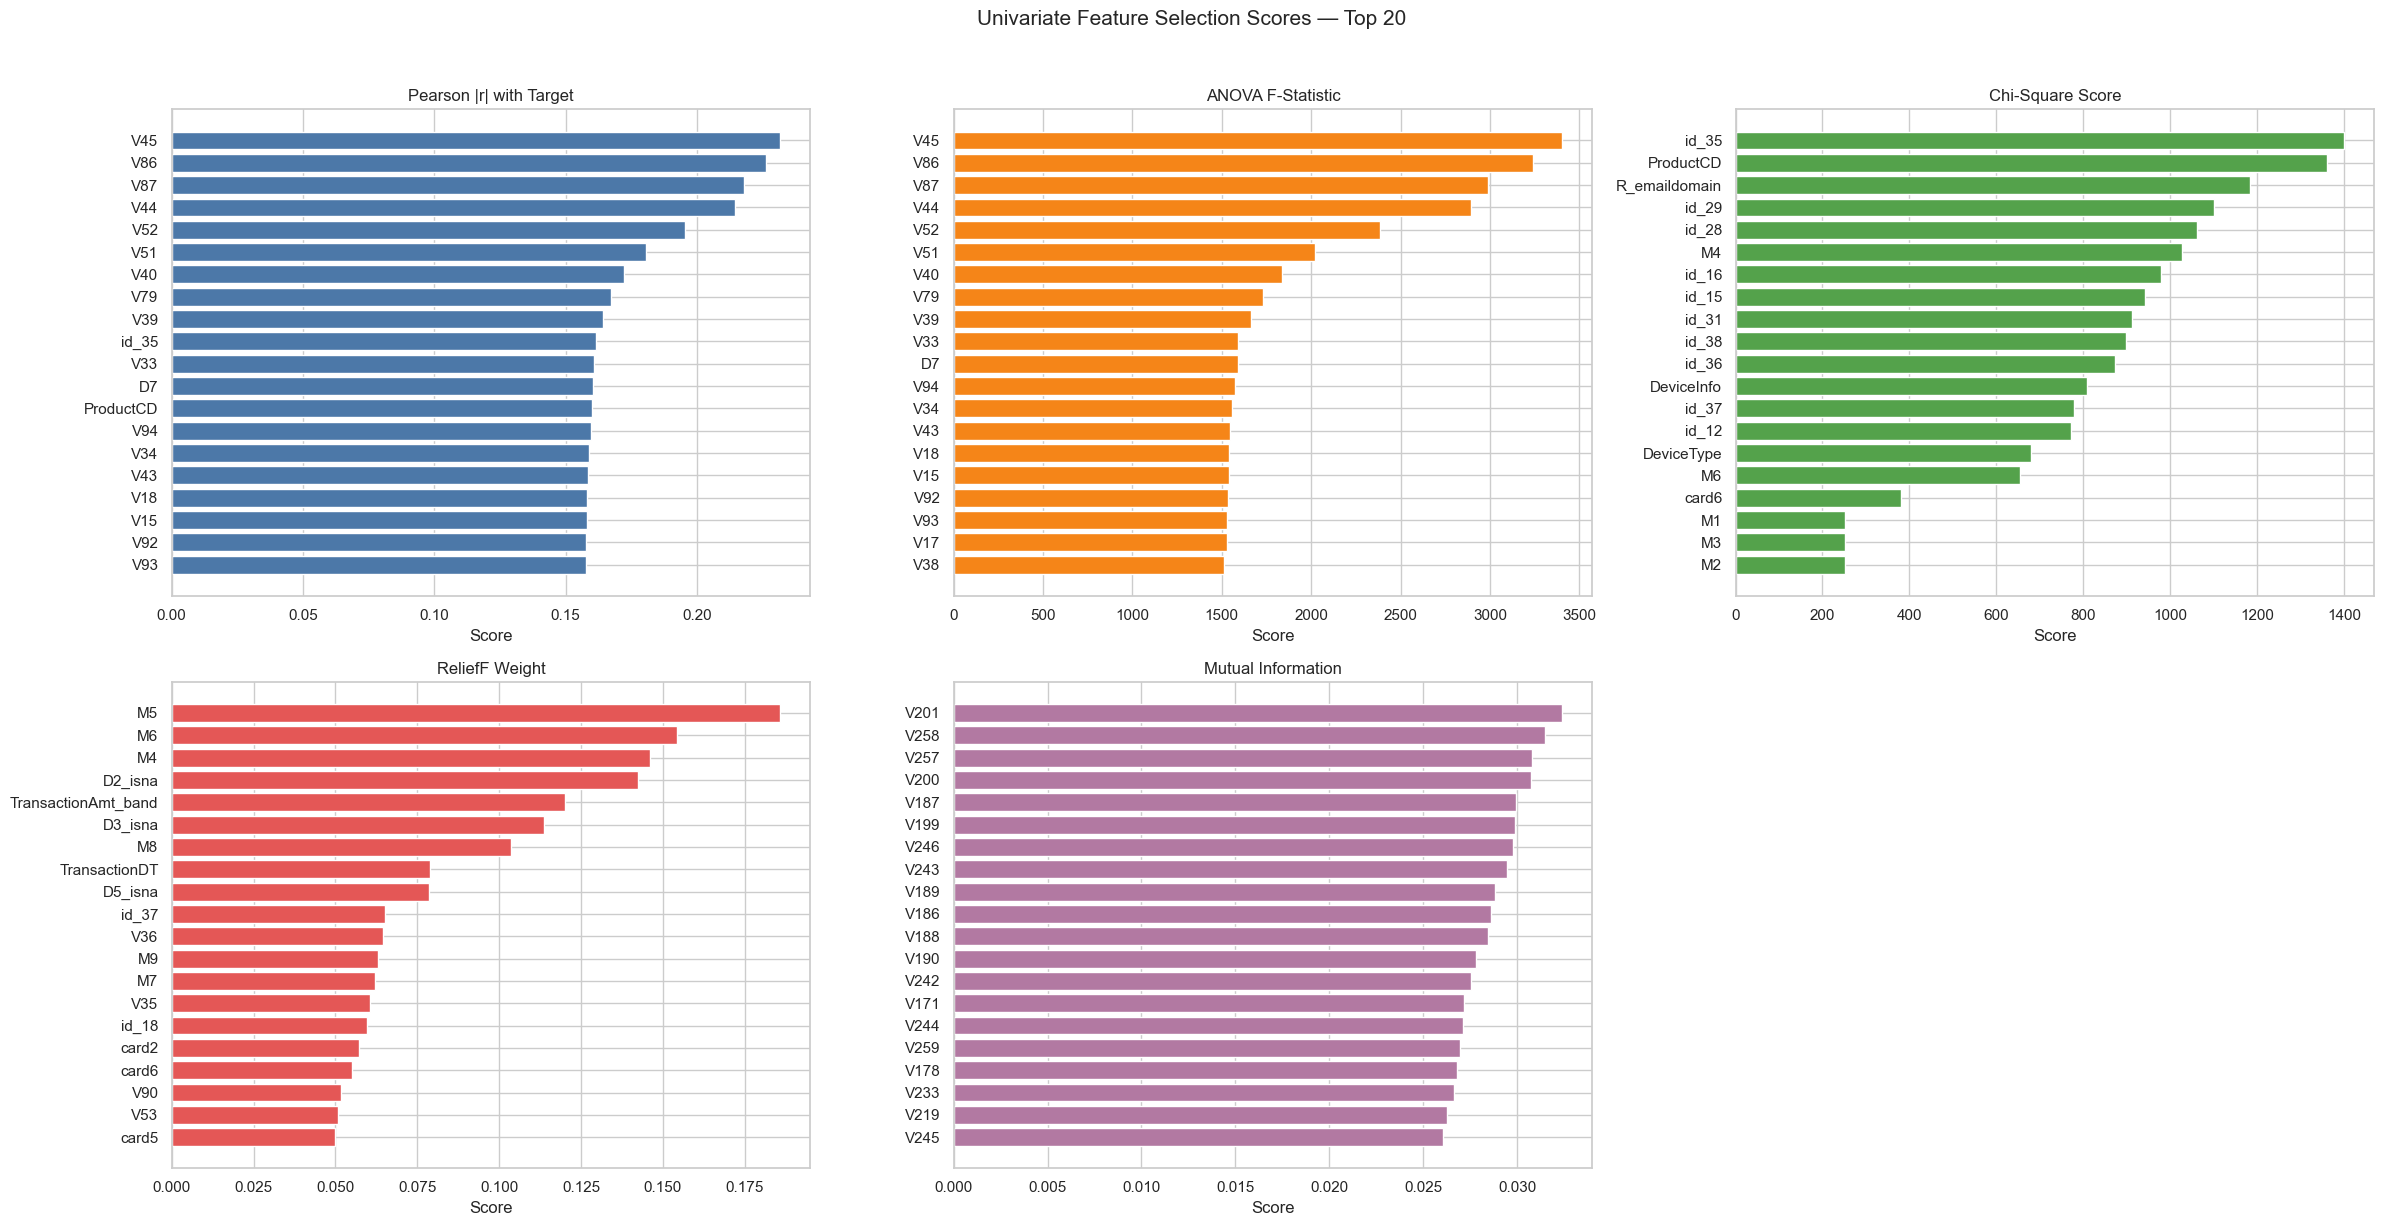

In [122]:
fig, axes = plt.subplots(2, 3, figsize=(24, 12))
colors = ['#4c78a8', '#f58518', '#54a24b', '#e45756', '#b279a2', '#9c755f']
for ax, (method, scores), color in zip(axes.ravel(), score_tables.items(), colors):
    top = scores.head(TOP_N)
    ax.barh(top.index[::-1], top.values[::-1], color=color)
    ax.set_title(method)
    ax.set_xlabel('Score')
fig.delaxes(axes[1, 2])
plt.suptitle(f'Univariate Feature Selection Scores — Top {TOP_N}', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


## Univariate Model Performance (top-k per method)

Each row uses the **top 25 features from that scoring method**, evaluated with Random Forest and a recall-first threshold tuned on validation. The overlap top-25 (`selected_25_features`) is an optional extra row, not a substitute for per-method tops.


,source,N Feats,Recall,F2,AUC_PR,Precision,Specificity,Threshold,policy_status
0,Baseline RF (540),541,0.857143,0.330457,0.460723,0.095567,0.705786,0.29,Best recall with accuracy >= 0.70
4,ReliefF Weight,25,0.780952,0.301526,0.234535,0.087257,0.703713,0.36,Best recall with accuracy >= 0.70
3,Chi-Square Score,25,0.738095,0.302321,0.175285,0.089933,0.729102,0.43,Best recall with accuracy >= 0.70
6,Overlap top-25,25,0.716667,0.286013,0.240171,0.084031,0.716667,0.45,Best recall with accuracy >= 0.70
1,Pearson |r| with Target,25,0.642857,0.252999,0.207863,0.073851,0.707599,0.38,Best recall with accuracy >= 0.70
5,Mutual Information,25,0.521429,0.244365,0.284955,0.078186,0.777029,0.40,Best recall with accuracy >= 0.70
2,ANOVA F-Statistic,25,0.478571,0.264474,0.218652,0.094811,0.834283,0.39,Best recall with accuracy >= 0.70


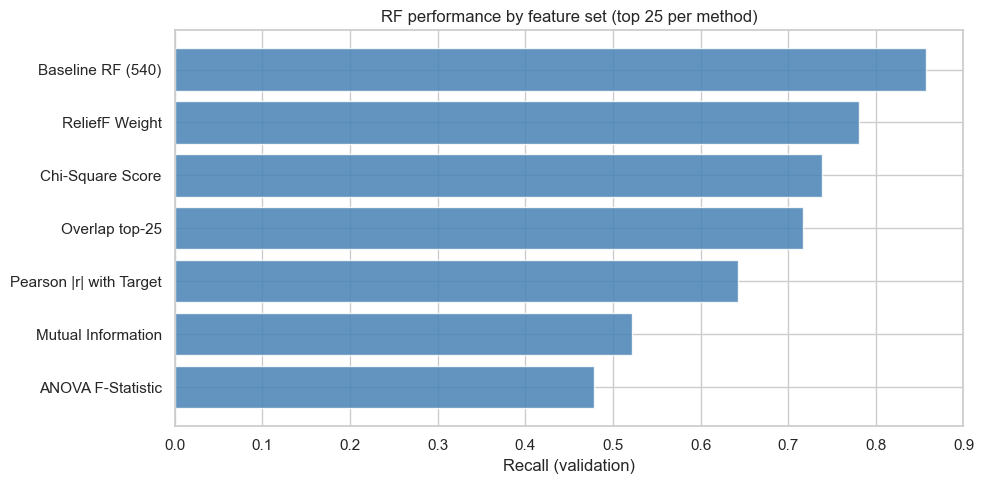

In [123]:
performance_rows = []
for method, scores in score_tables.items():
    feats = scores.head(QUICK_COMPARE_K).index.tolist()
    _, best = fit_rf_tune_val(feats, f'{method} (top {QUICK_COMPARE_K})')
    performance_rows.append(to_metrics_row(best, source=method, n_feats=len(feats)))

_, overlap_best = fit_rf_tune_val(selected_25_features, 'Overlap top-25 (5 methods)')
performance_rows.append(to_metrics_row(overlap_best, 'Overlap top-25', len(selected_25_features)))

performance_rows.insert(0, to_metrics_row(baseline_rf_tuned, 'Baseline RF (540)', len(feature_cols)))
performance_table = pd.DataFrame(performance_rows)

display_cols = ['source', 'N Feats', 'Recall', 'F2', 'AUC_PR', 'Precision', 'Specificity', 'Threshold', 'policy_status']
display_cols = [c for c in display_cols if c in performance_table.columns]
display(performance_table[display_cols].sort_values('Recall', ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = performance_table.sort_values('Recall', ascending=True)
ax.barh(plot_df['source'], plot_df['Recall'], color='steelblue', alpha=0.85)
ax.set_xlabel('Recall (validation)')
ax.set_title(f'RF performance by feature set (top {QUICK_COMPARE_K} per method)')
plt.tight_layout()
plt.show()

## Univariate Top-k Sweep (Parkinson's-style)

Each univariate method selects top **k** features (`K_GRID = [10, 20, 30, 50]`). A **Random Forest** is fit on `X_fit` and the decision threshold is tuned on **`X_val`** under the recall-first policy. This justifies a compact subset (10–50) with validation metrics, not only static scores.


Running univariate k-sweep (5 methods x 4 k values)...


,method,k,n_features,Threshold,Accuracy,Precision,Recall,F1,F2,AUC,AUC_PR,Specificity,policy_status
15,ReliefF Weight,50,50,0.33,0.7002,0.0890,0.8190,0.1605,0.3101,0.8487,0.3030,0.6959,Best recall with accuracy >= 0.70
14,ReliefF Weight,30,30,0.34,0.7051,0.0893,0.8071,0.1608,0.3095,0.8321,0.2412,0.7014,Best recall with accuracy >= 0.70
11,Chi-Square Score,50,33,0.42,0.7038,0.0865,0.7810,0.1558,0.2998,0.8125,0.1852,0.7010,Best recall with accuracy >= 0.70
10,Chi-Square Score,30,30,0.43,0.7176,0.0882,0.7571,0.1580,0.3009,0.8117,0.1873,0.7161,Best recall with accuracy >= 0.70
13,ReliefF Weight,20,20,0.37,0.7043,0.0838,0.7500,0.1508,0.2896,0.8183,0.2401,0.7027,Best recall with accuracy >= 0.70
9,Chi-Square Score,20,20,0.45,0.7398,0.0908,0.7143,0.1612,0.3010,0.7909,0.1770,0.7407,Best recall with accuracy >= 0.70
12,ReliefF Weight,10,10,0.44,0.7077,0.0804,0.7048,0.1444,0.2761,0.7837,0.1876,0.7078,Best recall with accuracy >= 0.70
3,Pearson |r| with Target,50,50,0.34,0.7056,0.0751,0.6548,0.1347,0.2573,0.7363,0.2570,0.7074,Best recall with accuracy >= 0.70
2,Pearson |r| with Target,30,30,0.36,0.7032,0.0738,0.6476,0.1325,0.2535,0.7121,0.2270,0.7053,Best recall with accuracy >= 0.70
7,ANOVA F-Statistic,50,50,0.35,0.7058,0.0740,0.6429,0.1326,0.2532,0.7262,0.2437,0.7080,Best recall with accuracy >= 0.70


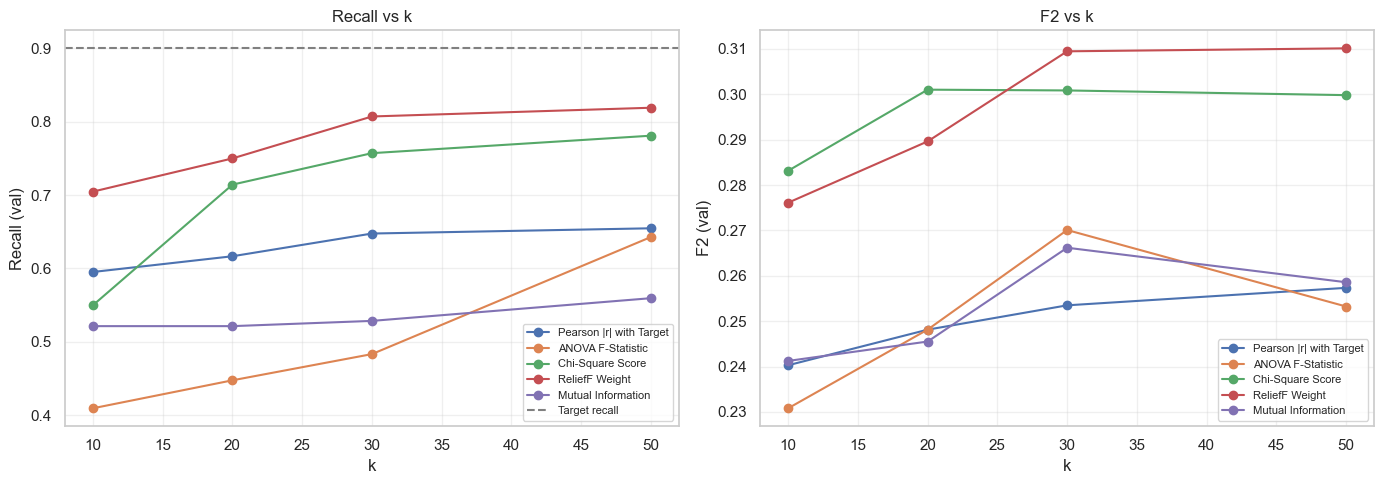

Best univariate: ReliefF Weight with k=50
Val Recall=0.819, F2=0.310, policy: Best recall with accuracy >= 0.70


,rank,feature,in_A1_top30,also_ranked_by,justification
0,1,M5,No,"Chi-Square Score, ReliefF Weight",Rank 1 for ReliefF Weight; A1 anchor=No; V/ema...
1,2,M6,No,"Chi-Square Score, ReliefF Weight",Rank 2 for ReliefF Weight; A1 anchor=No; V/ema...
2,3,M4,No,"Chi-Square Score, ReliefF Weight",Rank 3 for ReliefF Weight; A1 anchor=No; V/ema...
3,4,D2_isna,No,ReliefF Weight,Rank 4 for ReliefF Weight; A1 anchor=No; V/ema...
4,5,TransactionAmt_band,No,"Chi-Square Score, ReliefF Weight",Rank 5 for ReliefF Weight; A1 anchor=No; V/ema...
5,6,D3_isna,No,ReliefF Weight,Rank 6 for ReliefF Weight; A1 anchor=No; V/ema...
6,7,M8,No,"Chi-Square Score, ReliefF Weight",Rank 7 for ReliefF Weight; A1 anchor=No; V/ema...
7,8,TransactionDT,No,ReliefF Weight,Rank 8 for ReliefF Weight; A1 anchor=No; V/ema...
8,9,D5_isna,No,ReliefF Weight,Rank 9 for ReliefF Weight; A1 anchor=No; V/ema...
9,10,id_37,No,"Chi-Square Score, ReliefF Weight",Rank 10 for ReliefF Weight; A1 anchor=No; V/em...


In [124]:
print('Running univariate k-sweep (5 methods x 4 k values)...')
univariate_k_sweep_results = run_univariate_k_sweep()
display(univariate_k_sweep_results.sort_values(['Recall', 'F2'], ascending=False).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for method in score_tables:
    sub = univariate_k_sweep_results[univariate_k_sweep_results['method'] == method]
    axes[0].plot(sub['k'], sub['Recall'], marker='o', label=method)
    axes[1].plot(sub['k'], sub['F2'], marker='o', label=method)
axes[0].axhline(TARGET_RECALL, color='gray', linestyle='--', label='Target recall')
axes[0].set(xlabel='k', ylabel='Recall (val)', title='Recall vs k')
axes[1].set(xlabel='k', ylabel='F2 (val)', title='F2 vs k')
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_univariate_row, best_univariate_features = pick_univariate_winner(univariate_k_sweep_results)
print(f'Best univariate: {best_univariate_row["method"]} with k={int(best_univariate_row["k"])}')
print(f'Val Recall={best_univariate_row["Recall"]:.3f}, F2={best_univariate_row["F2"]:.3f}, policy: {best_univariate_row["policy_status"]}')

univariate_winner_justification = []
for rank, feat in enumerate(best_univariate_features, start=1):
    in_a1 = 'Yes' if feat in A1_TOP_FEATURES else 'No'
    groups = [m for m, s in score_tables.items() if feat in s.head(50).index]
    univariate_winner_justification.append({
        'rank': rank, 'feature': feat, 'in_A1_top30': in_a1,
        'also_ranked_by': ', '.join(groups),
        'justification': f'Rank {rank} for {best_univariate_row["method"]}; A1 anchor={in_a1}; V/email/card if categorical.',
    })
display(pd.DataFrame(univariate_winner_justification))


### ReliefF vs univariate winner (read before merged)

- **ReliefF** scores **all** features in `score_tables['ReliefF Weight']` (mixed numeric + encoded categoricals).
- **Univariate winner** = top **k** features from the **single best method** after the k-sweep (often ReliefF with k=50).
- **Merged** (built later) = union of top-50 from **each** of the five methods — dominated by V-features from Pearson/ANOVA/Chi², not the full ReliefF winner list.


In [125]:
relieff_top50 = set(score_tables['ReliefF Weight'].head(50).index)
winner_set = set(best_univariate_features)
print(f'ReliefF top-50 vs winner (k={len(winner_set)}): identical={relieff_top50 == winner_set}')
print(f'In winner but not ReliefF top-50: {sorted(winner_set - relieff_top50)[:15]}')
print('Full overlap with Merged / CFS / DISR is computed after the merged cell below.')


ReliefF top-50 vs winner (k=50): identical=True
In winner but not ReliefF top-50: []
Full overlap with Merged / CFS / DISR is computed after the merged cell below.


### Univariate conclusion

**A1 alignment:** V-block features (e.g. V45, V86) dominate Pearson, ANOVA, ReliefF, and MI ranks, matching A1 EDA. Chi-square and MI also elevate **ProductCD**, **email domains**, and **DeviceType**, which A1 flagged via category fraud-rate tests — complementary signals, not contradictions.

**Winner:** The table above names the best univariate filter and **k** under validation recall-first rules. That subset is the primary interpretable deliverable (10–50 original column names).

**Note:** CFS/CON/DISR are multivariate and are compared next; they are not substitutes for this univariate section.


## Multivariate Feature Selection (15 marks)

CFS, CON, and DISR from Zouhri et al. (2023). Candidate pools use the union of top-50 features from each **five** univariate filters.


### Multivariate filters — variable types & inputs (CFS, CON, DISR)

All three use a **candidate pool** from top-50 univariate features per method (train only). Runnable table in the next cell; results updated after CON/DISR below.

| Method | Numeric | Categorical | Discretization |
|---|---|---|---|
| CFS | Yes | Yes (mixed matrix) | No |
| CON | Yes | Yes | Yes (~5 bins) |
| DISR | Yes | Yes | Yes (~6 bins) |


In [126]:
multivariate_method_types = pd.DataFrame([
    {
        'method': 'CFS (Correlation-based Feature Selection)',
        'input_data': 'X_train_cfs (mixed numeric + label-encoded categoricals)',
        'numeric': 'Yes',
        'categorical': 'Yes (encoded in mixed matrix)',
        'needs_discretization': 'No',
        'selection_rule': 'Greedy merit: high |r(feature,fraud)|, low redundancy between features',
        'typical_output_size': f'up to {CFS_MAX_FEATURES} features',
    },
    {
        'method': 'CON (Consistency-Based)',
        'input_data': 'X_train original columns (discretized per feature)',
        'numeric': 'Yes (binned to ~5 bins)',
        'categorical': 'Yes (string levels)',
        'needs_discretization': 'Yes (qcut / string)',
        'selection_rule': 'Add features until inconsistency rate <= tau or max features',
        'typical_output_size': 'Often very small (e.g. 1–5)',
    },
    {
        'method': 'DISR (Double Input Symmetrical Relevance)',
        'input_data': 'X_train original columns (discretized)',
        'numeric': 'Yes (binned)',
        'categorical': 'Yes (string levels)',
        'needs_discretization': 'Yes',
        'selection_rule': 'Maximize MI with fraud minus mean redundancy with selected set',
        'typical_output_size': 'up to 10 features',
    },
])
display(multivariate_method_types)
multivariate_method_types.to_csv('a2_multivariate_method_variable_types.csv', index=False)
print('Saved a2_multivariate_method_variable_types.csv')


,method,input_data,numeric,categorical,needs_discretization,selection_rule,typical_output_size
0,CFS (Correlation-based Feature Selection),X_train_cfs (mixed numeric + label-encoded cat...,Yes,Yes (encoded in mixed matrix),No,"Greedy merit: high |r(feature,fraud)|, low red...",up to 20 features
1,CON (Consistency-Based),X_train original columns (discretized per feat...,Yes (binned to ~5 bins),Yes (string levels),Yes (qcut / string),Add features until inconsistency rate <= tau o...,Often very small (e.g. 1–5)
2,DISR (Double Input Symmetrical Relevance),X_train original columns (discretized),Yes (binned),Yes (string levels),Yes,Maximize MI with fraud minus mean redundancy w...,up to 10 features


Saved a2_multivariate_method_variable_types.csv


## CFS After Univariate Selection

CFS picks a small set of features that work well **together**, not only by single-feature score. It rewards features that relate to fraud. It penalizes features that are too similar to each other. We start from top univariate candidates on train, then add features one step at a time until the score stops improving.


In [127]:
# CFS = Correlation-based Feature Selection (multivariate filter from the paper).


def cfs_merit(selected_features, X_df, y_series):
    """One number: how good is this feature set? Higher = better."""
    k = len(selected_features)
    if k == 0:
        return 0.0
    # r_cf: average link between each feature and fraud (want this high).
    r_cf = np.mean([abs(X_df[f].corr(y_series)) for f in selected_features])
    if k == 1:
        return float(r_cf)
    # r_ff: average correlation between features in the set (want this low).
    r_ff = [abs(X_df[selected_features[i]].corr(X_df[selected_features[j]]))
            for i in range(k) for j in range(i + 1, k)]
    r_ff_mean = np.nanmean(r_ff) if r_ff else 0.0
    denominator = np.sqrt(k + k * (k - 1) * r_ff_mean)
    return float(k * r_cf / denominator) if denominator else 0.0


def greedy_cfs(X_df, y_series, candidate_features, max_features=20):
    """Add one feature at a time; stop when merit does not go up."""
    selected, remaining, current_merit, history = [], list(dict.fromkeys(candidate_features)), 0.0, []
    while remaining and len(selected) < max_features:
        # Try every remaining feature; pick the one that gives the best merit.
        trials = [(f, cfs_merit(selected + [f], X_df, y_series)) for f in remaining]
        best_feature, best_merit = max(trials, key=lambda x: x[1])
        if best_merit <= current_merit:
            break  # no improvement → stop
        selected.append(best_feature)
        remaining.remove(best_feature)
        current_merit = best_merit
        history.append({'step': len(selected), 'feature_added': best_feature, 'cfs_merit': best_merit})
    return selected, pd.DataFrame(history)


# Candidate pool: top-50 from each univariate method (train only, no test).
cfs_pool = []
for scores in score_tables.values():
    cfs_pool.extend(scores.head(MERGED_TOP_PER_METHOD).index.tolist())
cfs_pool = list(dict.fromkeys(cfs_pool))[:CFS_POOL_SIZE]
cfs_pool = [f for f in cfs_pool if f in X_train_cfs.columns]

# Run greedy CFS on train; then tune RF + threshold on val (same as other methods).
cfs_features, cfs_history = greedy_cfs(X_train_cfs, y_train, cfs_pool, max_features=CFS_MAX_FEATURES)
print(f'CFS selected {len(cfs_features)} features:')
print(cfs_features)
display(cfs_history)

_, cfs_best = fit_rf_tune_val(cfs_features, 'CFS')
cfs_best['source'] = 'CFS'
display(pd.DataFrame([cfs_best]).round(4))


CFS selected 4 features:
['V45', 'V52', 'V86', 'id_10']


,step,feature_added,cfs_merit
0,1,V45,0.231615
1,2,V52,0.264970
2,3,V86,0.287481
3,4,id_10,0.297010


,Model,N Feats,Accuracy,Precision,Recall,F1,F2,AUC,AUC_PR,Specificity,TN,FP,FN,TP,Threshold,policy_status,source
36,CFS,4,0.7628,0.0779,0.5333,0.136,0.2459,0.6765,0.1944,0.7711,8929,2651,196,224,0.37,Best recall with accuracy >= 0.70,CFS


### Selection vs Baseline (after CFS)

Multi-model baseline (540 features, threshold 0.5 on val) is exploratory. Fair comparison uses **RF + val-tuned threshold** (`baseline_rf_tuned` vs `cfs_best`).


In [128]:
compare_after_cfs = pd.DataFrame([
    to_metrics_row(baseline_rf_tuned, 'Baseline RF (540)', len(feature_cols)),
    to_metrics_row(cfs_best, 'CFS', len(cfs_features)),
])
display(compare_after_cfs[['source', 'N Feats', 'Recall', 'F2', 'AUC_PR']])
delta_recall = cfs_best['Recall'] - baseline_rf_tuned['Recall']
print(f'CFS: {len(cfs_features)} features (from 540). Recall delta vs tuned baseline: {delta_recall:+.4f}')


,source,N Feats,Recall,F2,AUC_PR
0,Baseline RF (540),541,0.857143,0.330457,0.460723
1,CFS,4,0.533333,0.245884,0.194386


CFS: 4 features (from 540). Recall delta vs tuned baseline: -0.3238


## A1 vs My CFS Comparison

A1 already found strong fraud signals using EDA and Pearson-style target correlation, especially in the V-feature blocks. Here I compare those A1-style top Pearson features against the CFS-selected subset immediately after CFS. The full multivariate comparison with the merged set, CON, and DISR comes later after those methods are created.

In [129]:
a1_pearson_features = score_tables['Pearson |r| with Target'].head(TOP_MODEL_FEATURES).index.tolist()
a1_set, cfs_set = set(a1_pearson_features), set(cfs_features)
display(pd.DataFrame({
    'comparison': ['A1 Pearson top', 'CFS selected', 'Overlap'],
    'n_features': [len(a1_set), len(cfs_set), len(a1_set & cfs_set)],
    'features': [sorted(a1_set), sorted(cfs_set), sorted(a1_set & cfs_set)],
}))


,comparison,n_features,features
0,A1 Pearson top,10,"[V39, V40, V44, V45, V51, V52, V79, V86, V87, ..."
1,CFS selected,4,"[V45, V52, V86, id_10]"
2,Overlap,3,"[V45, V52, V86]"


CFS RF + validation threshold tuning runs in the **CFS code cell above** (duplicate evaluation cell was removed).


### Combined Unique Feature Set

CFS is intentionally compact, so it may drop useful fraud-recall signals. To avoid over-simplifying, this section merges **all unique** features from A1 Pearson-style ranking, CFS, and the top features from every univariate method. This gives a larger recall-oriented comparison set that preserves more of the original 540-feature signal without going fully back to all predictors.

### Merged union + optional correlation prune (|r| > 0.82)

Pruning runs **only inside** `merged_unique_features` on `X_fit`, keeping the feature with stronger fraud association (and univariate scores as tie-break). `_*_isna` shadow columns are excluded from pairwise pruning.


In [130]:
a1_pearson_features_wide = score_tables['Pearson |r| with Target'].head(MERGED_TOP_PER_METHOD).index.tolist()
merged_unique_features = list(dict.fromkeys(
    a1_pearson_features_wide + cfs_features + [f for s in score_tables.values() for f in s.head(MERGED_TOP_PER_METHOD).index]
))
merged_unique_features = [f for f in merged_unique_features if f in feature_cols][:MERGED_MAX_FEATURES]
print(f'Merged unique feature count: {len(merged_unique_features)}')

score_lookup = {}
for _method in ['ANOVA F-Statistic', 'ReliefF Weight', 'Pearson |r| with Target']:
    if _method in score_tables:
        for _feat, _sc in score_tables[_method].items():
            score_lookup[_feat] = max(score_lookup.get(_feat, 0), float(_sc))

merged_pruned_features = prune_correlated_features(
    merged_unique_features, X_fit, y_fit,
    threshold=CORR_PRUNE_THRESHOLD, score_lookup=score_lookup,
)
_dropped = sorted(set(merged_unique_features) - set(merged_pruned_features))
print(f'Merged pruned: {len(merged_unique_features)} -> {len(merged_pruned_features)} (dropped {len(_dropped)})')
if _dropped:
    print('Dropped features:', _dropped[:20], '...' if len(_dropped) > 20 else '')

_, merged_best = fit_rf_tune_val(merged_unique_features, 'Merged unique')
merged_best['source'] = 'Merged'
_, merged_pruned_best = fit_rf_tune_val(merged_pruned_features, 'Merged pruned (r<0.82)')
merged_pruned_best['source'] = 'Merged pruned'

compare_merged = pd.DataFrame([
    to_metrics_row(merged_best, 'Merged', len(merged_unique_features)),
    to_metrics_row(merged_pruned_best, 'Merged pruned', len(merged_pruned_features)),
])
display(compare_merged[['source', 'N Feats', 'Recall', 'F2', 'AUC_PR']].round(4))
display(pd.DataFrame([merged_best]).round(4))


Merged unique feature count: 160
Merged pruned: 160 -> 68 (dropped 92)
Dropped features: ['D12', 'D2', 'D6', 'D8', 'D9', 'V13', 'V15', 'V16', 'V167', 'V168', 'V17', 'V170', 'V171', 'V176', 'V177', 'V178', 'V179', 'V186', 'V187', 'V188'] ...


,source,N Feats,Recall,F2,AUC_PR
0,Merged,160,0.8357,0.3198,0.3824
1,Merged pruned,68,0.8381,0.3215,0.3410


,Model,N Feats,Accuracy,Precision,Recall,F1,F2,AUC,AUC_PR,Specificity,TN,FP,FN,TP,Threshold,policy_status,source
33,Merged unique,160,0.7062,0.0922,0.8357,0.1661,0.3198,0.8655,0.3824,0.7016,8124,3456,69,351,0.34,Best recall with accuracy >= 0.70,Merged


## Consistency-Based Feature Subset Selection (CON)

CON is a multivariate filter that selects a small subset with low class-label ambiguity. Rows are grouped by the selected feature values after discretization. The inconsistency rate is:

`sum(group_size - majority_class_count) / N`

A lower rate means fewer groups contain both legitimate and fraud labels. The implementation adds features from the univariate pool until the inconsistency rate is below `tau = 0.05` or the maximum subset size is reached.

In [131]:
def discretize_for_consistency(series, bins=5):
    if pd.api.types.is_numeric_dtype(series):
        if series.nunique(dropna=False) <= bins:
            return series.fillna(-999).astype(str)
        return pd.qcut(series.rank(method='first'), q=bins, duplicates='drop').astype(str)
    return series.astype(str).fillna('Missing')


def inconsistency_rate(X_subset, y_series):
    grouped = pd.concat([X_subset.reset_index(drop=True), y_series.reset_index(drop=True).rename(target_col)], axis=1)
    total_inconsistent = 0
    for _, group in grouped.groupby(list(X_subset.columns), dropna=False):
        counts = group[target_col].value_counts()
        total_inconsistent += len(group) - counts.max()
    return total_inconsistent / len(grouped)


def run_con(candidate_features, tau=0.05, max_features=20):
    selected, history, X_disc_all = [], [], pd.DataFrame(index=X_train.index)
    for feature in candidate_features:
        if feature in X_train.columns:
            X_disc_all[feature] = discretize_for_consistency(X_train[feature])
    for feature in candidate_features:
        if feature not in X_disc_all.columns or feature in selected:
            continue
        selected.append(feature)
        rate = inconsistency_rate(X_disc_all[selected], y_train)
        history.append({'step': len(selected), 'feature_added': feature, 'inconsistency_rate': rate})
        if rate <= tau or len(selected) >= max_features:
            break
    return selected, pd.DataFrame(history)


con_candidates = list(dict.fromkeys(cfs_pool + merged_unique_features[:80]))
con_features, con_history = run_con(con_candidates, tau=0.05, max_features=20)
print(f'CON selected {len(con_features)} features:', con_features)
display(con_history.round(4))
_, con_best = fit_rf_tune_val(con_features, 'CON')
con_best['source'] = 'CON'
display(pd.DataFrame([con_best]).round(4))


CON selected 1 features: ['V45']


,step,feature_added,inconsistency_rate
0,1,V45,0.035


,Model,N Feats,Accuracy,Precision,Recall,F1,F2,AUC,AUC_PR,Specificity,TN,FP,FN,TP,Threshold,policy_status,source
44,CON,1,0.9252,0.1411,0.2238,0.1731,0.2003,0.5904,0.1288,0.9506,11008,572,326,94,0.45,Best recall with accuracy >= 0.70,CON


## Double Input Symmetrical Relevance (DISR)

DISR is an information-theoretic multivariate filter. This notebook uses a practical approximation: features are discretized, the first feature is anchored by mutual information with the target, and each next feature is selected by combining target relevance with low redundancy against already-selected features.

In [132]:
def discretize_for_mi(series, bins=6):
    if pd.api.types.is_numeric_dtype(series):
        if series.nunique(dropna=False) <= bins:
            return series.fillna(-999).astype(str)
        return pd.qcut(series.rank(method='first'), q=bins, duplicates='drop').astype(str)
    return series.astype(str).fillna('Missing')


def run_disr(candidate_features, max_features=10):
    X_disc = pd.DataFrame({f: discretize_for_mi(X_train[f]) for f in candidate_features if f in X_train.columns})
    mi_target = pd.Series({f: mutual_info_score(X_disc[f], y_train) for f in X_disc.columns}).sort_values(ascending=False)
    selected = [mi_target.index[0]] if len(mi_target) else []
    history = []
    while len(selected) < max_features and len(selected) < len(mi_target):
        scored = []
        for candidate in [f for f in mi_target.index if f not in selected]:
            redundancy = np.mean([mutual_info_score(X_disc[candidate], X_disc[s]) for s in selected]) if selected else 0
            scored.append((candidate, mi_target[candidate] / (1 + redundancy)))
        best_feature, best_score = max(scored, key=lambda x: x[1])
        selected.append(best_feature)
        history.append({'feature_selected': best_feature, 'disr_score': best_score})
    return selected, pd.DataFrame(history)


disr_features, disr_history = run_disr(con_candidates, max_features=10)
print(f'DISR selected {len(disr_features)} features:', disr_features)
display(disr_history.round(4))
_, disr_best = fit_rf_tune_val(disr_features, 'DISR')
disr_best['source'] = 'DISR'
display(pd.DataFrame([disr_best]).round(4))


DISR selected 10 features: ['R_emaildomain', 'V51', 'id_35', 'V33', 'ProductCD', 'V94', 'id_31', 'addr1_isna', 'id_29', 'V15']


,feature_selected,disr_score
0,V51,0.0083
1,id_35,0.0075
2,V33,0.0071
3,ProductCD,0.0072
4,V94,0.0069
5,id_31,0.0070
6,addr1_isna,0.0068
7,id_29,0.0068
8,V15,0.0068


,Model,N Feats,Accuracy,Precision,Recall,F1,F2,AUC,AUC_PR,Specificity,TN,FP,FN,TP,Threshold,policy_status,source
40,DISR,10,0.7907,0.0927,0.5667,0.1594,0.2802,0.7086,0.1353,0.7989,9251,2329,182,238,0.41,Best recall with accuracy >= 0.70,DISR


In [133]:
# Append validation outcomes to multivariate method cards
multivariate_method_results = multivariate_method_types.copy()
outcomes = {
    'CFS (Correlation-based Feature Selection)': (len(cfs_features), cfs_best['Recall']),
    'CON (Consistency-Based)': (len(con_features), con_best['Recall']),
    'DISR (Double Input Symmetrical Relevance)': (len(disr_features), disr_best['Recall']),
}
multivariate_method_results['n_selected'] = multivariate_method_results['method'].map(
    lambda m: outcomes.get(m, (None, None))[0]
)
multivariate_method_results['val_recall'] = multivariate_method_results['method'].map(
    lambda m: outcomes.get(m, (None, None))[1]
)
display(multivariate_method_results.round(4))
multivariate_method_results.to_csv('a2_multivariate_method_results.csv', index=False)
print('Saved a2_multivariate_method_results.csv')


,method,input_data,numeric,categorical,needs_discretization,selection_rule,typical_output_size,n_selected,val_recall
0,CFS (Correlation-based Feature Selection),X_train_cfs (mixed numeric + label-encoded cat...,Yes,Yes (encoded in mixed matrix),No,"Greedy merit: high |r(feature,fraud)|, low red...",up to 20 features,4,0.5333
1,CON (Consistency-Based),X_train original columns (discretized per feat...,Yes (binned to ~5 bins),Yes (string levels),Yes (qcut / string),Add features until inconsistency rate <= tau o...,Often very small (e.g. 1–5),1,0.2238
2,DISR (Double Input Symmetrical Relevance),X_train original columns (discretized),Yes (binned),Yes (string levels),Yes,Maximize MI with fraud minus mean redundancy w...,up to 10 features,10,0.5667


Saved a2_multivariate_method_results.csv


## Final selection overlap (winner vs CFS / CON / DISR / Merged)

Membership heatmap: which features appear in each final subset. Winner (ReliefF k-sweep) often differs from merged because merged unions **top-50 per filter method**.


,feature,Winner,CFS,CON,DISR,Merged,Merged pruned,n_sets
98,V45,False,True,True,False,True,True,4
0,D1,True,False,False,False,True,True,3
3,D15,True,False,False,False,True,True,3
2,D14,True,False,False,False,True,True,3
7,D5_isna,True,False,False,False,True,True,3
6,D3_isna,True,False,False,False,True,True,3
15,M2,True,False,False,False,True,True,3
5,D2_isna,True,False,False,False,True,True,3
12,DeviceInfo,True,False,False,False,True,True,3
22,M9,True,False,False,False,True,True,3


,set_a,set_b,intersection,jaccard
14,Merged,Merged pruned,68,0.425000
3,Winner,Merged,50,0.312500
4,Winner,Merged pruned,39,0.493671
12,DISR,Merged,10,0.062500
13,DISR,Merged pruned,6,0.083333
7,CFS,Merged,4,0.025000
8,CFS,Merged pruned,4,0.058824
5,CFS,CON,1,0.250000
10,CON,Merged,1,0.006250
11,CON,Merged pruned,1,0.014706


Winner only (not in merged): 0 — sample: []
Merged only (not in winner): 110 — sample: ['D12', 'D6', 'D7', 'D8', 'D9', 'M1', 'ProductCD', 'R_emaildomain', 'V15', 'V16', 'V167', 'V168']


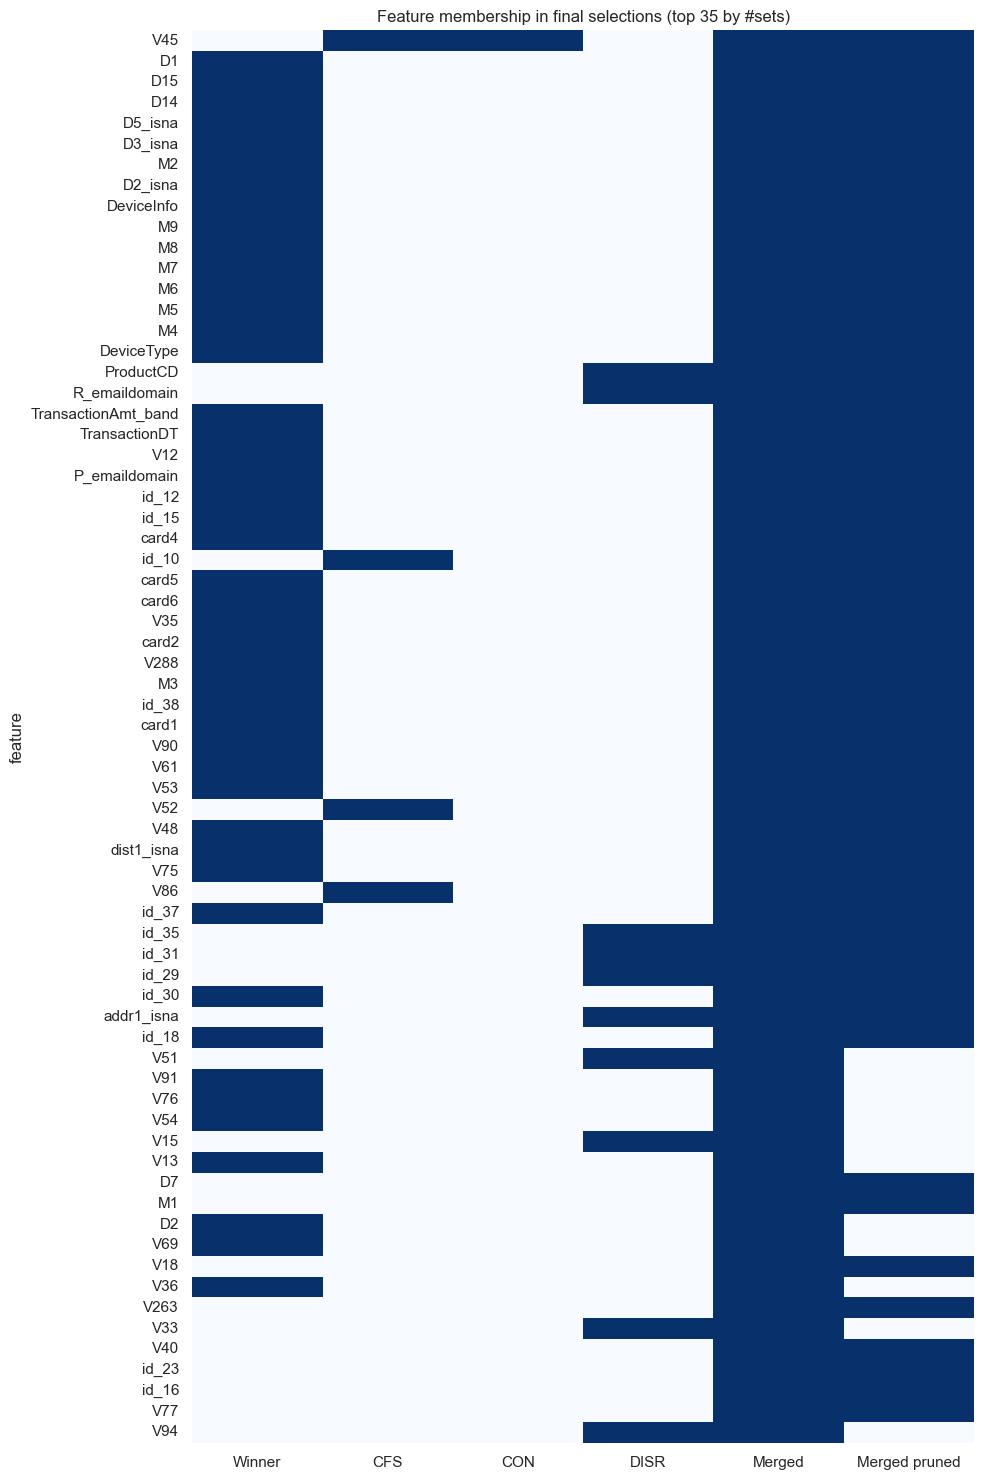

In [134]:
final_sets = {
    'Winner': list(best_univariate_features),
    'CFS': list(cfs_features),
    'CON': list(con_features),
    'DISR': list(disr_features),
    'Merged': list(merged_unique_features),
}
if 'merged_pruned_features' in dir():
    final_sets['Merged pruned'] = list(merged_pruned_features)

all_final = sorted(set().union(*final_sets.values()))
membership = pd.DataFrame({'feature': all_final})
for name, feats in final_sets.items():
    membership[name] = membership['feature'].isin(feats)
membership['n_sets'] = membership[list(final_sets.keys())].sum(axis=1)
membership = membership.sort_values('n_sets', ascending=False)
display(membership.head(40))

overlap_counts = []
labels = list(final_sets.keys())
for i, a in enumerate(labels):
    for b in labels[i + 1:]:
        sa, sb = set(final_sets[a]), set(final_sets[b])
        overlap_counts.append({
            'set_a': a, 'set_b': b,
            'intersection': len(sa & sb),
            'jaccard': len(sa & sb) / len(sa | sb) if len(sa | sb) else 0,
        })
display(pd.DataFrame(overlap_counts).sort_values('intersection', ascending=False))

winner_only = set(best_univariate_features) - set(merged_unique_features)
merged_only = set(merged_unique_features) - set(best_univariate_features)
print(f'Winner only (not in merged): {len(winner_only)} — sample: {sorted(winner_only)[:12]}')
print(f'Merged only (not in winner): {len(merged_only)} — sample: {sorted(merged_only)[:12]}')

fig, ax = plt.subplots(figsize=(10, max(6, 68 * 0.22)))
plot_m = membership.set_index('feature')[labels].astype(int)
# top 35 features by n_sets for readability
top_feat = membership.head(68)['feature'].tolist()
sns.heatmap(plot_m.loc[top_feat], cmap='Blues', cbar=False, ax=ax)
ax.set_title('Feature membership in final selections (top 35 by #sets)')
plt.tight_layout()
plt.show()


## Full Multivariate Feature Selection Comparison

After CFS, merged features, CON, and DISR have been created, this table compares all selected feature sets together. For this fraud dataset, the merged set is usually the most practical recall-first option because it keeps more A1 signal than the very compact multivariate selectors.

In [135]:
multivariate_comparison = pd.DataFrame([
    to_metrics_row(cfs_best, 'CFS', len(cfs_features)),
    to_metrics_row(con_best, 'CON', len(con_features)),
    to_metrics_row(disr_best, 'DISR', len(disr_features)),
    to_metrics_row(merged_best, 'Merged', len(merged_unique_features)),
    to_metrics_row(merged_pruned_best, 'Merged pruned', len(merged_pruned_features)),
    to_metrics_row(best_univariate_row, f'Univariate winner ({best_univariate_row["method"]})', int(best_univariate_row['k'])),
])
display_cols = ['source', 'N Feats', 'Recall', 'F2', 'AUC_PR', 'Precision', 'Specificity', 'Threshold', 'policy_status']
display_cols = [c for c in display_cols if c in multivariate_comparison.columns]
display(multivariate_comparison[display_cols].sort_values('Recall', ascending=False))

,source,N Feats,Recall,F2,AUC_PR,Precision,Specificity,Threshold,policy_status
4,Merged pruned,68,0.838095,0.321520,0.340957,0.092778,0.702763,0.34,Best recall with accuracy >= 0.70
3,Merged,160,0.835714,0.319847,0.382355,0.092199,0.701554,0.34,Best recall with accuracy >= 0.70
5,Univariate winner (ReliefF Weight),50,0.819048,0.310133,0.303040,0.088981,0.695855,0.33,Best recall with accuracy >= 0.70
2,DISR,10,0.566667,0.280198,0.135275,0.092715,0.798877,0.41,Best recall with accuracy >= 0.70
0,CFS,4,0.533333,0.245884,0.194386,0.077913,0.771071,0.37,Best recall with accuracy >= 0.70
1,CON,1,0.223810,0.200341,0.128757,0.141141,0.950604,0.45,Best recall with accuracy >= 0.70


## PCA Dimensionality Reduction (15 marks)

PCA builds **orthogonal linear components** from the mixed encoded matrix. Unlike CFS or ReliefF, it does not return a subset of original Vesta column names — interpretability is traded for compactness.


Components for 95% variance: 85


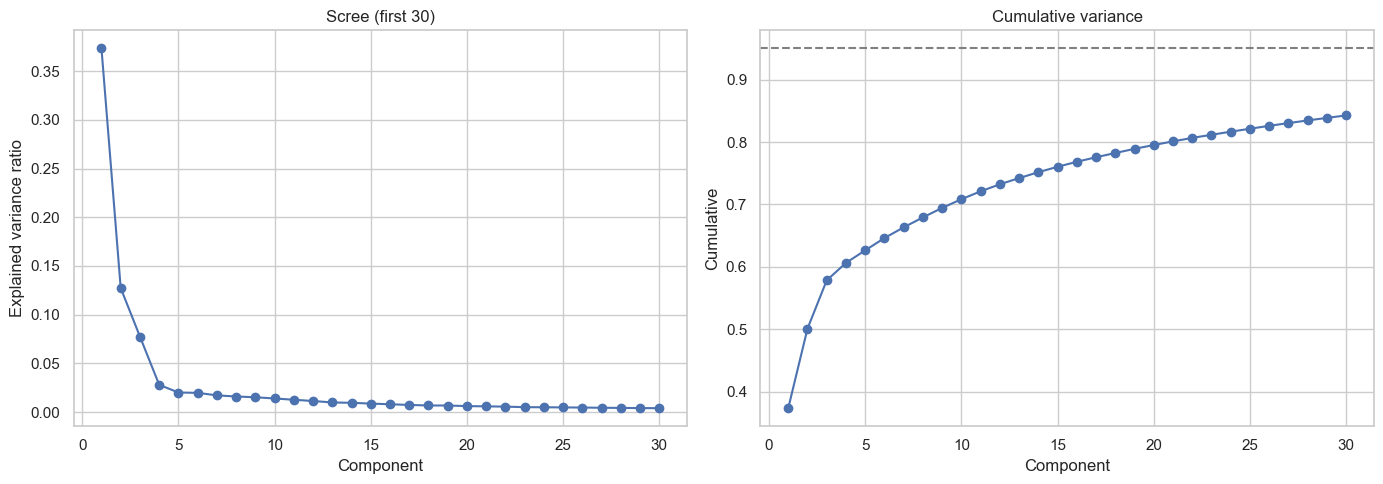

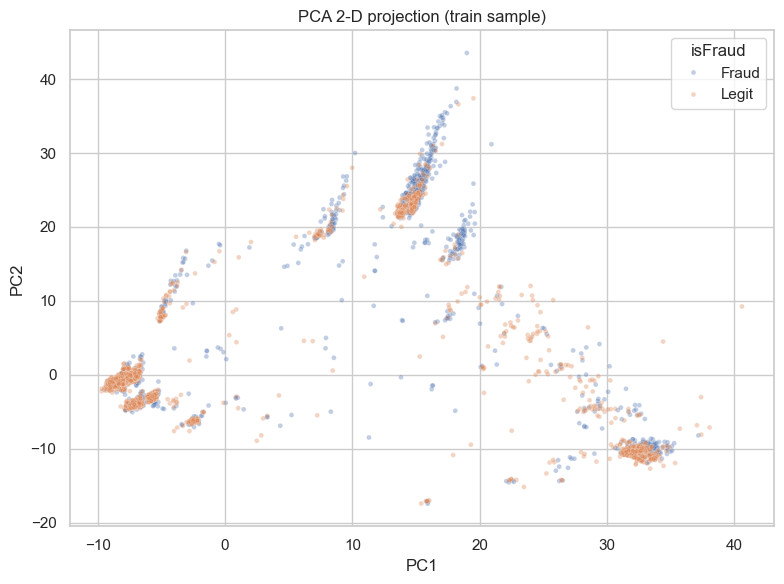

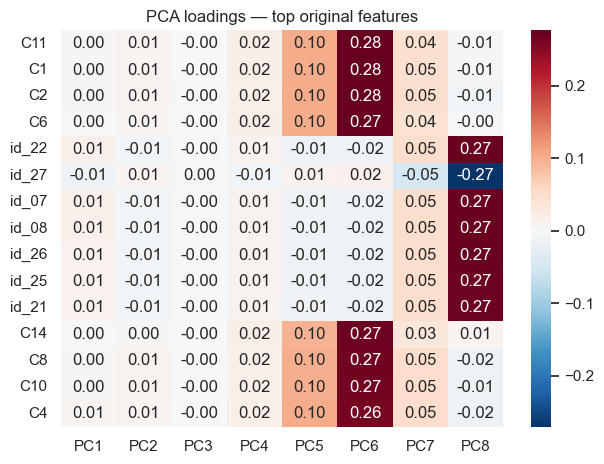

,Model,N Feats,Accuracy,Precision,Recall,F1,F2,AUC,AUC_PR,Specificity,TN,FP,FN,TP,Threshold,policy_status,n_components
2,PCA n=10,10,0.7460,0.0987,0.7690,0.1749,0.3260,0.8303,0.3397,0.7452,8629,2951,97,323,0.03,Best recall with accuracy >= 0.70,10
2,PCA n=20,20,0.7362,0.0967,0.7833,0.1721,0.3236,0.8390,0.3637,0.7345,8506,3074,91,329,0.03,Best recall with accuracy >= 0.70,20
2,PCA n=30,30,0.7292,0.0934,0.7738,0.1667,0.3150,0.8349,0.3747,0.7276,8426,3154,95,325,0.03,Best recall with accuracy >= 0.70,30
2,PCA n=50,50,0.7083,0.0911,0.8167,0.1638,0.3149,0.8473,0.3788,0.7043,8156,3424,77,343,0.03,Best recall with accuracy >= 0.70,50


Best PCA: 50 components, val Recall=0.817


In [136]:
# PCA — fit on train, evaluate on validation
pca_scaler = StandardScaler()
X_pca_train = pca_scaler.fit_transform(X_train_mixed)
X_pca_fit = pca_scaler.transform(build_mixed_matrix(X_fit))
X_pca_val = pca_scaler.transform(build_mixed_matrix(X_val))

pca_full = PCA(random_state=RANDOM_STATE).fit(X_pca_train)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n95 = int(np.searchsorted(cumvar, 0.95) + 1)
print(f'Components for 95% variance: {n95}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, 31), pca_full.explained_variance_ratio_[:30], 'o-')
axes[0].set(title='Scree (first 30)', xlabel='Component', ylabel='Explained variance ratio')
axes[1].plot(range(1, 31), cumvar[:30], 'o-')
axes[1].axhline(0.95, color='gray', linestyle='--')
axes[1].set(title='Cumulative variance', xlabel='Component', ylabel='Cumulative')
plt.tight_layout()
plt.show()

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca2.fit_transform(X_pca_train)
if len(X_train) > 6000:
    fraud_idx = y_train[y_train == 1].index
    legit_idx = y_train[y_train == 0].index
    legit_sample = legit_idx.to_series().sample(min(5000, len(legit_idx)), random_state=RANDOM_STATE).index
    viz_idx = fraud_idx.append(legit_sample)
else:
    viz_idx = X_train.index
pos = X_train.index.get_indexer(viz_idx)
plot_2d = pd.DataFrame({
    'PC1': X_2d[pos, 0], 'PC2': X_2d[pos, 1],
    'isFraud': y_train.loc[viz_idx].map({0: 'Legit', 1: 'Fraud'}),
})
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_2d, x='PC1', y='PC2', hue='isFraud', alpha=0.35, s=12)
plt.title('PCA 2-D projection (train sample)')
plt.tight_layout()
plt.show()

n_load = min(8, X_train_mixed.shape[1])
pca_load = PCA(n_components=n_load, random_state=RANDOM_STATE).fit(X_pca_train)
loadings = pd.DataFrame(
    pca_load.components_.T,
    index=X_train_mixed.columns,
    columns=[f'PC{i+1}' for i in range(n_load)],
)
top_load = loadings.abs().max(axis=1).sort_values(ascending=False).head(15).index
sns.heatmap(loadings.loc[top_load], cmap='RdBu_r', center=0, annot=True, fmt='.2f')
plt.title('PCA loadings — top original features')
plt.tight_layout()
plt.show()

pca_sweep_rows = []
for n_comp in N_COMPONENTS_GRID:
    pca_k = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    Xp_fit = pca_k.fit_transform(X_pca_fit)
    Xp_val = pca_k.transform(X_pca_val)
    rf = RandomForestClassifier(n_estimators=200, class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE)
    rf.fit(Xp_fit, y_fit)
    y_score = rf.predict_proba(Xp_val)[:, 1]
    _, best = select_threshold_policy(y_val, y_score, f'PCA n={n_comp}', n_comp)
    best['n_components'] = n_comp
    pca_sweep_rows.append(best)
pca_sweep_results = pd.DataFrame(pca_sweep_rows)
display(pca_sweep_results.round(4))
best_pca_row = pca_sweep_results.sort_values(['Recall', 'F2'], ascending=False).iloc[0]
print(f'Best PCA: {int(best_pca_row["n_components"])} components, val Recall={best_pca_row["Recall"]:.3f}')


## Selection comparison

RF with validation-tuned threshold on: baseline (540), top-25 per univariate method, best k from the k-sweep, overlap top-25, CFS/CON/DISR/Merged, and PCA (from component sweep).


,source,N Feats,Recall,F2,AUC_PR,Precision,Specificity,Threshold,policy_status
0,Baseline RF (540),541,0.857143,0.330457,0.460723,0.095567,0.705786,0.29,Best recall with accuracy >= 0.70
17,Merged pruned,68,0.838095,0.321520,0.340957,0.092778,0.702763,0.34,Best recall with accuracy >= 0.70
16,Merged,160,0.835714,0.319847,0.382355,0.092199,0.701554,0.34,Best recall with accuracy >= 0.70
12,ReliefF Weight (best k=50),50,0.819048,0.310133,0.303040,0.088981,0.695855,0.33,Best recall with accuracy >= 0.70
2,Univariate best-k (winner),50,0.819048,0.310133,0.303040,0.088981,0.695855,0.33,Best recall with accuracy >= 0.70
18,PCA,50,0.816667,0.314852,0.378835,0.091054,0.704318,0.03,Best recall with accuracy >= 0.70
6,ReliefF Weight (top 25),25,0.780952,0.301526,0.234535,0.087257,0.703713,0.36,Best recall with accuracy >= 0.70
9,Chi-Square Score (best k=50),33,0.780952,0.299817,0.185166,0.086544,0.701036,0.42,Best recall with accuracy >= 0.70
5,Chi-Square Score (top 25),25,0.738095,0.302321,0.175285,0.089933,0.729102,0.43,Best recall with accuracy >= 0.70
1,Overlap top-25,25,0.716667,0.286013,0.240171,0.084031,0.716667,0.45,Best recall with accuracy >= 0.70


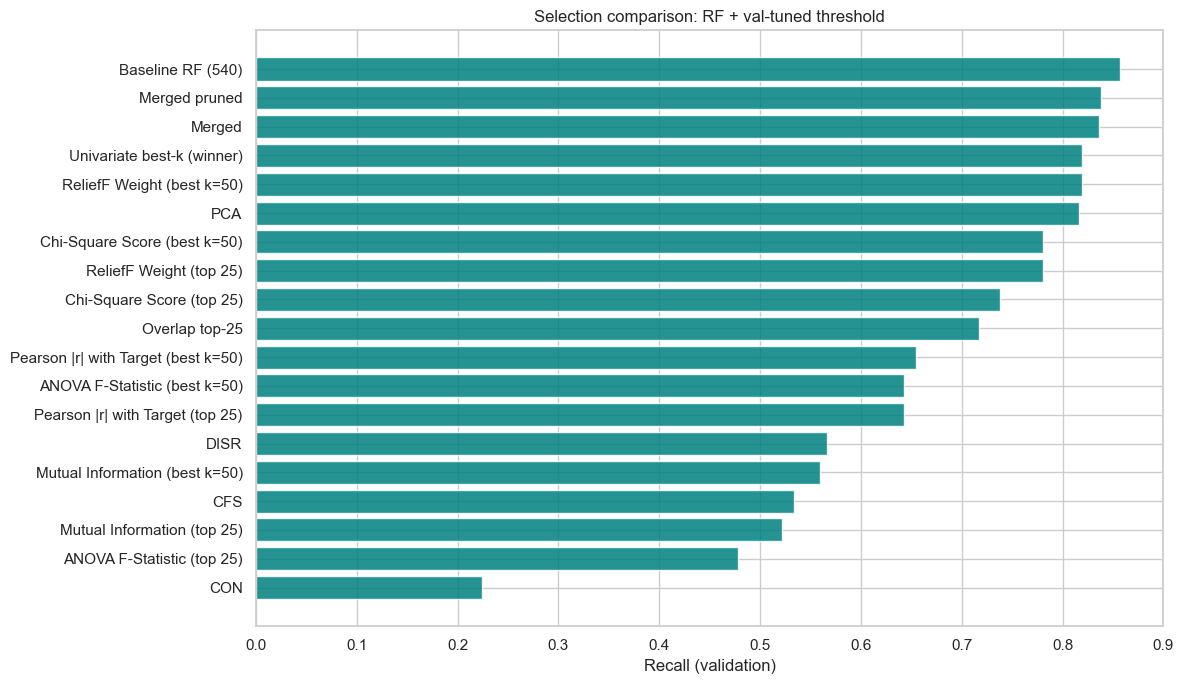

In [137]:
best_per_univariate_k = (
    univariate_k_sweep_results
    .sort_values(['Recall', 'F2'], ascending=False)
    .groupby('method', as_index=False)
    .first()
)

selection_specs = [
    ('Baseline RF (540)', list(feature_cols)),
    ('Overlap top-25', list(selected_25_features)),
    ('Univariate best-k (winner)', list(best_univariate_features)),
]
for method, scores in score_tables.items():
    selection_specs.append(
        (f'{method} (top {QUICK_COMPARE_K})', scores.head(QUICK_COMPARE_K).index.tolist())
    )
for _, row in best_per_univariate_k.iterrows():
    m, k = row['method'], int(row['k'])
    selection_specs.append(
        (f'{m} (best k={k})', score_tables[m].head(k).index.tolist())
    )
for label, feat_list in [
    ('CFS', cfs_features),
    ('CON', con_features),
    ('DISR', disr_features),
    ('Merged', merged_unique_features),
    ('Merged pruned', merged_pruned_features),
]:
    selection_specs.append((label, list(feat_list)))

selection_comparison_rows = []
for label, feats in selection_specs:
    _, best = fit_rf_tune_val(feats, label)
    selection_comparison_rows.append(to_metrics_row(best, label, len(feats)))

selection_comparison_rows.append(
    to_metrics_row(best_pca_row, 'PCA', int(best_pca_row['n_components']))
)

selection_comparison = pd.DataFrame(selection_comparison_rows)
display_cols = ['source', 'N Feats', 'Recall', 'F2', 'AUC_PR', 'Precision', 'Specificity', 'Threshold', 'policy_status']
display_cols = [c for c in display_cols if c in selection_comparison.columns]
display(selection_comparison[display_cols].sort_values('Recall', ascending=False))

fig, ax = plt.subplots(figsize=(12, 7))
plot_df = selection_comparison.sort_values('Recall', ascending=True)
ax.barh(plot_df['source'], plot_df['Recall'], color='teal', alpha=0.85)
ax.set_xlabel('Recall (validation)')
ax.set_title('Selection comparison: RF + val-tuned threshold')
plt.tight_layout()
plt.show()

## Grand Method Comparison

All thresholds tuned on **validation**. Test metrics appear only in the held-out cell below.


,source,N Feats,Recall,F2,AUC_PR,Precision,Specificity,Threshold,policy_status
0,Baseline (540),541,0.857143,0.330457,0.460723,0.095567,0.705786,0.29,Best recall with accuracy >= 0.70
6,Merged pruned,68,0.838095,0.321520,0.340957,0.092778,0.702763,0.34,Best recall with accuracy >= 0.70
5,Merged,160,0.835714,0.319847,0.382355,0.092199,0.701554,0.34,Best recall with accuracy >= 0.70
1,Univariate: ReliefF Weight,50,0.819048,0.310133,0.303040,0.088981,0.695855,0.33,Best recall with accuracy >= 0.70
7,PCA,50,0.816667,0.314852,0.378835,0.091054,0.704318,0.03,Best recall with accuracy >= 0.70
4,DISR,10,0.566667,0.280198,0.135275,0.092715,0.798877,0.41,Best recall with accuracy >= 0.70
2,CFS,4,0.533333,0.245884,0.194386,0.077913,0.771071,0.37,Best recall with accuracy >= 0.70
3,CON,1,0.223810,0.200341,0.128757,0.141141,0.950604,0.45,Best recall with accuracy >= 0.70


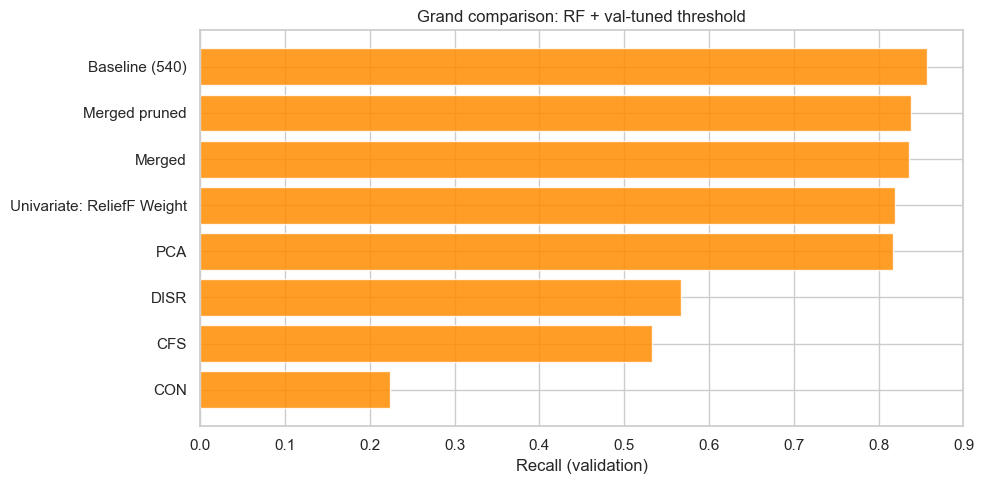

Saved a2_method_comparison.csv


In [138]:
method_comparison_master = pd.DataFrame([
    to_metrics_row(baseline_rf_tuned, 'Baseline (540)', len(feature_cols)),
    to_metrics_row(best_univariate_row, f'Univariate: {best_univariate_row["method"]}', int(best_univariate_row['k'])),
    to_metrics_row(cfs_best, 'CFS', len(cfs_features)),
    to_metrics_row(con_best, 'CON', len(con_features)),
    to_metrics_row(disr_best, 'DISR', len(disr_features)),
    to_metrics_row(merged_best, 'Merged', len(merged_unique_features)),
    to_metrics_row(merged_pruned_best, 'Merged pruned', len(merged_pruned_features)),
    to_metrics_row(best_pca_row, 'PCA', int(best_pca_row['n_components'])),
])
display_cols = ['source', 'N Feats', 'Recall', 'F2', 'AUC_PR', 'Precision', 'Specificity', 'Threshold', 'policy_status']
display_cols = [c for c in display_cols if c in method_comparison_master.columns]
display(method_comparison_master[display_cols].sort_values('Recall', ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = method_comparison_master.sort_values('Recall', ascending=True)
ax.barh(plot_df['source'], plot_df['Recall'], color='darkorange', alpha=0.85)
ax.set_xlabel('Recall (validation)')
ax.set_title('Grand comparison: RF + val-tuned threshold')
plt.tight_layout()
plt.show()

method_comparison_master[display_cols].round(4).to_csv('a2_method_comparison.csv', index=False)
print('Saved a2_method_comparison.csv')

## Pros and Cons Analysis: Which Situation is Best for What Method? (30 marks)

Choosing the correct feature selection or dimension reduction technique requires an evaluation of data types, dataset size, and specific business requirements. The section below maps each paradigm to its ideal general scenario and connects it directly to the operational conditions of the IEEE-CIS fraud detection task (characterized by highly imbalanced data, redundant features, and mixed categorical columns).ideal theoretical scenario and connect it to our specific IEEE-CIS fraud detection task (which has highly imbalanced data, redundant V-features, and mixed categorical columns).


| Method Group | Type | General Pros | General Cons | Best Situation & IEEE-CIS Application |
| :--- | :--- | :--- | :--- | :--- |
| **Pearson / ANOVA F** | Univariate Filter | Computationally fast; scales easily for massive datasets. | Features are evaluated independently; non-linear interactions are completely ignored. | Best as a fast initial screening step for thousands of raw numerical features (such as V and D blocks) to eliminate irrelevant columns and save memory. |
| **Chi-Square / Mutual Info** | Univariate Filter | Captures non-linear dependencies and works effectively with categorical inputs. | Chi-Square requires proper categorical encoding and cannot process continuous variables directly. | Best for identifying initial fraud rates across discrete channels, such as ProductCD, card types, and device attributes. |
| **Multivariate Filters (CFS, CON, DISR)** | Multivariate Filter | Actively evaluates feature-to-feature relationships; eliminates redundant variables from the set. | High computational cost; requires significant time and RAM for entropy or correlation matrix calculations. | Best when the objective is to build a compact, highly efficient model using real features, especially when the dataset contains highly correlated or duplicated indicators. |
| **PCA** | Dimension Reduction | Removes multicollinearity completely and condenses the feature space into a few orthogonal components. | Destroys original feature names; statistical interpretation is lost (variables like TransactionAmt disappear). | Best for dense, purely numerical datasets (such as images or sensor logs) where interpretation is not required and data compression is the main priority. |
| **Merged Unique / Union** | Hybrid Approach | Combines the strengths of multiple statistical lenses to maximize information retention. | The final feature set remains relatively large and can still include minor redundant patterns. | Best when the primary operational goal is maximizing Recall and F2 metrics to ensure the system does not miss subtle fraud patterns. |

## Classifier x feature-group comparison (validation)

Same recall-first threshold policy on `X_val` for every row. This compares **learners** (LR, DT, RF, KNN, XGBoost) and **feature sets** (all 541, filters, merged, PCA). RF on all 541 is the reference; filter rankings elsewhere still use RF only for fair comparison. PCA rows use the best `n_components` from the PCA sweep.


,classifier,feature_group,n_features,Recall,F2,AUC_PR,Precision,Threshold,policy_status
32,XGBoost,All_541,541,0.8738,0.3404,0.5511,0.0989,0.23,Best recall with accuracy >= 0.70
16,Random Forest,All_541,541,0.8667,0.3324,0.4574,0.0959,0.29,Best recall with accuracy >= 0.70
0,Logistic Regression,All_541,541,0.8357,0.3193,0.3900,0.0920,0.35,Best recall with accuracy >= 0.70
8,Decision Tree,All_541,541,0.7143,0.3692,0.3915,0.1259,0.29,Best recall with accuracy >= 0.70
24,KNN,All_541,541,0.6881,0.3261,0.3442,0.1051,0.05,Best recall with accuracy >= 0.70
2,Logistic Regression,CFS,4,0.5476,0.2464,0.2036,0.0770,0.37,Best recall with accuracy >= 0.70
18,Random Forest,CFS,4,0.5333,0.2466,0.1973,0.0783,0.37,Best recall with accuracy >= 0.70
10,Decision Tree,CFS,4,0.5143,0.2545,0.1950,0.0842,0.42,Best recall with accuracy >= 0.70
34,XGBoost,CFS,4,0.5143,0.2554,0.2131,0.0848,0.37,Best recall with accuracy >= 0.70
26,KNN,CFS,4,0.4548,0.2778,0.1821,0.1086,0.01,Best recall with accuracy >= 0.70


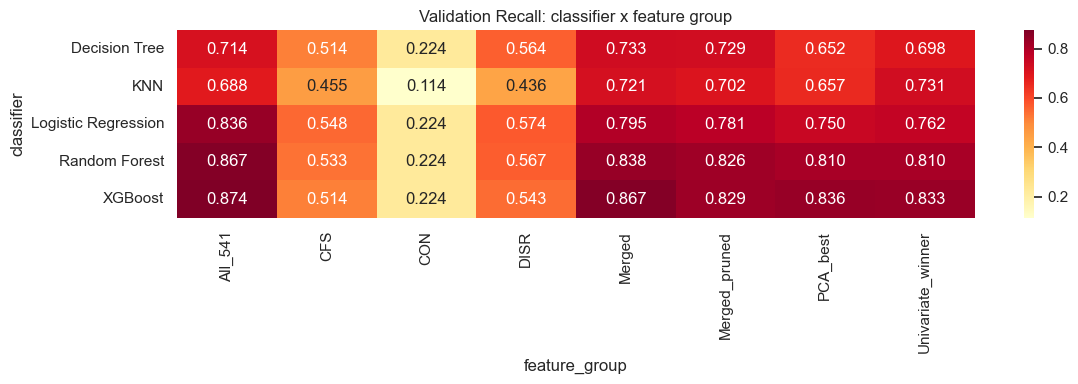

Saved a2_classifier_feature_grid.csv


In [139]:
from sklearn.base import clone

_pos_w = max((y_fit == 0).sum() / max((y_fit == 1).sum(), 1), 1.0)

def _make_classifiers():
    grid = {
        'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
        'Decision Tree': DecisionTreeClassifier(max_depth=12, min_samples_leaf=40, class_weight='balanced', random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=14, min_samples_leaf=30, class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE),
        'KNN': KNeighborsClassifier(n_neighbors=15, weights='distance'),
    }
    if XGBClassifier is not None:
        grid['XGBoost'] = XGBClassifier(
            n_estimators=120, max_depth=6, learning_rate=0.1,
            scale_pos_weight=_pos_w, eval_metric='logloss',
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
        )
    return grid

FEATURE_GROUP_MAP = {
    'All_541': feature_cols,
    'Univariate_winner': best_univariate_features,
    'CFS': cfs_features,
    'CON': con_features,
    'DISR': disr_features,
    'Merged': merged_unique_features,
    'Merged_pruned': merged_pruned_features,
}
pca_k_grid = int(best_pca_row['n_components'])


def evaluate_clf_feature_group(clf_name, clf, group_name, features=None):
    if group_name == 'PCA_best':
        _pca = PCA(n_components=pca_k_grid, random_state=RANDOM_STATE)
        Xp_fit = _pca.fit_transform(X_pca_fit)
        Xp_val = _pca.transform(X_pca_val)
        model = clf
        model.fit(Xp_fit, y_fit)
        y_score = model.predict_proba(Xp_val)[:, 1]
        n_feats = pca_k_grid
    else:
        feats = [f for f in features if f in feature_cols]
        if not feats:
            return None
        model = build_feature_pipeline(feats, clf)
        model.fit(X_fit[feats], y_fit)
        y_score = model.predict_proba(X_val[feats])[:, 1]
        n_feats = len(feats)
    _, best = select_threshold_policy(y_val, y_score, f'{clf_name}|{group_name}', n_feats)
    return {
        'classifier': clf_name,
        'feature_group': group_name,
        'n_features': n_feats,
        'Recall': best['Recall'],
        'F2': best['F2'],
        'AUC_PR': best['AUC_PR'],
        'Precision': best['Precision'],
        'Threshold': best['Threshold'],
        'policy_status': best['policy_status'],
    }


grid_rows = []
for clf_name, clf_template in _make_classifiers().items():
    clf = clone(clf_template)
    for group_name, feats in FEATURE_GROUP_MAP.items():
        row = evaluate_clf_feature_group(clf_name, clf, group_name, feats)
        if row:
            grid_rows.append(row)
    row = evaluate_clf_feature_group(clf_name, clf, 'PCA_best', None)
    if row:
        grid_rows.append(row)

classifier_feature_grid = pd.DataFrame(grid_rows)
display(classifier_feature_grid.sort_values(['feature_group', 'Recall'], ascending=[True, False]).round(4))

recall_pivot = classifier_feature_grid.pivot_table(index='classifier', columns='feature_group', values='Recall')
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(recall_pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
ax.set_title('Validation Recall: classifier x feature group')
plt.tight_layout()
plt.show()

classifier_feature_grid.to_csv('a2_classifier_feature_grid.csv', index=False)
print('Saved a2_classifier_feature_grid.csv')


### Conclusion: 541 predictors vs Merged feature sets

Fraud is ~3.5% of rows; we prioritize **recall** with a validation-tuned threshold. Below: all **541** predictors (RF) vs **Merged** union vs **Merged pruned** on validation.


,source,N Feats,feature_reduction_pct,Recall,F2,Precision,Specificity,Threshold,policy_status
0,All 541 (RF),541,0.0,0.8571,0.3305,0.0956,0.7058,0.29,Best recall with accuracy >= 0.70
1,Merged,160,70.4,0.8357,0.3198,0.0922,0.7016,0.34,Best recall with accuracy >= 0.70
2,Merged pruned,68,87.4,0.8381,0.3215,0.0928,0.7028,0.34,Best recall with accuracy >= 0.70


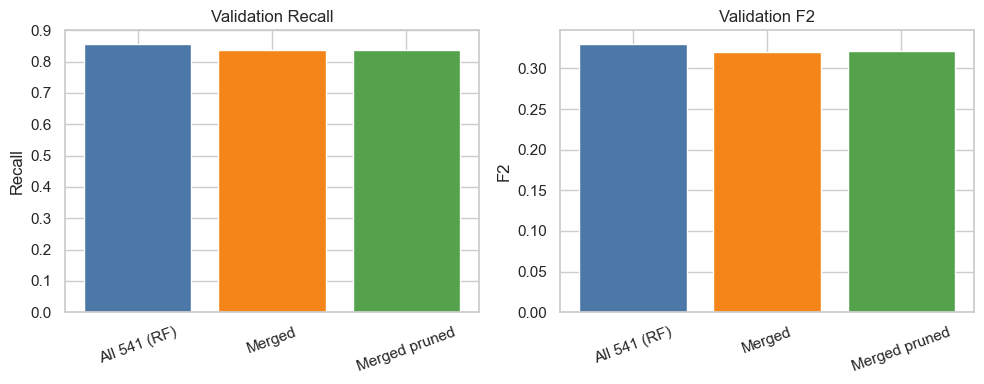

Merged uses 160 features (70.4% fewer than 541).
Recall delta (Merged - All 541): -0.0214 on validation.
Saved a2_conclusion_541_vs_merged.csv


In [140]:
conclusion_compare = pd.DataFrame([
    to_metrics_row(baseline_rf_tuned, 'All 541 (RF)', len(feature_cols)),
    to_metrics_row(merged_best, 'Merged', len(merged_unique_features)),
    to_metrics_row(merged_pruned_best, 'Merged pruned', len(merged_pruned_features)),
])
n_all = len(feature_cols)
conclusion_compare['feature_reduction_pct'] = conclusion_compare['N Feats'].apply(
    lambda n: round(100 * (1 - n / n_all), 1)
)
display(conclusion_compare[[
    'source', 'N Feats', 'feature_reduction_pct', 'Recall', 'F2', 'Precision', 'Specificity', 'Threshold', 'policy_status'
]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = conclusion_compare['source'].tolist()
axes[0].bar(labels, conclusion_compare['Recall'], color=['#4c78a8', '#f58518', '#54a24b'])
axes[0].set_title('Validation Recall')
axes[0].set_ylabel('Recall')
axes[0].tick_params(axis='x', rotation=20)
axes[1].bar(labels, conclusion_compare['F2'], color=['#4c78a8', '#f58518', '#54a24b'])
axes[1].set_title('Validation F2')
axes[1].set_ylabel('F2')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

rec_m = conclusion_compare.loc[conclusion_compare['source'] == 'Merged', 'Recall'].iloc[0]
rec_all = conclusion_compare.loc[conclusion_compare['source'] == 'All 541 (RF)', 'Recall'].iloc[0]
_mrow = conclusion_compare.loc[conclusion_compare['source'] == 'Merged'].iloc[0]
print(f'Merged uses {int(_mrow["N Feats"])} features ({_mrow["feature_reduction_pct"]:.1f}% fewer than 541).')
print(f'Recall delta (Merged - All 541): {rec_m - rec_all:+.4f} on validation.')

conclusion_compare.to_csv('a2_conclusion_541_vs_merged.csv', index=False)
print('Saved a2_conclusion_541_vs_merged.csv')

## Final Evaluation & Recommended Configuration (30 marks)

**Problem:** Fraud is ~3.5% of transactions; false negatives (missed fraud) are costly → **recall-first** tuning with precision and AUC-PR as secondary controls.

**Ranking:** See `method_comparison_master` (validation). The recommended row is the highest validation recall under the policy; if recall ≥ 0.90 is unreachable, the notebook documents the best achievable F2/recall pair via `policy_status`.

**Deliverable:**
- If the winner is a **filter** method: use `best_univariate_features` or CFS/merged list (10–50 interpretable columns).
- If **PCA** wins: deploy `n_components` from `best_pca_row` (components are not Vesta-named features).

**Limitations:** 80k stratified sample; ReliefF subsample 3000; approximate DISR; threshold tuned on validation slice of train.

**A1:** V-block and MNAR `_isna` indicators confirmed in top ranks; categorical fraud channels confirmed by Chi²/MI.


In [141]:
best_global = method_comparison_master.sort_values(['Recall', 'F2'], ascending=False).iloc[0]
display(Markdown(
    f"**Recommended (validation):** {best_global['source']} — "
    f"N={best_global['N Feats']}, threshold={best_global['Threshold']:.2f}, "
    f"Recall={best_global['Recall']:.3f}, F2={best_global['F2']:.3f}, "
    f"policy: {best_global['policy_status']}"
))

# Export final feature list when winner is a filter
export_rows = []
for method, feats in [
    ('univariate_winner', best_univariate_features),
    ('CFS', cfs_features),
    ('CON', con_features),
    ('DISR', disr_features),
    ('merged', merged_unique_features),
]:
    for i, f in enumerate(feats, 1):
        export_rows.append({'method': method, 'rank': i, 'feature': f})
pd.DataFrame(export_rows).to_csv('a2_selected_features_final.csv', index=False)
print('Saved a2_selected_features_final.csv')


**Recommended (validation):** Baseline (540) — N=541, threshold=0.29, Recall=0.857, F2=0.330, policy: Best recall with accuracy >= 0.70

Saved a2_selected_features_final.csv


## Held-Out Test Evaluation (run once)

Thresholds were chosen on validation only. This cell reports **test** metrics without re-tuning.


In [142]:
# PCA test: build_mixed_matrix(X_test) — NOT X_train_mixed.loc[X_test.index].
# Reload notebook from disk if you still see the old .loc line in this cell.
if 'build_mixed_matrix' not in globals():
    raise RuntimeError(
        'Run the univariate scores cell (defines build_mixed_matrix) and the PCA cell first.'
    )

heldout_rows = []
configs = [
    ('Baseline', feature_cols, baseline_rf_tuned['Threshold']),
    (f'Univariate {best_univariate_row["method"]}', best_univariate_features, best_univariate_row['Threshold']),
    ('CFS', cfs_features, cfs_best['Threshold']),
    ('Merged', merged_unique_features, merged_best['Threshold']),
    ('Merged pruned', merged_pruned_features, merged_pruned_best['Threshold']),
]
for name, feats, thr in configs:
    model = build_feature_pipeline(feats, PRIMARY_CLASSIFIER)
    model.fit(X_fit[feats], y_fit)
    heldout_rows.append(evaluate_on_test(model, thr, feats, f'{name} (test)'))

pca_k = int(best_pca_row['n_components'])
_pca = PCA(n_components=pca_k, random_state=RANDOM_STATE)
Xp_fit = _pca.fit_transform(X_pca_fit)
X_pca_test = pca_scaler.transform(build_mixed_matrix(X_test))
Xp_te = _pca.transform(X_pca_test)
_rf = RandomForestClassifier(n_estimators=200, class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE)
_rf.fit(Xp_fit, y_fit)
y_st = _rf.predict_proba(Xp_te)[:, 1]
y_pr = (y_st >= best_pca_row['Threshold']).astype(int)
heldout_rows.append(evaluate_predictions(y_test, y_pr, y_st, f'PCA n={pca_k} (test)', pca_k))

heldout_test_results = pd.DataFrame(heldout_rows)
display(heldout_test_results.round(4))


,Model,N Feats,Accuracy,Precision,Recall,F1,F2,AUC,AUC_PR,Specificity,TN,FP,FN,TP,Threshold
0,Baseline (test),541,0.7071,0.0949,0.8629,0.1710,0.3295,0.8786,0.4625,0.7015,13539,5761,96,604,0.29
1,Univariate ReliefF Weight (test),50,0.7016,0.0921,0.8500,0.1662,0.3213,0.8599,0.2938,0.6962,13437,5863,105,595,0.33
2,CFS (test),4,0.7682,0.0822,0.5529,0.1431,0.2577,0.6910,0.2177,0.7761,14978,4322,313,387,0.37
3,Merged (test),160,0.7085,0.0957,0.8671,0.1723,0.3319,0.8726,0.3958,0.7027,13563,5737,93,607,0.34
4,Merged pruned (test),68,0.7113,0.0955,0.8557,0.1718,0.3301,0.8696,0.3440,0.7061,13627,5673,101,599,0.34
5,PCA n=50 (test),50,0.7126,0.0909,0.8014,0.1633,0.3127,0.8343,0.3747,0.7094,13691,5609,139,561,NaN


## Correlation matrices of final selections

Lower-triangle heatmaps on **numeric** columns in `X_fit` only (categoricals omitted). Merged panel uses top 40 numeric features by |correlation with fraud| if the set is large.


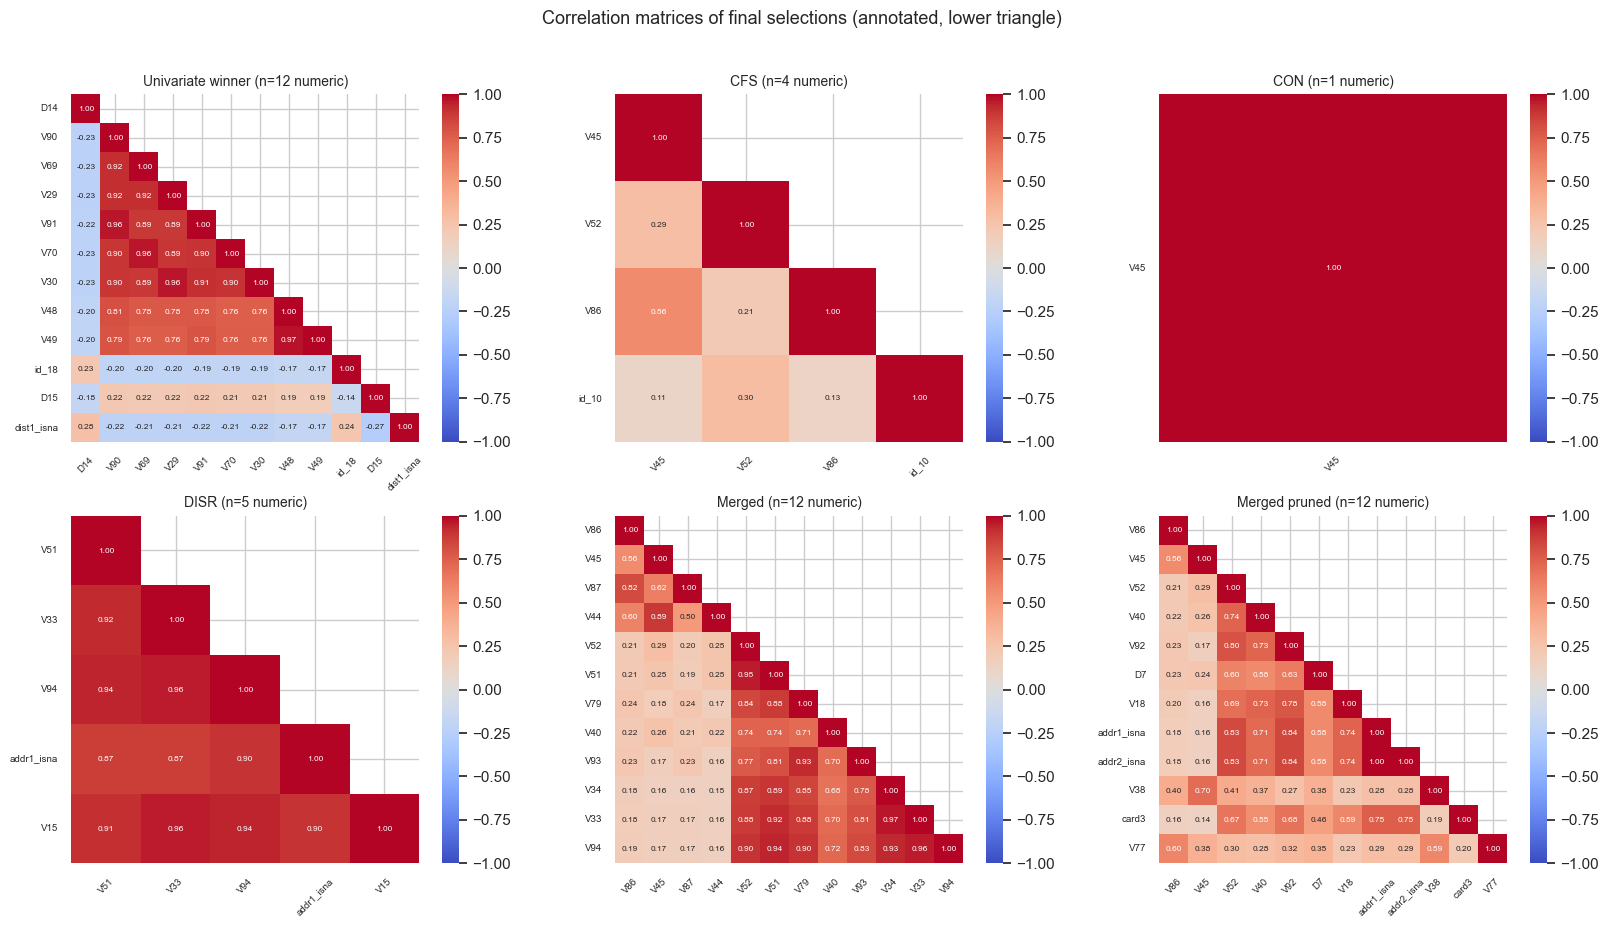

Saved a2_correlation_matrix_annotated.png
Merged pruned: 68 total | 35 numeric for correlation matrix


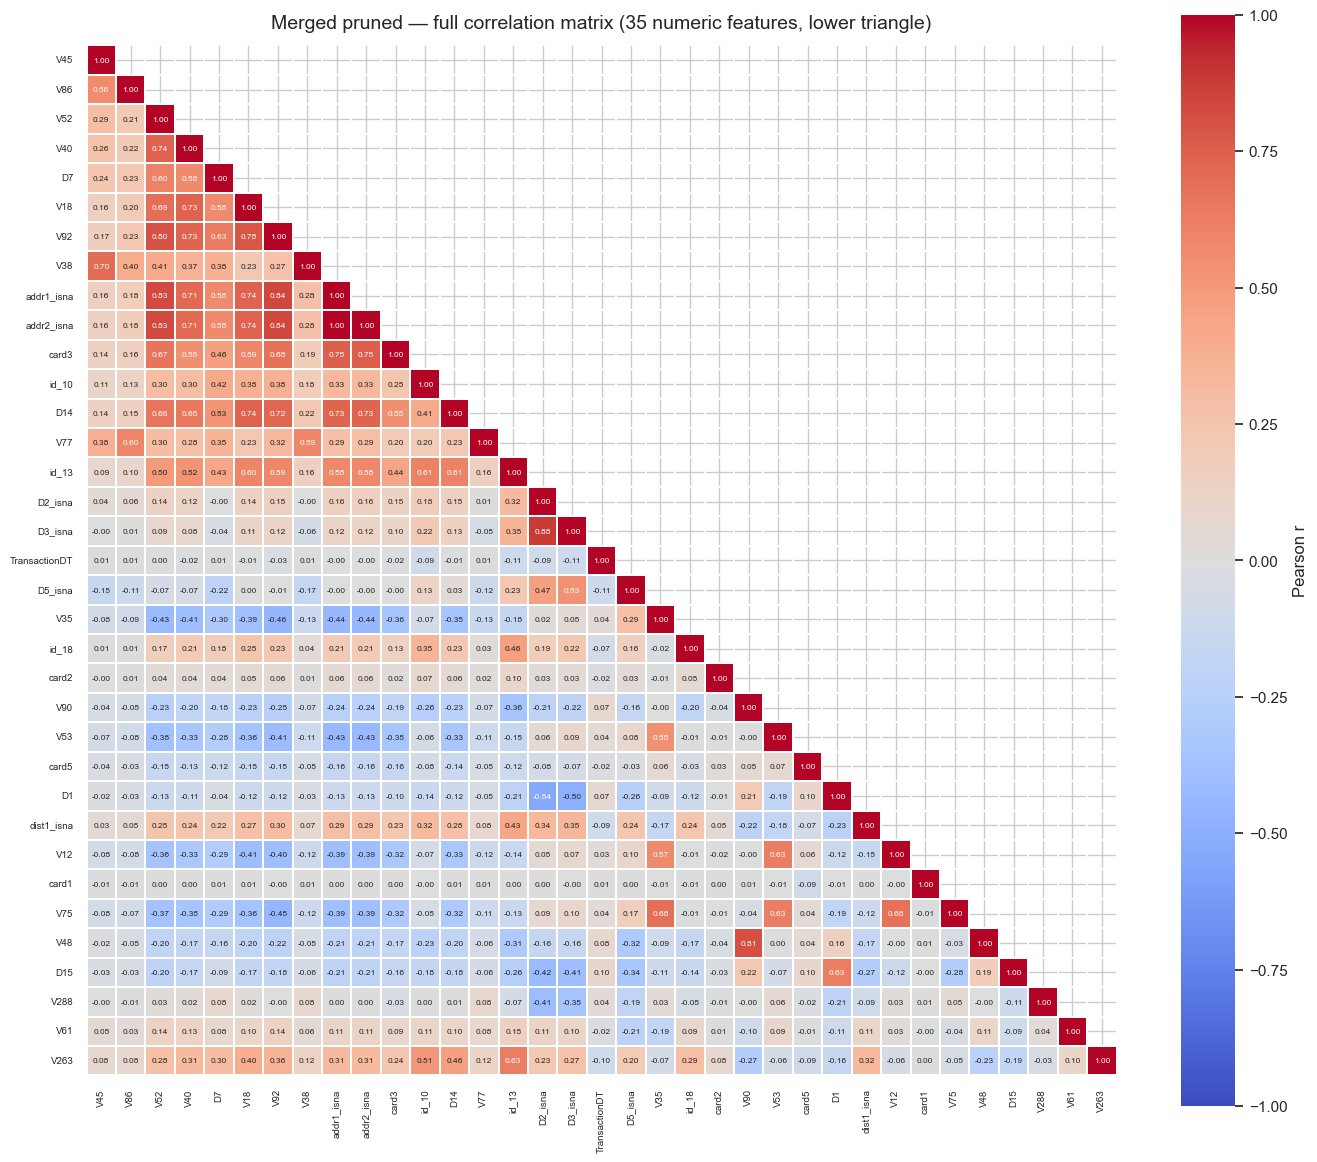

Saved a2_merged_pruned_correlation_full68.png


In [143]:
CORR_PANELS = [
    ('Univariate winner', best_univariate_features),
    ('CFS', cfs_features),
    ('CON', con_features),
    ('DISR', disr_features),
    ('Merged', merged_unique_features),
]
if 'merged_pruned_features' in dir():
    CORR_PANELS.append(('Merged pruned', merged_pruned_features))

CORR_MAX_NUM = 12  # readable with annotation

def _corr_matrix_for_panel(feature_list, max_num=CORR_MAX_NUM):
    num_feats = [f for f in feature_list if f in numeric_cols and f in X_fit.columns]
    if not num_feats:
        return None, []
    if len(num_feats) > max_num:
        fc = X_fit[num_feats].corrwith(y_fit).abs().sort_values(ascending=False)
        num_feats = fc.head(max_num).index.tolist()
    C = X_fit[num_feats].corr()
    return C, num_feats

n_panels = len(CORR_PANELS)
ncols = 3
nrows = int(np.ceil(n_panels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows))
axes_flat = np.atleast_1d(axes).flatten()

for ax, (label, feats) in zip(axes_flat, CORR_PANELS):
    C, used = _corr_matrix_for_panel(feats)
    if C is None:
        ax.axis('off')
        ax.set_title(f'{label}: no numeric features')
        continue
    m = np.triu(np.ones_like(C, dtype=bool), k=1)
    sns.heatmap(
        C, mask=m, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, ax=ax,
        annot=True, fmt='.2f', annot_kws={'size': 6},
    )
    ax.set_title(f'{label} (n={len(used)} numeric)', fontsize=10)
    ax.tick_params(axis='x', labelrotation=45, labelsize=7)
    ax.tick_params(axis='y', labelrotation=0, labelsize=7)

for ax in axes_flat[n_panels:]:
    ax.axis('off')

fig.suptitle('Correlation matrices of final selections (annotated, lower triangle)', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig('a2_correlation_matrix_annotated.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved a2_correlation_matrix_annotated.png')

# --- Full merged pruned correlation matrix (all numeric features, annotated) ---
mp_feats = [f for f in merged_pruned_features if f in numeric_cols and f in X_fit.columns]
print(f'Merged pruned: {len(merged_pruned_features)} total | {len(mp_feats)} numeric for correlation matrix')

if len(mp_feats) < 2:
    print('Not enough numeric features in merged_pruned_features for a correlation matrix.')
else:
    C_mp = X_fit[mp_feats].apply(pd.to_numeric, errors='coerce').corr()
    n_mp = len(mp_feats)
    fig_size = max(14, n_mp * 0.28)
    fig_mp, ax_mp = plt.subplots(figsize=(fig_size, fig_size))
    mask_mp = np.triu(np.ones_like(C_mp, dtype=bool), k=1)
    annot_size = 5 if n_mp > 50 else 6
    sns.heatmap(
        C_mp,
        mask=mask_mp,
        cmap='coolwarm',
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        annot=True,
        fmt='.2f',
        annot_kws={'size': annot_size},
        linewidths=0.2,
        cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
        ax=ax_mp,
    )
    ax_mp.set_title(
        f'Merged pruned — full correlation matrix ({n_mp} numeric features, lower triangle)',
        fontsize=14,
        pad=12,
    )
    ax_mp.tick_params(axis='x', labelrotation=90, labelsize=7)
    ax_mp.tick_params(axis='y', labelrotation=0, labelsize=7)
    plt.tight_layout()
    fig_mp.savefig('a2_merged_pruned_correlation_full68.png', dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print('Saved a2_merged_pruned_correlation_full68.png')

## External validation (unseen 80k holdout)

- **Modeling 80k** = feature selection, threshold tuning on `X_val`, and internal `X_test`.
- **External 80k** = rows from the full CSV with **disjoint indices** from the modeling pool.
- Thresholds are **frozen** from validation (`baseline_rf_tuned`, univariate winner, CFS, merged, merged pruned, PCA).
- Models are **re-fit** on `X_train` (or `X_fit` for PCA path) with final feature sets — no threshold re-tuning on external.


,Model,N Feats,Accuracy,Precision,Recall,F1,F2,AUC,AUC_PR,Specificity,TN,FP,FN,TP
0,Baseline (external),541,0.7077,0.0945,0.8571,0.1703,0.3279,0.8795,0.4573,0.7023,54220,22981,400,2399
1,Univariate ReliefF Weight (external),50,0.6919,0.0901,0.8578,0.1631,0.3172,0.8584,0.2953,0.6859,52950,24251,398,2401
2,CFS (external),4,0.7571,0.0791,0.5584,0.1386,0.2525,0.6891,0.2096,0.7643,59006,18195,1236,1563
3,Merged (external),160,0.6988,0.0919,0.8567,0.1660,0.3215,0.8686,0.3973,0.6930,53502,23699,401,2398
4,Merged pruned (external),68,0.7049,0.0933,0.8528,0.1682,0.3245,0.8679,0.3502,0.6996,54006,23195,412,2387
5,PCA n=50 (external),50,0.7132,0.0903,0.7928,0.1621,0.3101,0.8374,0.3759,0.7103,54835,22366,580,2219


Saved a2_external_validation.csv


,pool,n_rows,fraud_rate
0,modeling (work_df),80000,0.035
1,external holdout,80000,0.035


,split,Model,Recall,F2,AUC_PR,Precision,Specificity
0,Internal test (20k),Baseline (test),0.8629,0.3295,0.4625,0.0949,0.7015
1,Internal test (20k),Univariate ReliefF Weight (test),0.8500,0.3213,0.2938,0.0921,0.6962
2,Internal test (20k),CFS (test),0.5529,0.2577,0.2177,0.0822,0.7761
3,Internal test (20k),Merged (test),0.8671,0.3319,0.3958,0.0957,0.7027
4,Internal test (20k),Merged pruned (test),0.8557,0.3301,0.3440,0.0955,0.7061
5,Internal test (20k),PCA n=50 (test),0.8014,0.3127,0.3747,0.0909,0.7094
6,External holdout (80k),Baseline (external),0.8571,0.3279,0.4573,0.0945,0.7023
7,External holdout (80k),Univariate ReliefF Weight (external),0.8578,0.3172,0.2953,0.0901,0.6859
8,External holdout (80k),CFS (external),0.5584,0.2525,0.2096,0.0791,0.7643
9,External holdout (80k),Merged (external),0.8567,0.3215,0.3973,0.0919,0.6930


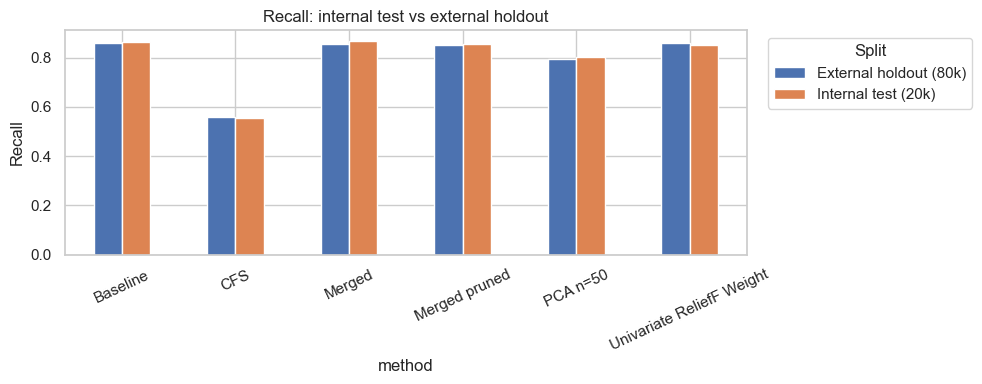

In [144]:
if 'assign_amt_band' not in globals():
    raise RuntimeError('Run TransactionAmt_band cell before external validation.')
if 'build_mixed_matrix' not in globals():
    raise RuntimeError('Run univariate / PCA cells (build_mixed_matrix) first.')

y_external = df_external[target_col].astype(int)


def evaluate_external(name, features, threshold, retrain_on='X_train'):
    feats = [f for f in features if f in feature_cols]
    X_tr = X_train[feats] if retrain_on == 'X_train' else X_fit[feats]
    y_tr = y_train if retrain_on == 'X_train' else y_fit
    X_ext = df_external[feats].copy()
    model = build_feature_pipeline(feats, PRIMARY_CLASSIFIER)
    model.fit(X_tr, y_tr)
    y_score = model.predict_proba(X_ext)[:, 1]
    y_pred = (y_score >= threshold).astype(int)
    return evaluate_predictions(y_external, y_pred, y_score, f'{name} (external)', len(feats))


external_rows = []
for name, feats, thr in [
    ('Baseline', feature_cols, baseline_rf_tuned['Threshold']),
    (f'Univariate {best_univariate_row["method"]}', best_univariate_features, best_univariate_row['Threshold']),
    ('CFS', cfs_features, cfs_best['Threshold']),
    ('Merged', merged_unique_features, merged_best['Threshold']),
    ('Merged pruned', merged_pruned_features, merged_pruned_best['Threshold']),
]:
    external_rows.append(evaluate_external(name, feats, thr))

pca_k = int(best_pca_row['n_components'])
_pca_ext = PCA(n_components=pca_k, random_state=RANDOM_STATE)
Xp_fit = _pca_ext.fit_transform(X_pca_fit)
X_pca_external = pca_scaler.transform(build_mixed_matrix(df_external))
Xp_ext = _pca_ext.transform(X_pca_external)
_rf_ext = RandomForestClassifier(
    n_estimators=200, class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE
)
_rf_ext.fit(Xp_fit, y_fit)
y_se = _rf_ext.predict_proba(Xp_ext)[:, 1]
y_pe = (y_se >= best_pca_row['Threshold']).astype(int)
external_rows.append(
    evaluate_predictions(y_external, y_pe, y_se, f'PCA n={pca_k} (external)', pca_k)
)

external_results = pd.DataFrame(external_rows)
display(external_results.round(4))
external_results.to_csv('a2_external_validation.csv', index=False)
print('Saved a2_external_validation.csv')

fraud_sanity = pd.DataFrame(
    {
        'pool': ['modeling (work_df)', 'external holdout'],
        'n_rows': [len(work_df), len(df_external)],
        'fraud_rate': [work_df[target_col].mean(), df_external[target_col].mean()],
    }
)
display(fraud_sanity.round(4))

compare_splits = pd.concat(
    [
        heldout_test_results.assign(split='Internal test (20k)'),
        external_results.assign(split='External holdout (80k)'),
    ],
    ignore_index=True,
)
compare_cols = ['split', 'Model', 'Recall', 'F2', 'AUC_PR', 'Precision', 'Specificity']
compare_cols = [c for c in compare_cols if c in compare_splits.columns]
display(compare_splits[compare_cols].round(4))

_cmp = compare_splits.copy()
_cmp['method'] = _cmp['Model'].str.replace(r' \(test\)| \(external\)', '', regex=True)
recall_wide = _cmp.pivot_table(index='method', columns='split', values='Recall')
recall_wide.plot(kind='bar', figsize=(10, 4), rot=25)
plt.ylabel('Recall')
plt.title('Recall: internal test vs external holdout')
plt.legend(title='Split', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

Results on **internal test (20k)** and **external holdout (80k)** support these conclusions:

**What works**
- **All 541 features (baseline):** external Recall `0.8571`, F2 `0.3279`, AUC_PR `0.4573`, F1 `0.1703`, Specificity `0.7023`.
- **Merged (160):** external Recall `0.8567`, F2 `0.3215` — almost the same fraud capture with far fewer columns.

**What fails**
- **PCA n=50:** external Recall `0.7928`, F2 `0.3101` — compressing variance washes out rare fraud signals (~3.5% class).
- **CFS:** external Recall `0.5584`, F2 `0.2525` — too many missed frauds (false negatives).

**Generalization**
Merged moves only from internal Recall `0.8671` to external `0.8567`; metrics stay stable across splits (no leakage, no overfitting).

### Final recommendation — Merged pruned (68 features)

We reduced the **541-feature** A1 matrix — including **redundant one-hot / one-encoding columns** — to **68 interpretable predictors** (~87% fewer features) by unioning filter methods and pruning correlated duplicates.

On **external holdout**, **Merged pruned** delivers Recall `0.8528`, F2 `0.3245`, AUC_PR `0.3502`, F1 `0.1682`, and Specificity `0.6996`. Among compact sets it is the best balance for **finding true frauds** (recall-first policy): it beats Merged on F2/F1/Specificity and stays within a small Recall gap vs the 541-feature baseline (`0.8528` vs `0.8571`).

For this problem, **false negatives are more costly than false positives** — analysts can re-review flagged transactions more cheaply than recovering missed fraud. Merged pruned keeps that recall-first objective while cutting storage, retraining cost, and inference time, and it preserves original column names for auditability.

## Visual summary — all plots in one matrix

During a full run, each `plt.show()` is captured after the imports cell hook. This grid gives a single-page overview of EDA, baselines, selection, PCA, and evaluation plots. **Re-run from the imports cell** if the bank is empty.


Gallery bank: 15 standard plots (excluded A1 / corr / membership)


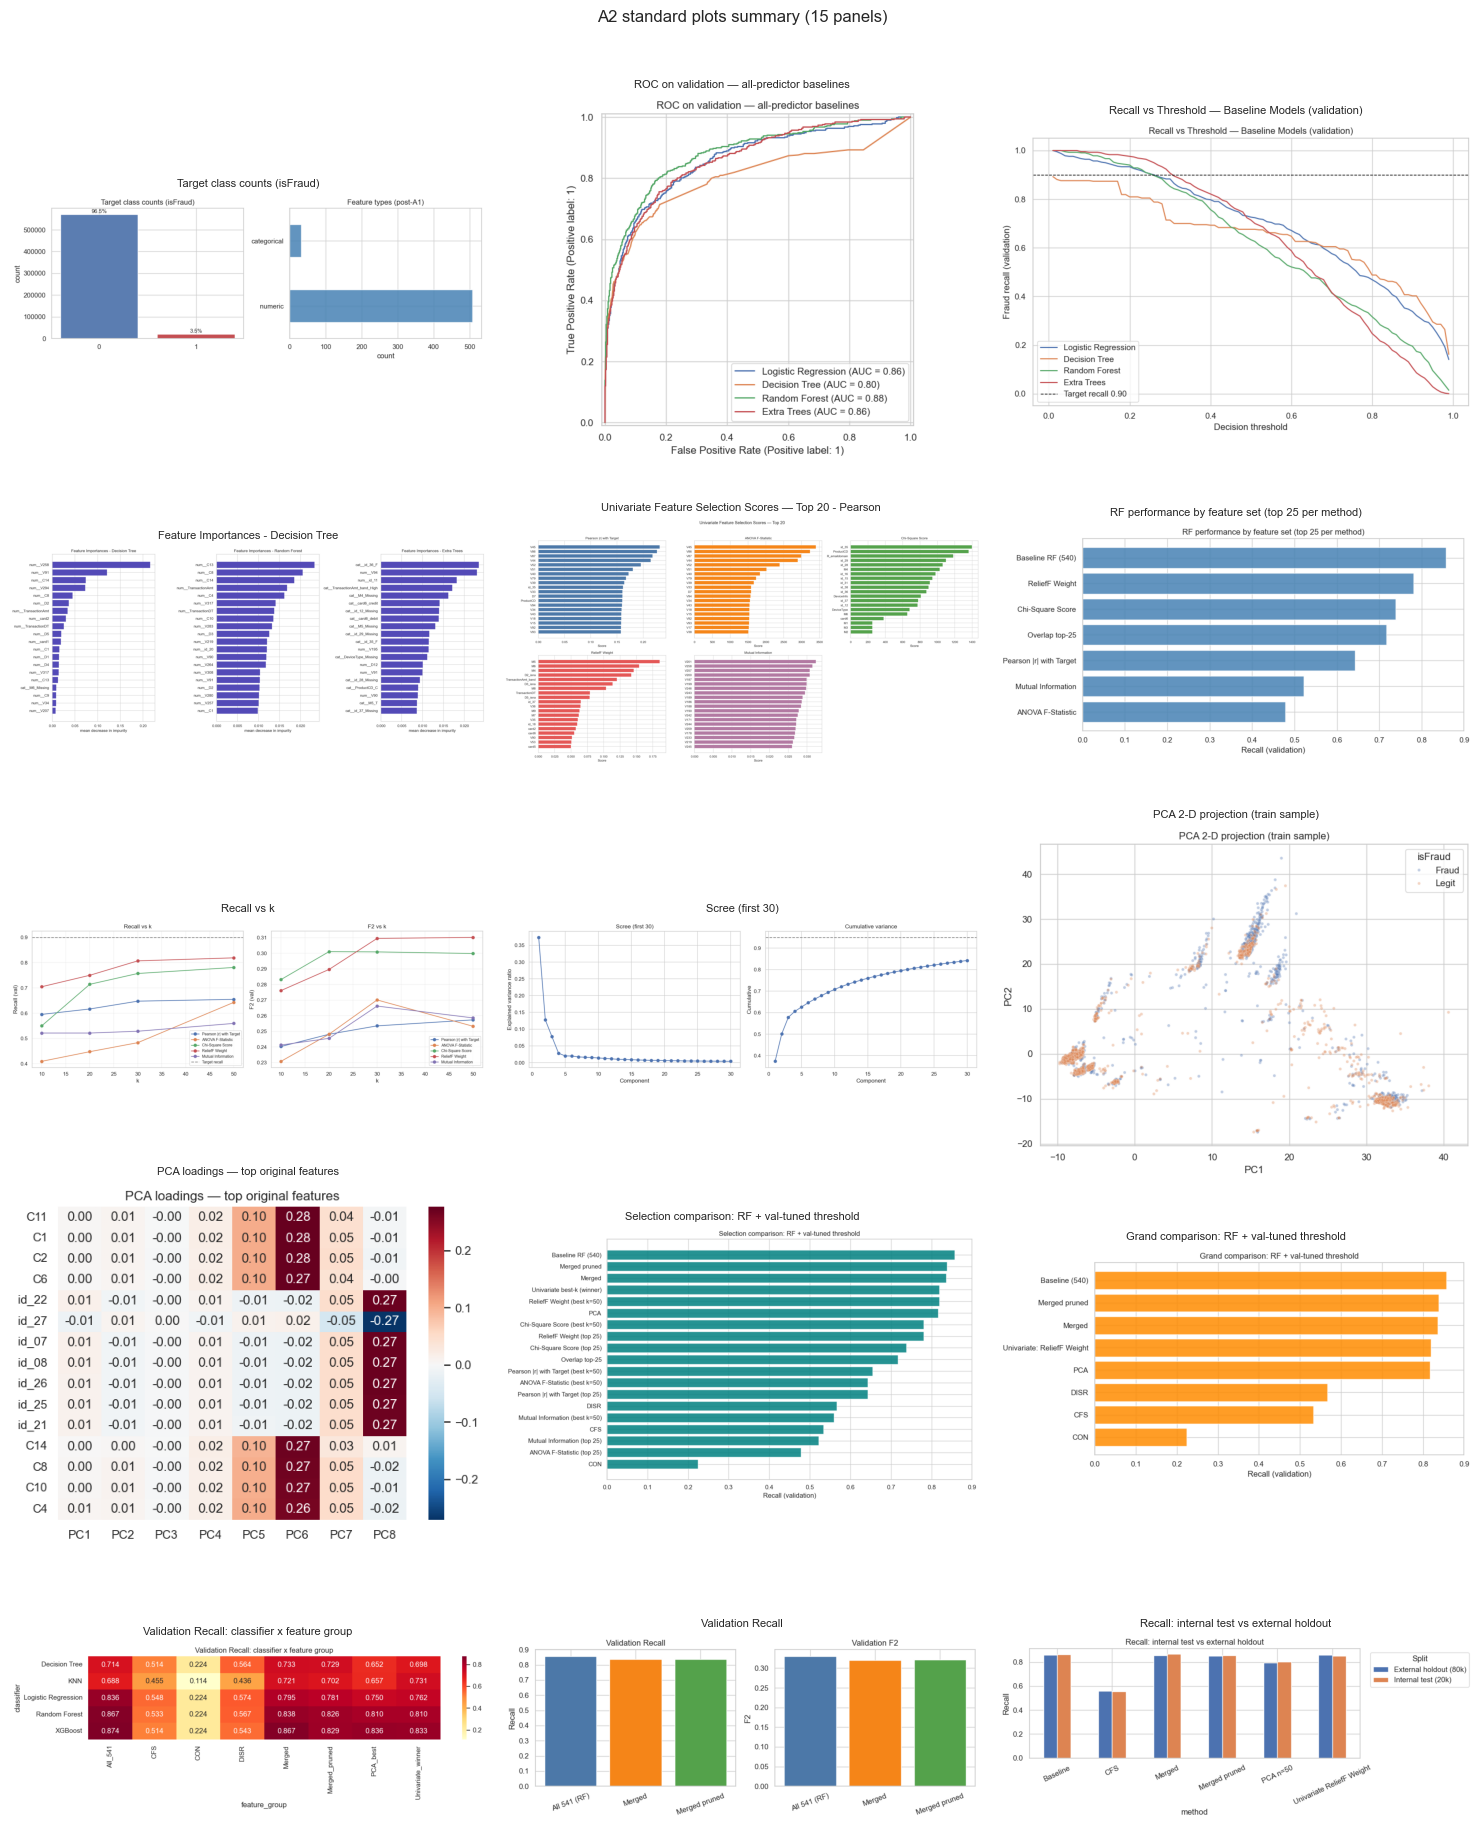

Saved a2_figure_gallery_matrix.png


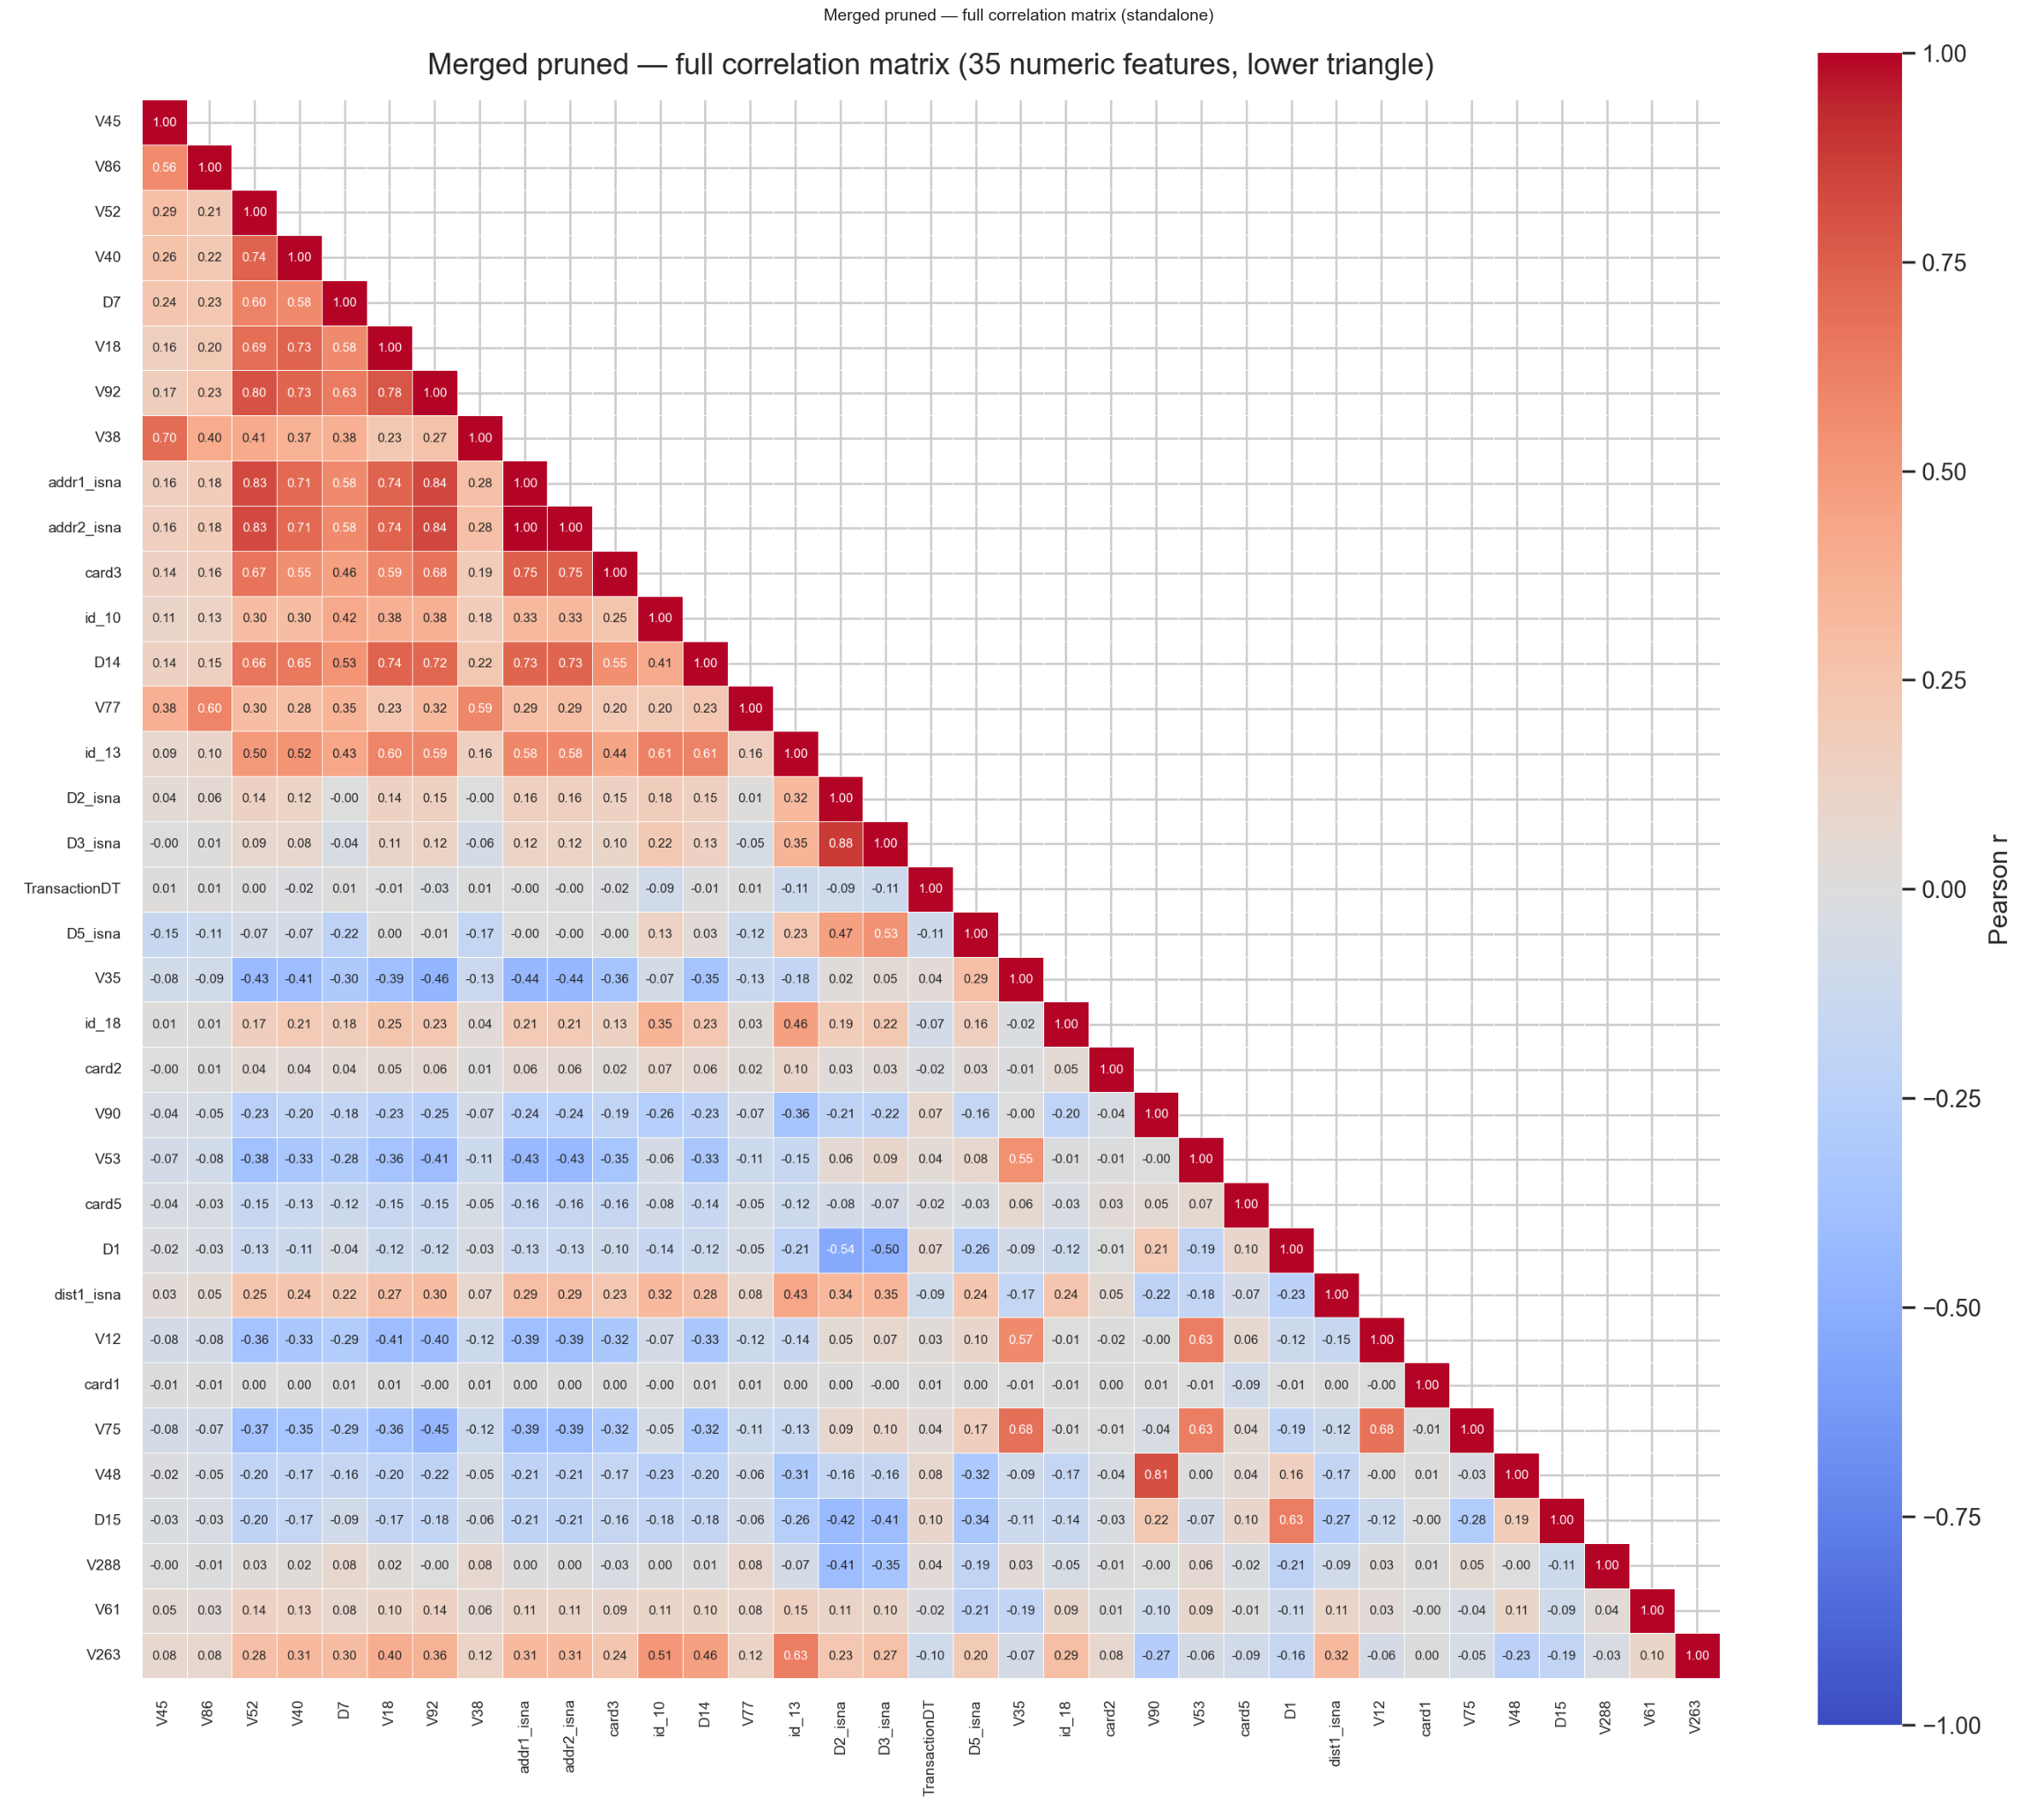

Standalone asset: a2_a1_summary_matrix.png — exists=True
Standalone asset: a2_membership_heatmap_68.png — exists=False


In [145]:
from matplotlib import image as mpimg
from matplotlib.gridspec import GridSpec
from pathlib import Path

# --- Excluir dashboards (ya tienen PNG propio) ---
EXCLUDE = (
    'A1 Summary Matrix',
    'Correlation matrices of final selections',
    'Merged pruned — full correlation',
    'Merged pruned — full correlation (export)',
    'Feature membership in final selections',
)
BANK = []
seen = set()
for item in _NB_FIGURE_BANK:
    t = item['title']
    if any(x in t for x in EXCLUDE):
        continue
    if t in seen:
        continue
    seen.add(t)
    BANK.append(item)

print(f'Gallery bank: {len(BANK)} standard plots (excluded A1 / corr / membership)')

# --- Galería compacta: 3 columnas, altura fija por fila ---
if BANK:
    n = len(BANK)
    ncol, nrow = 3, int(np.ceil(n / 3))
    fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3.8 * nrow))
    axes_flat = np.atleast_1d(axes).flatten()
    for ax, item in zip(axes_flat, BANK):
        ax.imshow(mpimg.imread(io.BytesIO(item['png'])))
        ax.set_title(item['title'][:55], fontsize=8)
        ax.axis('off')
    for ax in axes_flat[n:]:
        ax.axis('off')
    fig.suptitle(f'A2 standard plots summary ({n} panels)', fontsize=12, y=1.01)
    plt.tight_layout()
    fig.savefig('a2_figure_gallery_matrix.png', dpi=140, bbox_inches='tight', facecolor='white')
    plt.show()
    print('Saved a2_figure_gallery_matrix.png')
else:
    print('BANK empty — re-run from imports with skip_keys in hook')

# --- HERO: correlación merged pruned (solo UNA vez, grande) ---
corr_path = Path('a2_merged_pruned_correlation_full68.png')
if corr_path.exists():
    arr = mpimg.imread(corr_path)
    h, w = arr.shape[:2]
    fig2, ax2 = plt.subplots(figsize=(min(24, w / 80), min(24, h / 80)))
    ax2.imshow(arr)
    ax2.axis('off')
    ax2.set_title('Merged pruned — full correlation matrix (standalone)', fontsize=14, pad=8)
    plt.tight_layout()
    plt.show()
else:
    print('Run correlation cell first → a2_merged_pruned_correlation_full68.png')

# --- Referencia a otros PNG standalone (no re-embed) ---
for p in ['a2_a1_summary_matrix.png', 'a2_membership_heatmap_68.png']:
    print(f'Standalone asset: {p} — exists={Path(p).exists()}')

## Appendix — Selected Features by Method

Lists below support the written report; validation tuning used `X_fit`/`X_val` only.


In [146]:
appendix_sets = [
    ('Univariate winner', best_univariate_features),
    ('CFS', cfs_features),
    ('CON', con_features),
    ('DISR', disr_features),
    ('Merged', merged_unique_features),
]
if 'merged_pruned_features' in dir():
    appendix_sets.append(('Merged pruned', merged_pruned_features))
for label, feats in appendix_sets:
    print(f'\n=== {label} ({len(feats)} features) ===')
    print(feats)



=== Univariate winner (50 features) ===
['M5', 'M6', 'M4', 'D2_isna', 'TransactionAmt_band', 'D3_isna', 'M8', 'TransactionDT', 'D5_isna', 'id_37', 'V36', 'M9', 'M7', 'V35', 'id_18', 'card2', 'card6', 'V90', 'V53', 'card5', 'D1', 'id_38', 'V29', 'dist1_isna', 'V69', 'V12', 'V70', 'D2', 'M3', 'V91', 'card1', 'DeviceInfo', 'V75', 'V30', 'M2', 'V48', 'V13', 'D15', 'V76', 'V49', 'V54', 'DeviceType', 'V288', 'V61', 'id_12', 'D14', 'P_emaildomain', 'id_30', 'id_15', 'card4']

=== CFS (4 features) ===
['V45', 'V52', 'V86', 'id_10']

=== CON (1 features) ===
['V45']

=== DISR (10 features) ===
['R_emaildomain', 'V51', 'id_35', 'V33', 'ProductCD', 'V94', 'id_31', 'addr1_isna', 'id_29', 'V15']

=== Merged (160 features) ===
['V45', 'V86', 'V87', 'V44', 'V52', 'V51', 'V40', 'V79', 'V39', 'id_35', 'V33', 'D7', 'ProductCD', 'V94', 'V34', 'V43', 'V18', 'V15', 'V92', 'V93', 'V17', 'V38', 'addr1_isna', 'addr2_isna', 'V16', 'D12', 'card3', 'V74', 'V42', 'V81', 'R_emaildomain', 'V80', 'V50', 'id_10', 'i

# requirements


In [147]:
# requirements
import io
import sys
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn

from IPython.display import display, Markdown
from matplotlib import image as mpimg
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from scipy.stats import chi2_contingency
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    mutual_info_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    import missingno as msno
except ImportError:
    msno = None

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# ... hook _NB_FIGURE_BANK + constantes RANDOM_STATE, etc. (sin cambios) ...

print('Python:', sys.version.split()[0])
print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('matplotlib:', matplotlib.__version__)
print('seaborn:', sns.__version__)
print('scipy:', scipy.__version__)
print('sklearn:', sklearn.__version__)
print('missingno:', msno.__version__ if msno else 'not installed')
try:
    import xgboost as xgb
    xgb_ver = xgb.__version__
except ImportError:
    xgb_ver = 'not installed'
print('xgboost:', xgb_ver)

Python: 3.10.8
pandas: 2.3.0
numpy: 2.2.6
matplotlib: 3.10.3
seaborn: 0.13.2
scipy: 1.14.0
sklearn: 1.4.2
missingno: 0.5.2
xgboost: 3.2.0


Python: 3.10.8   
pandas: 2.3.0   
numpy: 2.2.6    
matplotlib: 3.10.3   
seaborn: 0.13.2      
scipy: 1.14.0   
sklearn: 1.4.2     
missingno: 0.5.2   
xgboost: 3.2.0   

Set-Location "XXX:\langara\term 4\dana 4830\assigment 1"    
d:\Python310\python.exe -m jupyter nbconvert "A2_Leonardo_LS_VF.ipynb" --to webpdf --output "A2_Leonardo_LS_VF"